<p align="center">
  <img src="https://i0.wp.com/www.tiempodecine.co/web/wp-content/uploads/2015/11/Robert-De-Niro-in-Taxi-Driver-1976.jpg?resize=750%2C375&ssl=1" style="width:100%; max-width:900px; height:180px; object-fit:cover; border-radius:10px;"/>
</p>
<div style="text-align:center;">
  <h1 style="color:#FFD700; display:inline-block; margin:0;">Optimización del Transporte en Nueva York</h1>
  <p>
    <b>Green Taxi | Machine Learning & Data Science | CRISP-DM</b><br>
    <span style="font-size:1.1em;">Análisis y predicción de tarifas y duración de viajes usando datos reales de taxis verdes de NYC.</span>
  </p>
</div>

# FASE 2: Comprensión de Datos (CRISP-DM)

## Propósito de la Fase de Comprensión de Datos

En esta segunda fase del proceso CRISP-DM, nos centramos en explorar y comprender los datos recopilados. Esto incluye la evaluación de la calidad de los datos, la identificación de patrones y relaciones significativas, y la generación de insights preliminares que guiarán las etapas posteriores del proyecto. El objetivo es asegurar que los datos sean adecuados para el análisis y el modelado futuros.

In [1]:
# Verifica si las librerías necesarias ya están instaladas
try:
    # Ignorar warnings
    import warnings
    warnings.filterwarnings('ignore')
    # Librerías del sistema
    import sys, subprocess
    # Importaciones base
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import os as os  
    from os import path
    import joblib
    import scipy.stats as stats
    import pickle as pkl

    print("Dependencias ya instaladas.")

except ImportError:

    print("Dependencias no encontradas. Instalando ahora...")
    
    # Se ejecutan los comandos de instalación
    %pip install --quiet matplotlib
    %pip install --quiet seaborn
    %pip install --quiet joblib
    %pip install --quiet scipy
    %pip install --quiet pyarrow
    
    print("Instalación completada.")

Dependencias ya instaladas.


# FHVHS (For-Hire Vehicle High-Speed)

### Carga muestra de FHVHS

In [2]:
# FHVHV (Uber/Lyft)
print("\Carga muestra de FHVHV (Uber/Lyft)...")
fhvhv_sample = pd.read_parquet('fhvhv_trimestral.parquet')

\Carga muestra de FHVHV (Uber/Lyft)...


### Diccionario de datos FHVHS

| Field Name | Description | Data Type | Statistical Type |
|------------|-------------|-----------|------------------|
| access_a_ride_flag | Was the trip administered on behalf of the Metropolitan Transportation Authority (MTA)? (Y/N) | Object | Categorical - Binary |
| airport_fee | $2.50 for both drop off and pick up at LaGuardia, Newark, and John F. Kennedy airports. | Float | Numerical - Continuous |
| bcf | Total amount collected in trip for Black Car Fund. | Float | Numerical - Continuous |
| base_passenger_fare | Base passenger fare before tolls, tips, taxes, and fees. | Float | Numerical - Continuous |
| cbd_congestion_fee | Per-trip charge for MTA's Congestion Relief Zone starting Jan. 5, 2025. | Float | Numerical - Continuous |
| congestion_surcharge | Total amount collected in trip for NYS congestion surcharge. | Float | Numerical - Continuous |
| dispatching_base_num | The TLC Base License Number of the base that dispatched the trip. | Object | Categorical - Nominal |
| DOLocationID | TLC Taxi Zone in which the trip ended. | Integer | Numerical - Discrete |
| driver_pay | Total driver pay (not including tolls or tips and net of commission, surcharges, or taxes). | Float | Numerical - Continuous |
| dropoff_datetime | The date and time of the trip drop-off. | DateTime | Date/Time |
| hvfhs_license_num | The TLC license number of the HVFHS base or business. As of September 2019, the HVFHS licensees are the following: • HV0002: Juno • HV0003: Uber • HV0004: Via • HV0005: Lyft | Object | Categorical - Nominal |
| on_scene_datetime | Date/time when driver arrived at the pick-up location (Accessible Vehicles-only). | DateTime | Date/Time |
| originating_base_num | Base number of the base that received the original trip request. | Object | Categorical - Nominal |
| pickup_datetime | The date and time of the trip pick-up. | DateTime | Date/Time |
| PULocationID | TLC Taxi Zone in which the trip began. | Integer | Numerical - Discrete |
| request_datetime | Date/time when passenger requested to be picked up. | DateTime | Date/Time |
| sales_tax | Total amount collected in trip for NYS sales tax. | Float | Numerical - Continuous |
| shared_match_flag | Did the passenger share the vehicle with another passenger who booked separately at any point during the trip? (Y/N) | Object | Categorical - Binary |
| shared_request_flag | Did the passenger agree to a shared/pooled ride, regardless of whether they were matched? (Y/N) | Object | Categorical - Binary |
| tips | Total amount of tips received from passenger. | Float | Numerical - Continuous |
| tolls | Total amount of all tolls paid in trip. | Float | Numerical - Continuous |
| trip_miles | Total miles for passenger trip. | Float | Numerical - Continuous |
| trip_time | Total time in seconds for passenger trip. | Integer | Numerical - Discrete |
| wav_match_flag | Did the trip occur in a wheelchair-accessible vehicle (WAV)? (Y/N) | Object | Categorical - Binary |
| wav_request_flag | Did the passenger request a wheelchair-accessible vehicle (WAV)? (Y/N) | Object | Categorical - Binary |

### Orden por Dominios para dataset HVFHS

In [3]:
# Define column order for HVFHS dataset - Alphabetically sorted within domains
hvfhs_column_order = [
    # Dominio temporal (alfabético)
    'request_datetime',      # Fecha/hora cuando el pasajero solicitó ser recogido
    'on_scene_datetime',     # Fecha/hora cuando el conductor llegó al lugar de recogida (solo vehículos accesibles)
    'pickup_datetime',       # Fecha y hora de recogida del viaje
    'dropoff_datetime',      # Fecha y hora de finalización del viaje
    
    # Dominio espacial (alfabético)
    'PULocationID',          # Zona de taxi TLC donde comenzó el viaje
    'DOLocationID',          # Zona de taxi TLC donde terminó el viaje
    
    # Dominio de identidad del servicio (alfabético)
    'dispatching_base_num',  # Número de licencia de la base TLC que despachó el viaje
    'hvfhs_license_num',     # Número de licencia TLC de la base o empresa HVFHS (HV0002: Juno, HV0003: Uber, HV0004: Via, HV0005: Lyft)
    'originating_base_num',  # Número de la base que recibió la solicitud original del viaje
    
    # Dominio de métricas del viaje (alfabético)
    'trip_miles',            # Millas totales del viaje del pasajero
    'trip_time',             # Tiempo total en segundos del viaje del pasajero
    
    # Dominio financiero (alfabético)
    'airport_fee',           # Tarifa de $2.50 por recogida y entrega en aeropuertos LaGuardia, Newark y JFK
    'base_passenger_fare',   # Tarifa base del pasajero antes de peajes, propinas, impuestos y tarifas
    'bcf',                   # Monto total recaudado en el viaje para el Black Car Fund
    'cbd_congestion_fee',    # Cargo por viaje para la Zona de Alivio de Congestión de MTA (desde 5 ene. 2025)
    'congestion_surcharge',  # Monto total recaudado en el viaje por el recargo de congestión de NYS
    'driver_pay',            # Pago total del conductor (sin incluir peajes o propinas y neto de comisiones, recargos o impuestos)
    'sales_tax',             # Monto total recaudado en el viaje por el impuesto de ventas de NYS
    'tips',                  # Monto total de propinas recibidas del pasajero
    'tolls',                 # Monto total de todos los peajes pagados en el viaje
    
    # Dominio de banderas de servicio (alfabético)
    'access_a_ride_flag',    # ¿Se administró el viaje en nombre de la MTA? (Y/N)
    'shared_match_flag',     # ¿Compartió el pasajero el vehículo con otro pasajero que reservó por separado? (Y/N)
    'shared_request_flag',   # ¿Aceptó el pasajero un viaje compartido/agrupado, independientemente de si fueron emparejados? (Y/N)
    'wav_match_flag',        # ¿Ocurrió el viaje en un vehículo accesible para sillas de ruedas (WAV)? (Y/N)
    'wav_request_flag'       # ¿Solicitó el pasajero un vehículo accesible para sillas de ruedas (WAV)? (Y/N)
]

# Carga de datos de Taxis verdes de Nueva York

In [4]:
# TAXIS (Yellow/Green)
print("Carga muestra de TAXIS (Yellow/Green)...")
taxis_sample = pd.read_parquet('taxis_equilibrado_directo.parquet')

Carga muestra de TAXIS (Yellow/Green)...


### Carga muestra de Taxis (Yellow/Green)

| Field Name | Description | Data Type | Statistical Type |
|------------|-------------|-----------|------------------|
| VendorID | A code indicating the TPEP provider that provided the record. 1 = Creative Mobile Technologies, LLC 2 = Curb Mobility, LLC 6 = Myle Technologies Inc 7 = Helix | Object | Categorical - Nominal |
| tpep_pickup_datetime | The date and time when the meter was engaged. | DateTime | Date/Time |
| tpep_dropoff_datetime | The date and time when the meter was disengaged. | DateTime | Date/Time |
| passenger_count | The number of passengers in the vehicle. | Integer | Numerical - Discrete |
| trip_distance | The elapsed trip distance in miles reported by the taximeter. | Float | Numerical - Continuous |
| RatecodeID | The final rate code in effect at the end of the trip. 1 = Standard rate 2 = JFK 3 = Newark 4 = Nassau or Westchester 5 = Negotiated fare 6 = Group ride 99 = Null/unknown | Object | Categorical - Ordinal |
| store_and_fwd_flag | This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka "store and forward," because the vehicle did not have a connection to the server. Y = store and forward trip N = not a store and forward trip | Object | Categorical - Binary |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged. | Integer | Numerical - Discrete |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged. | Integer | Numerical - Discrete |
| payment_type | A numeric code signifying how the passenger paid for the trip. 0 = Flex Fare trip 1 = Credit card 2 = Cash 3 = No charge 4 = Dispute 5 = Unknown 6 = Voided trip | Object | Categorical - Ordinal |
| fare_amount | The time-and-distance fare calculated by the meter. | Float | Numerical - Continuous |
| extra | Miscellaneous extras and surcharges. | Float | Numerical - Continuous |
| mta_tax | Tax that is automatically triggered based on the metered rate in use. | Float | Numerical - Continuous |
| tip_amount | Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. | Float | Numerical - Continuous |
| tolls_amount | Total amount of all tolls paid in trip. | Float | Numerical - Continuous |
| improvement_surcharge | Improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. | Float | Numerical - Continuous |
| total_amount | The total amount charged to passengers. Does not include cash tips. | Float | Numerical - Continuous |
| congestion_surcharge | Total amount collected in trip for NYS congestion surcharge. | Float | Numerical - Continuous |
| airport_fee | For pick up only at LaGuardia and John F. Kennedy Airports. | Float | Numerical - Continuous |
| cbd_congestion_fee | Per-trip charge for MTA's Congestion Relief Zone starting Jan. 5, 2025. | Float | Numerical - Continuous |

### Orden por Dominios para dataset Taxis

In [5]:
# Define column order for Taxis dataset (Yellow + Green)
taxis_column_order = [
    # Dominio temporal (alfabético)
    'pickup_datetime',      # Fecha y hora cuando se activó el taxímetro (inicio del viaje)
    'dropoff_datetime',     # Fecha y hora cuando se desactivó el taxímetro (fin del viaje)

    # Dominio espacial (alfabético)
    'PULocationID',              # Zona de taxi TLC donde comenzó el viaje
    'DOLocationID',              # Zona de taxi TLC donde terminó el viaje
                               
    # Dominio de identidad del servicio (alfabético)
    'VendorID',                  # Código del proveedor TPEP (1=Creative Mobile Technologies, 2=Curb Mobility, 6=Myle Technologies, 7=Helix)
    
    # Dominio de características del viaje (alfabético)
    'passenger_count',           # Número de pasajeros en el vehículo
    'trip_distance',             # Distancia del viaje en millas reportada por el taxímetro
    'RatecodeID',               # Código de tarifa final (1=Estándar, 2=JFK, 3=Newark, 4=Nassau/Westchester, 5=Tarifa negociada, 6=Viaje grupal, 99=Desconocido)
    'payment_type',             # Tipo de pago (0=Flex Fare, 1=Tarjeta crédito, 2=Efectivo, 3=Sin cargo, 4=Disputa, 5=Desconocido, 6=Viaje anulado)
    'store_and_fwd_flag',       # Indica si el registro se almacenó en memoria del vehículo antes del envío (Y=Sí, N=No)
    'trip_type',                # Tipo de viaje (1=Desde la calle, 2=Despachado)
    
    # Dominio financiero (alfabético)
    'fare_amount',              # Tarifa de tiempo y distancia calculada por el taxímetro
    'total_amount',             # Monto total cobrado a los pasajeros (no incluye propinas en efectivo)
    'extra',                    # Extras y recargos diversos
    'mta_tax',                  # Impuesto que se activa automáticamente según la tarifa del taxímetro
    'tip_amount',               # Monto de propinas (solo tarjetas de crédito, no incluye efectivo)
    'tolls_amount',             # Monto total de peajes pagados en el viaje
    'improvement_surcharge',    # Recargo de mejora evaluado en viajes (comenzó en 2015)
    'congestion_surcharge',     # Monto total recaudado por el recargo de congestión de NYS
    'airport_fee',              # Tarifa solo para recogidas en aeropuertos LaGuardia y JFK
    'cbd_congestion_fee',       # Cargo por viaje para la Zona de Alivio de Congestión de MTA (desde 5 ene. 2025)
    #Taxis Colors
    'taxi_color',               # Color del taxi (yellow o green)
    'taxi_color_ini',           # Inicial del color del taxi (Y o G)
    'is_color'                  # Indicador binario del color del taxi (1=yellow, 2=green)
]

### Función para reordenar columnas según el orden definido

In [6]:
def reorder_dataframe(df, dataset_type):
    # Reorder DataFrame columns based on dataset type
    if dataset_type == 'hvfhs':
        column_order = hvfhs_column_order
    elif dataset_type == 'taxis':
        column_order = taxis_column_order
    else:
        raise ValueError("dataset_type must be 'hvfhs' or 'taxis'")
    
    # Verify that all columns exist in the DataFrame
    missing_columns = [col for col in column_order if col not in df.columns]
    if missing_columns:
        print(f"Warning: The following columns are not found in the DataFrame: {missing_columns}")
        column_order = [col for col in column_order if col in df.columns]
    
    # Reorder the DataFrame
    df = df[column_order].copy()
    return df

### Guardar datasets reordenados

In [7]:
def save_ordered_dataset(df, dataset_type, file_path, file_format='parquet'):
    # Reorder the dataframe
    df_ordered = reorder_dataframe(df, dataset_type)
    
    # Save in specified format
    if file_format.lower() == 'parquet':
        df_ordered.to_parquet(file_path, index=False)
    else:
        raise ValueError("file_format must be 'parquet', 'csv', or 'pickle'")
    
    print(f"Dataset successfully saved to: {file_path}")
    print(f"Shape: {df_ordered.shape}")
    print(f"Columns ({len(df_ordered.columns)}): {list(df_ordered.columns)}")
    
    return df_ordered

In [8]:
# For HVFHS data (using the loaded fhvhv_sample):
hvfhs_sample_ordered = save_ordered_dataset(fhvhv_sample, 'hvfhs', 'hvfhs_ordered_dataset.parquet', 'parquet')

# For Taxis data:
taxis_sample_ordered = save_ordered_dataset(taxis_sample, 'taxis', 'taxis_ordered_dataset.parquet', 'parquet')

Dataset successfully saved to: hvfhs_ordered_dataset.parquet
Shape: (548864, 25)
Columns (25): ['request_datetime', 'on_scene_datetime', 'pickup_datetime', 'dropoff_datetime', 'PULocationID', 'DOLocationID', 'dispatching_base_num', 'hvfhs_license_num', 'originating_base_num', 'trip_miles', 'trip_time', 'airport_fee', 'base_passenger_fare', 'bcf', 'cbd_congestion_fee', 'congestion_surcharge', 'driver_pay', 'sales_tax', 'tips', 'tolls', 'access_a_ride_flag', 'shared_match_flag', 'shared_request_flag', 'wav_match_flag', 'wav_request_flag']
Dataset successfully saved to: taxis_ordered_dataset.parquet
Shape: (96410, 23)
Columns (23): ['pickup_datetime', 'dropoff_datetime', 'PULocationID', 'DOLocationID', 'VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'payment_type', 'store_and_fwd_flag', 'trip_type', 'fare_amount', 'total_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'cbd_congestion_fee', 'taxi_color', 'taxi_color_

# HVFHS
### Objetivo:

Agrupar zonas de la ciudad según  
- volumen de viajes 
- hora pico
- tipo de servicio.

Identificar áreas con alta demanda o saturadas.
Optimizar la asignación de flotas y planificación de estaciones de vehículos.


In [9]:
df_hvfhs = hvfhs_sample_ordered.copy()

### Engineering Temporal Features.

In [10]:
# 1. Tiempo de Espera del Pasajero (Minutos, 2 decimales)
#   Desgloce de las fechas Pickup
df_hvfhs['pickup_year'] = df_hvfhs['pickup_datetime'].dt.year
df_hvfhs['pickup_month'] = df_hvfhs['pickup_datetime'].dt.month
df_hvfhs['pickup_day'] = df_hvfhs['pickup_datetime'].dt.day
#    (Desde que lo pide hasta que lo recogen)
df_hvfhs['wait_time_min'] = ((df_hvfhs['pickup_datetime'] - df_hvfhs['request_datetime']).dt.total_seconds() / 60).round(2)

# 2. Duración del Viaje (Minutos, 2 decimales)
df_hvfhs['trip_time_min'] = (df_hvfhs['trip_time'] / 60).round(2)

# --- C. Creación de Features de Patrón (Basadas en 'pickup_datetime') ---
df_hvfhs['pickup_hour'] = df_hvfhs['pickup_datetime'].dt.hour
df_hvfhs['pickup_day_of_week'] = df_hvfhs['pickup_datetime'].dt.dayofweek # 0=Lunes, 6=Domingo
df_hvfhs['is_weekend'] = (df_hvfhs['pickup_day_of_week'] >= 5).astype('int32')

# 3. Bandas Horarias (Time Bands) - Clave para el clustering
def get_time_band(hour):
    if 6 <= hour < 10:
        return 'AM_Peak' # 6-9 AM
    elif 10 <= hour < 16:
        return 'OP_day' # 10 AM - 3 PM Off-Peak Day
    elif 16 <= hour < 20:
        return 'PM_Peak' # 4-7 PM
    elif 20 <= hour < 24:
        return 'OP_night' # 8-11 PM Off-Peak Night
    else: # 0-5 AM
        return 'Early_Morning'

df_hvfhs['time_band'] = df_hvfhs['pickup_hour'].apply(get_time_band)

print("¡Feature Engineering Temporal completado!")

¡Feature Engineering Temporal completado!


### Reordenar columnas Temporales del dataset HVFHS

In [11]:
# --- Grupo 1: Mover features de 'pickup_datetime' ---

# Primero, encontramos la ubicación de la columna "ancla"
loc_pickup = df_hvfhs.columns.get_loc('pickup_datetime')

# Usamos .pop() para sacar la columna del final
# Usamos .insert() para ponerla en la ubicación que queremos
# (loc_pickup + 1) -> Inmediatamente después de 'pickup_datetime'

df_hvfhs.insert(loc_pickup + 1, 'pickup_year', df_hvfhs.pop('pickup_year'))
df_hvfhs.insert(loc_pickup + 2, 'pickup_month', df_hvfhs.pop('pickup_month'))
df_hvfhs.insert(loc_pickup + 3, 'pickup_day', df_hvfhs.pop('pickup_day'))
df_hvfhs.insert(loc_pickup + 4, 'pickup_hour', df_hvfhs.pop('pickup_hour'))
df_hvfhs.insert(loc_pickup + 5, 'pickup_day_of_week', df_hvfhs.pop('pickup_day_of_week'))
df_hvfhs.insert(loc_pickup + 6, 'is_weekend', df_hvfhs.pop('is_weekend'))
df_hvfhs.insert(loc_pickup + 7, 'time_band', df_hvfhs.pop('time_band'))
df_hvfhs.insert(loc_pickup + 8, 'wait_time_min', df_hvfhs.pop('wait_time_min'))

print("¡Columnas re-ubicadas exitosamente!")

¡Columnas re-ubicadas exitosamente!


In [12]:
# --- Grupo 2: Mover features de 'trip_time' ---
# Primero, encontramos la ubicación de la columna "ancla"
loc_trip_time = df_hvfhs.columns.get_loc('trip_time')

# Insertamos la columna de minutos justo después
df_hvfhs.insert(loc_trip_time + 1, 'trip_time_min', df_hvfhs.pop('trip_time_min'))

print("¡Columnas re-ubicadas exitosamente!")

¡Columnas re-ubicadas exitosamente!


### Transformación de Banderas

In [13]:
#  --- Grupo 3: Transformación de Banderas ---
# Verificar primero si las columnas originales existen o si ya fueron transformadas
flag_columns = ['access_a_ride_flag', 'shared_match_flag', 'shared_request_flag', 'wav_match_flag', 'wav_request_flag']
existing_flags = [col for col in flag_columns if col in df_hvfhs.columns]
bin_flags = [col + '_bin' for col in flag_columns if col + '_bin' in df_hvfhs.columns]

if existing_flags:
    print(f"Transformando las siguientes banderas: {existing_flags}")
    # Transformar solo las columnas que existen
    for flag_col in existing_flags:
        bin_col = flag_col + '_bin'
        df_hvfhs[bin_col] = df_hvfhs[flag_col].map({'Y': 1, 'N': 0}).astype('int32')
    print(f"¡Transformación de {len(existing_flags)} banderas completada!")
elif bin_flags:
    print(f"Las banderas ya fueron transformadas: {bin_flags}")
else:
    print("No se encontraron columnas de banderas para transformar.")

Transformando las siguientes banderas: ['access_a_ride_flag', 'shared_match_flag', 'shared_request_flag', 'wav_match_flag', 'wav_request_flag']
¡Transformación de 5 banderas completada!


### Datos duplicados en Dataset HVFHS

In [14]:
df_hvfhs.describe(include='all').T.duplicated()

request_datetime           False
on_scene_datetime          False
pickup_datetime            False
pickup_year                False
pickup_month               False
pickup_day                 False
pickup_hour                False
pickup_day_of_week         False
is_weekend                 False
time_band                  False
wait_time_min              False
dropoff_datetime           False
PULocationID               False
DOLocationID               False
dispatching_base_num       False
hvfhs_license_num          False
originating_base_num       False
trip_miles                 False
trip_time                  False
trip_time_min              False
airport_fee                False
base_passenger_fare        False
bcf                        False
cbd_congestion_fee         False
congestion_surcharge       False
driver_pay                 False
sales_tax                  False
tips                       False
tolls                      False
access_a_ride_flag         False
shared_mat

### Cantidad de columnas y filas

In [15]:
# Total de columnas y filas 
print("Total de columnas:", df_hvfhs.shape[1], "y filas:", df_hvfhs.shape[0])

Total de columnas: 39 y filas: 548864


### Cantidad (%) de Datos Nulos por columna en HVFHS

In [16]:
# Porcentaje de valores nulos por columna (antes de limpieza)
missing_values = df_hvfhs.isnull().sum()/len(df_hvfhs)
missing_values = ((missing_values[missing_values > 0].round(3).sort_values(ascending=False)*100).round(2))
missing_values

originating_base_num    28.7
dtype: float64

# Heatmap de Datos Nulos por columna en HVFHS

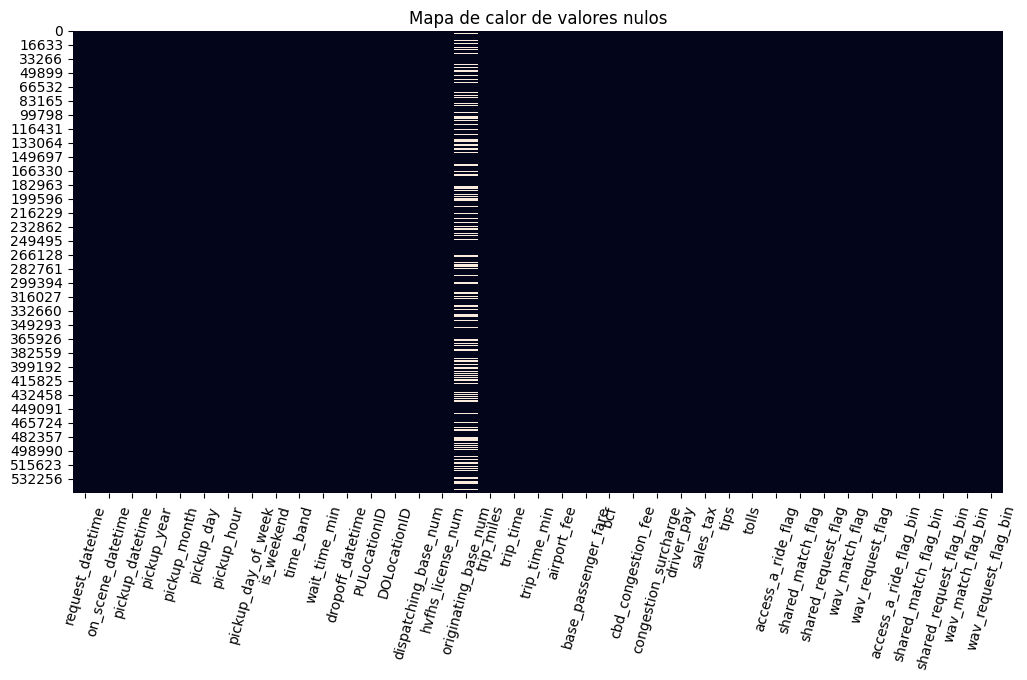

In [17]:
# Mapa de calor de valores nulos
plt.figure(figsize=(12, 6))
sns.heatmap(df_hvfhs.isnull(), cbar=False)
plt.title("Mapa de calor de valores nulos")
ax = plt.gca()
ax.tick_params(axis='x', rotation=75)

# Distribución Temporal de Viajes HVFHS  and Flag 


Generando gráficos comparativos por mes...
Columnas de tipo entero después de excluir: ['pickup_day', 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'access_a_ride_flag_bin', 'shared_match_flag_bin', 'shared_request_flag_bin', 'wav_match_flag_bin', 'wav_request_flag_bin']

Generando gráfico para: pickup_day


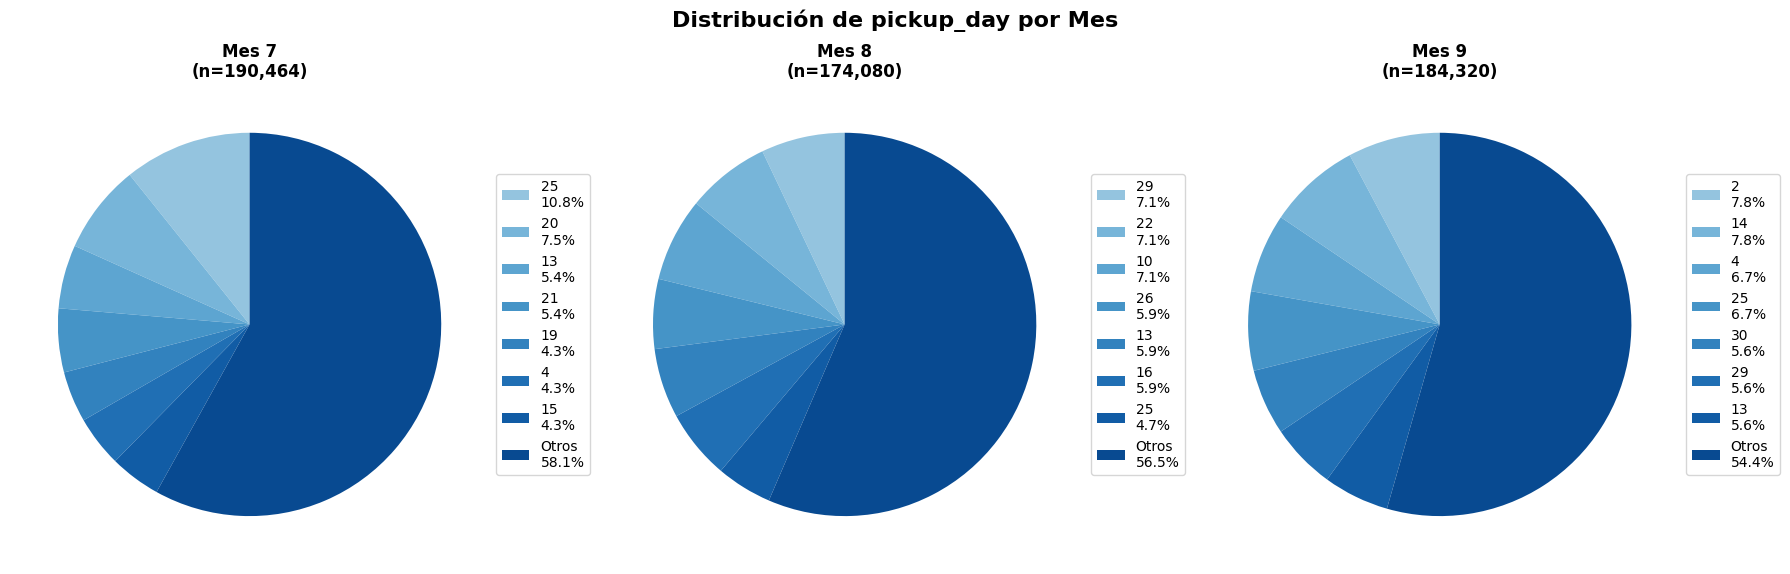


Generando gráfico para: pickup_hour


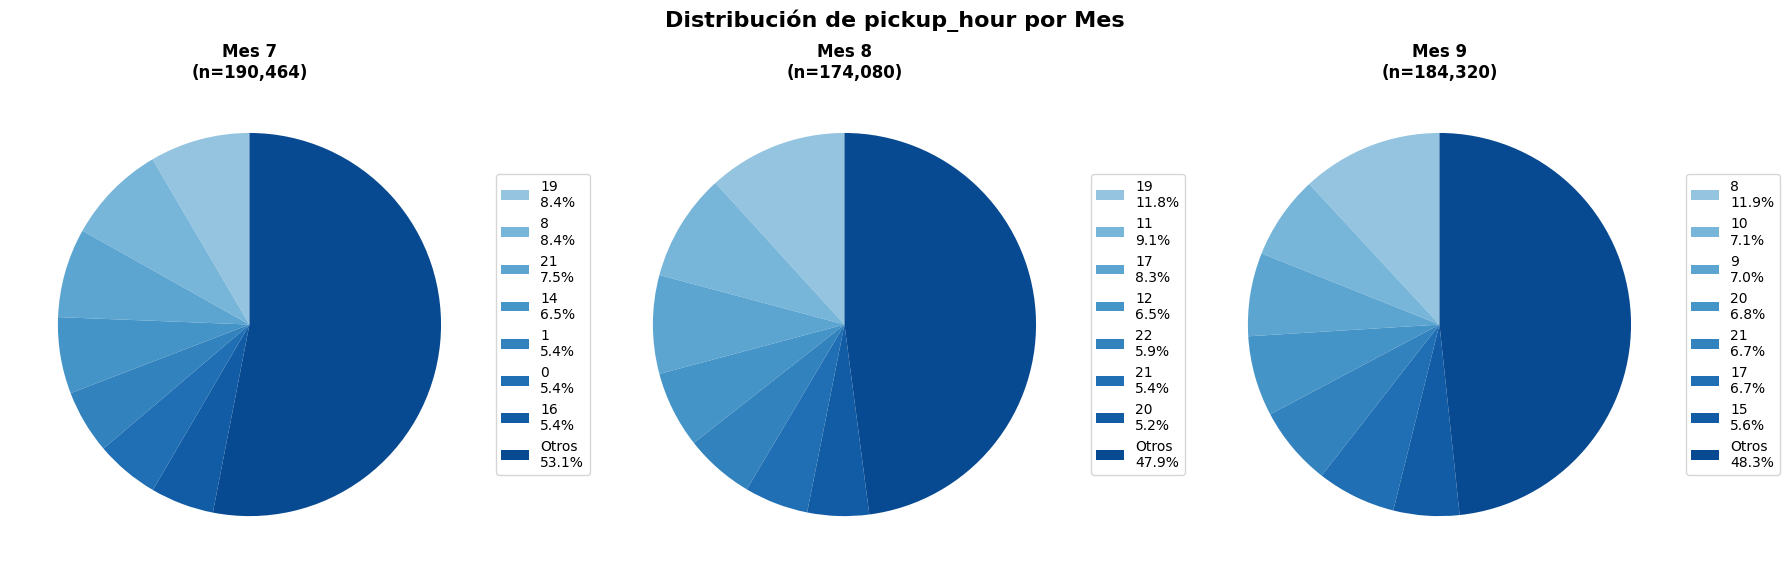


Generando gráfico para: pickup_day_of_week


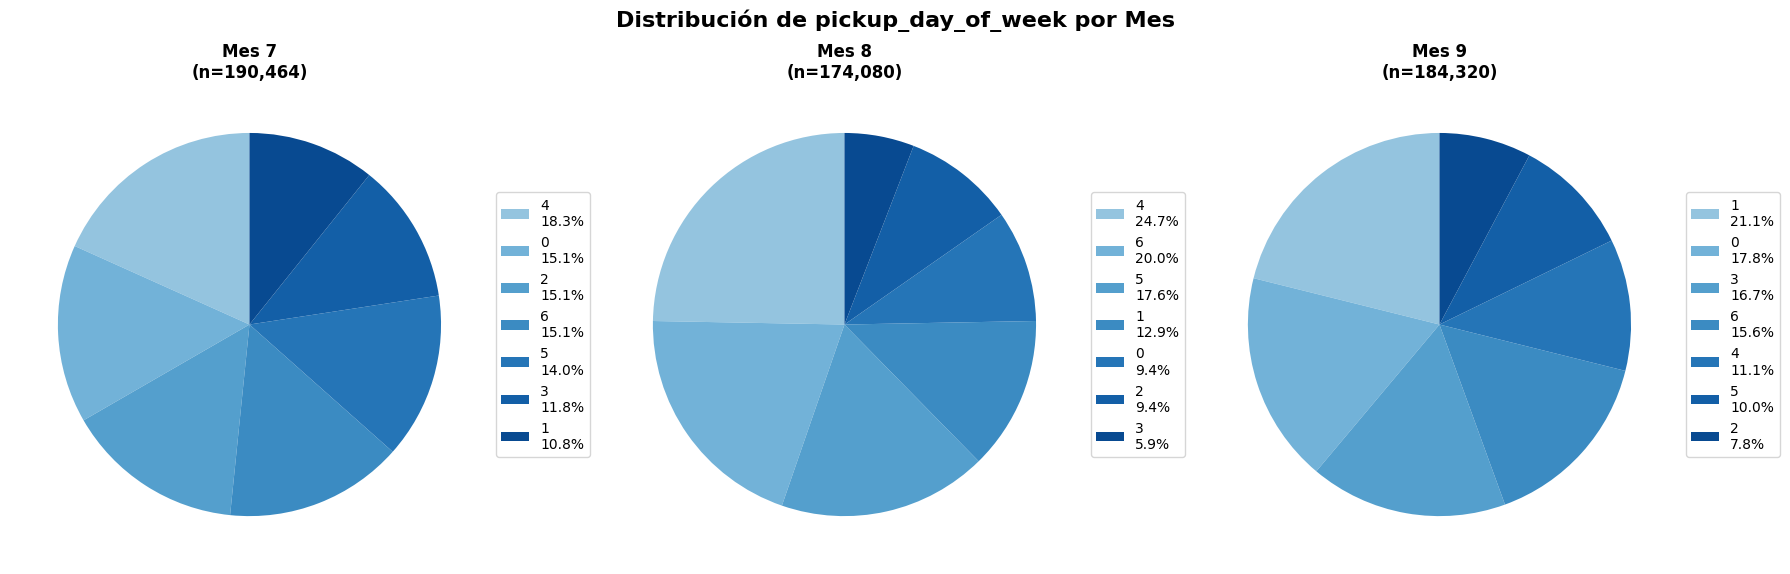


Generando gráfico para: is_weekend


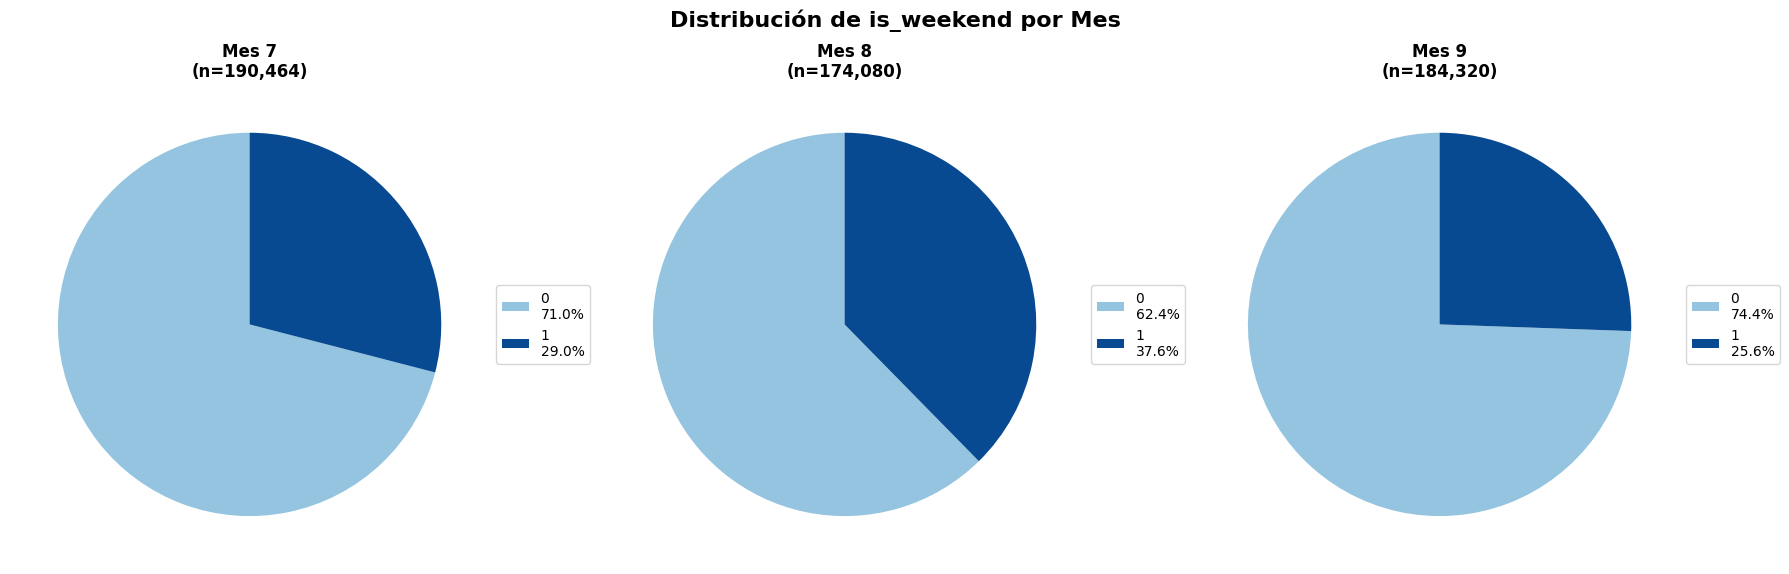


Generando gráfico para: access_a_ride_flag_bin


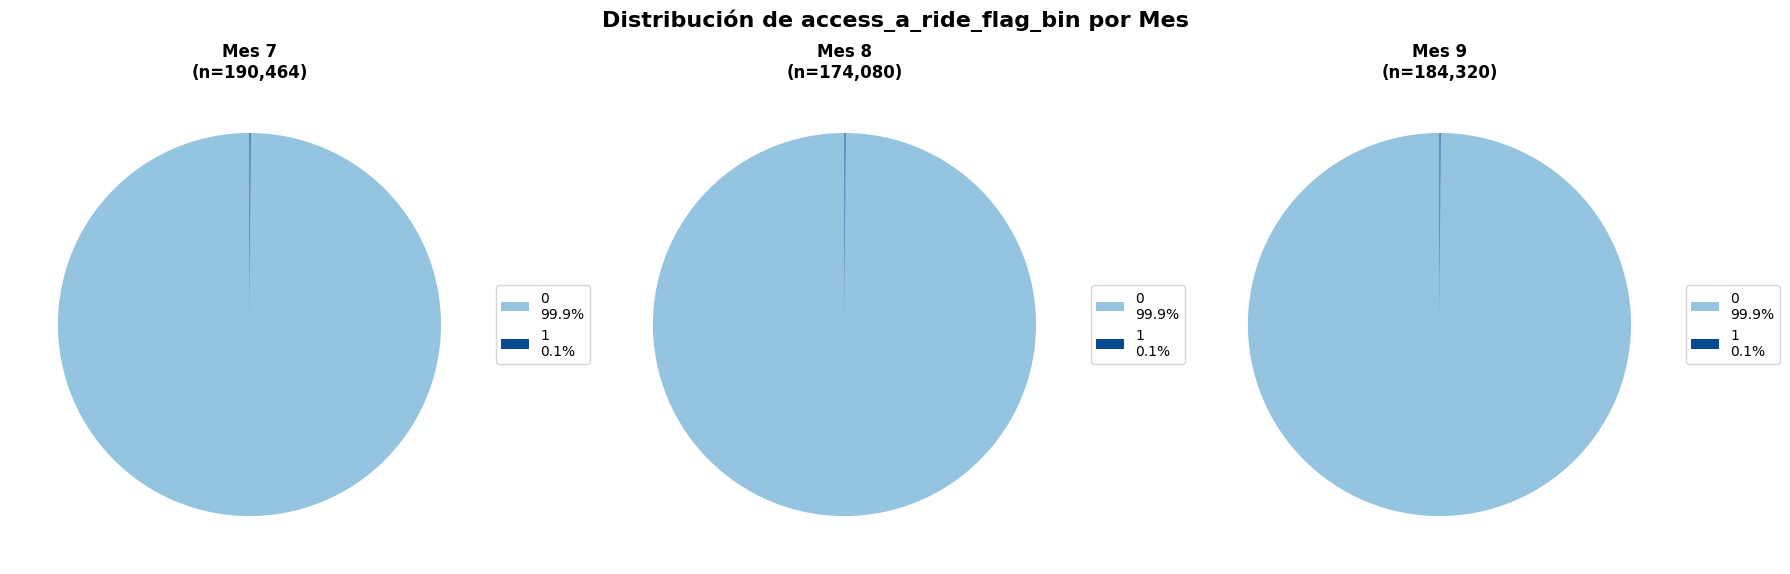


Generando gráfico para: shared_match_flag_bin


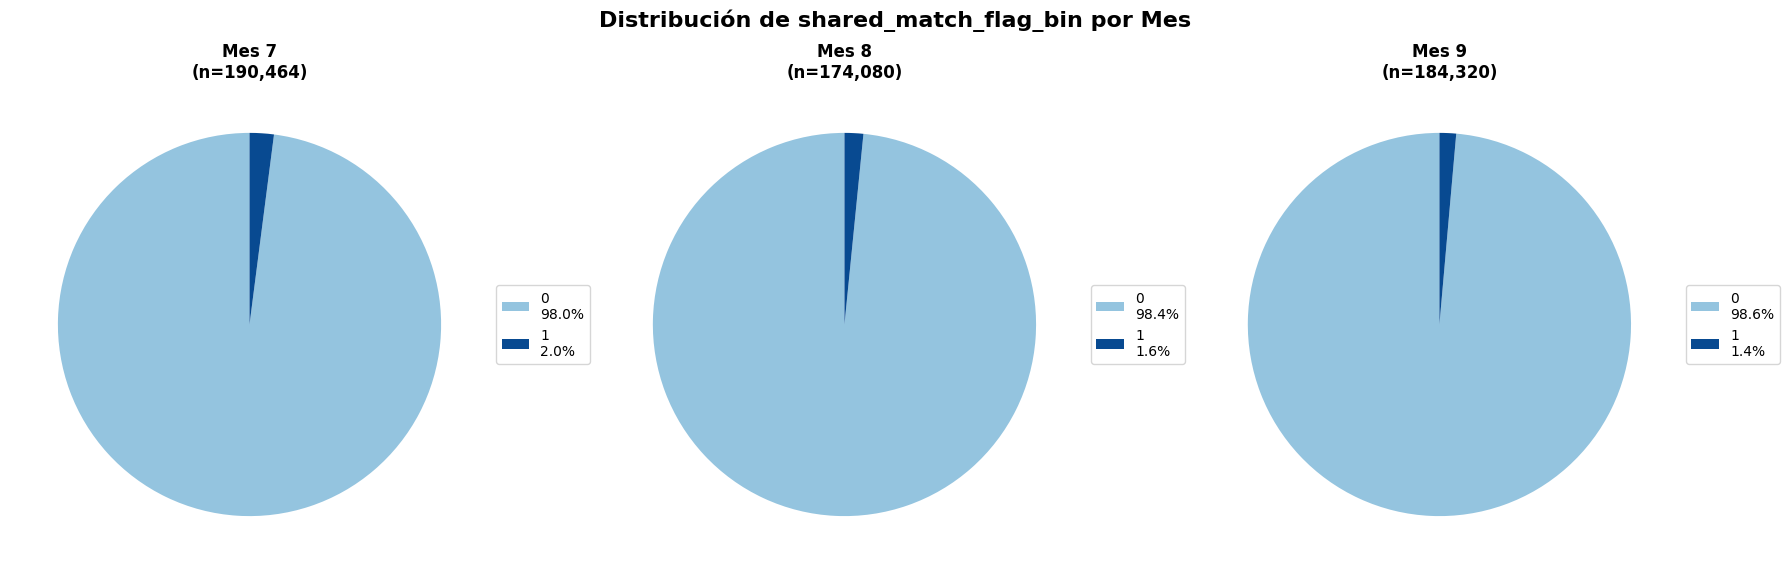


Generando gráfico para: shared_request_flag_bin


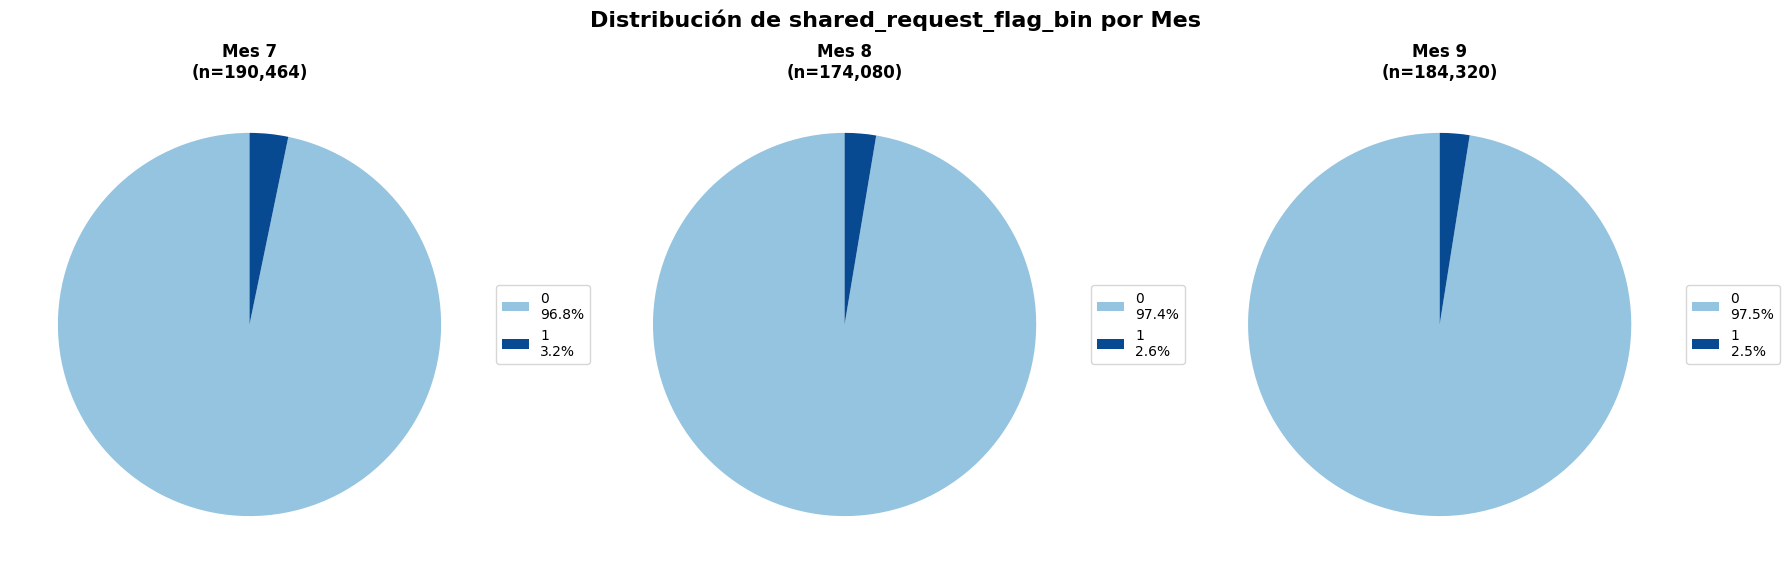


Generando gráfico para: wav_match_flag_bin


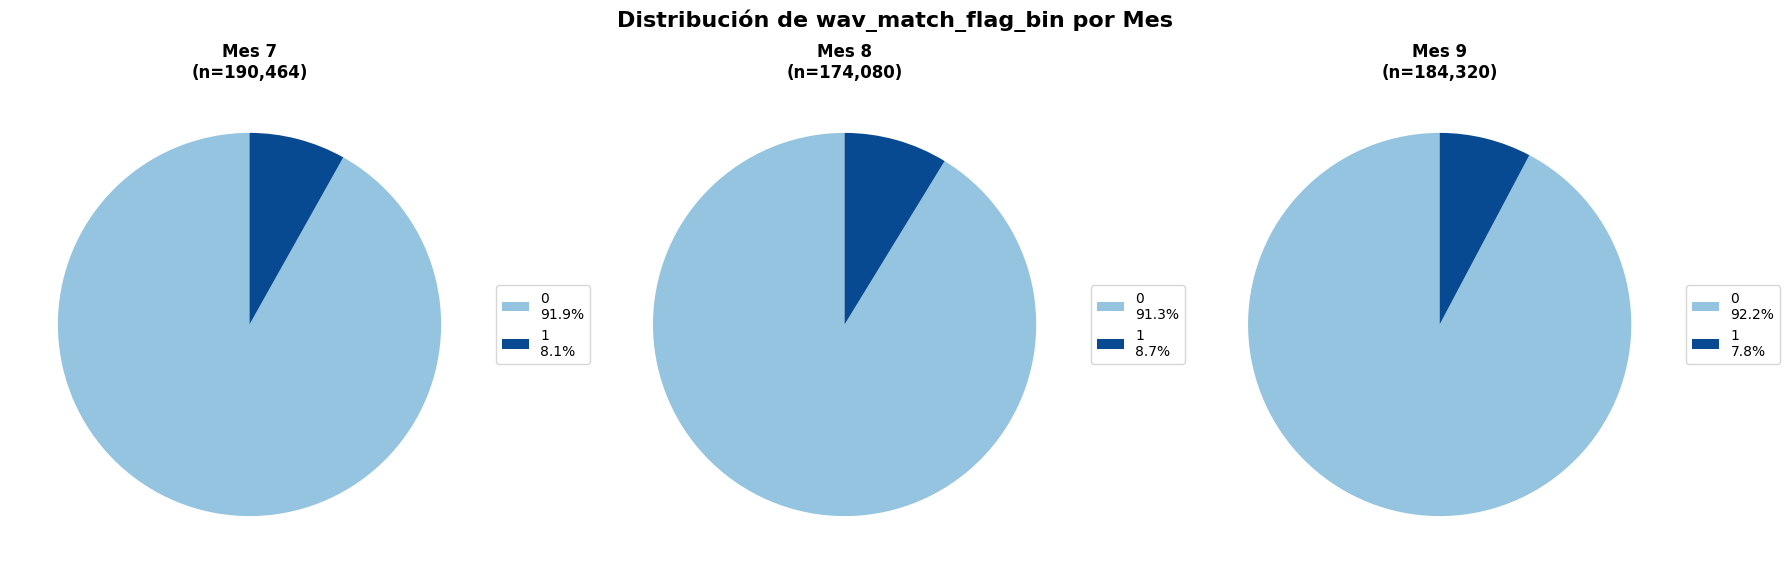


Generando gráfico para: wav_request_flag_bin


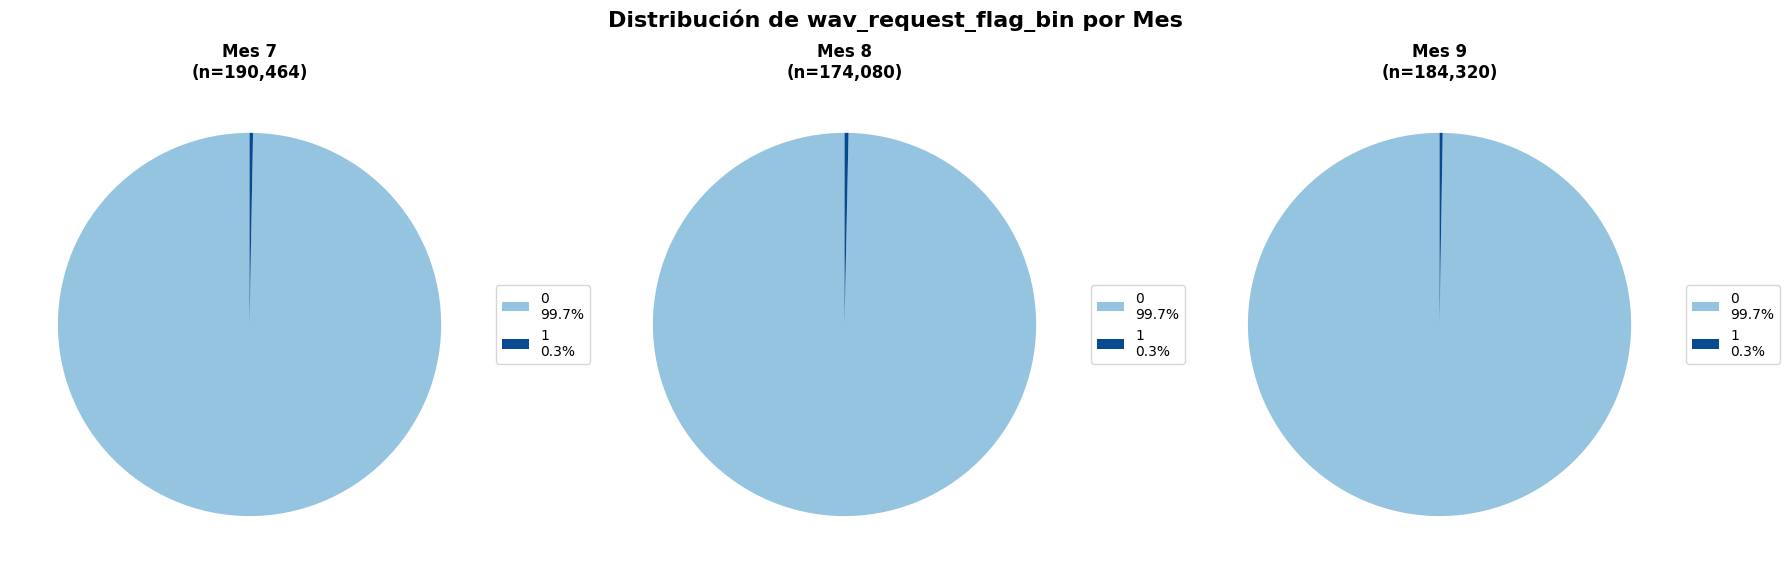

In [18]:
# Excluir las características especificadas
columns_to_exclude = ['pickup_year', 'pickup_month', 'PULocationID', 'DOLocationID', 'trip_time', 'month']

print(f"\nGenerando gráficos comparativos por mes...")
df_hvfhs_int = df_hvfhs.select_dtypes(include=['int64', 'int32']).columns.tolist()

# Filtrar columnas excluyendo las especificadas
df_hvfhs_int = [col for col in df_hvfhs_int if col not in columns_to_exclude]

print("Columnas de tipo entero después de excluir:", df_hvfhs_int)

# Verificar y crear columna de mes
if 'month' not in df_hvfhs.columns and 'pickup_datetime' in df_hvfhs.columns:
    df_hvfhs['month'] = df_hvfhs['pickup_datetime'].dt.month

unique_months = sorted(df_hvfhs['month'].unique())
num_vars = len(df_hvfhs_int)

if num_vars == 0:
    print("No se encontraron variables categóricas para graficar.")
else:
    for col in df_hvfhs_int:
        print(f"\nGenerando gráfico para: {col}")
        
        # Crear figura con subplots para cada mes
        fig, axes = plt.subplots(1, len(unique_months), figsize=(6*len(unique_months), 6))
        if len(unique_months) == 1:
            axes = [axes]
        
        fig.suptitle(f'Distribución de {col} por Mes', fontsize=16, fontweight='bold')
        
        for j, month in enumerate(unique_months):
            ax = axes[j]
            month_data = df_hvfhs[df_hvfhs['month'] == month]
            
            # Calcular conteos para el mes
            value_counts = month_data[col].value_counts()
            if len(value_counts) > 8:
                plot_data = value_counts.head(7)
                plot_data['Otros'] = value_counts[7:].sum()
            else:
                plot_data = value_counts

            # Crear gráfico de pie
            colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(plot_data)))
            wedges, texts = ax.pie(
                plot_data.values,
                labels=None,
                autopct=None,
                colors=colors,
                startangle=90
            )
            ax.set_title(f'Mes {month}\n(n={len(month_data):,})', fontweight='bold')

            # Leyenda simplificada
            total = plot_data.sum()
            legend_labels = [f'{label}\n{val/total:.1%}' for label, val in zip(plot_data.index, plot_data.values)]
            ax.legend(wedges, legend_labels, loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

        plt.tight_layout()
        plt.show()

# Top 10 Zonas de Pickup HVFHS


Generando top 10 PULocationID por mes...


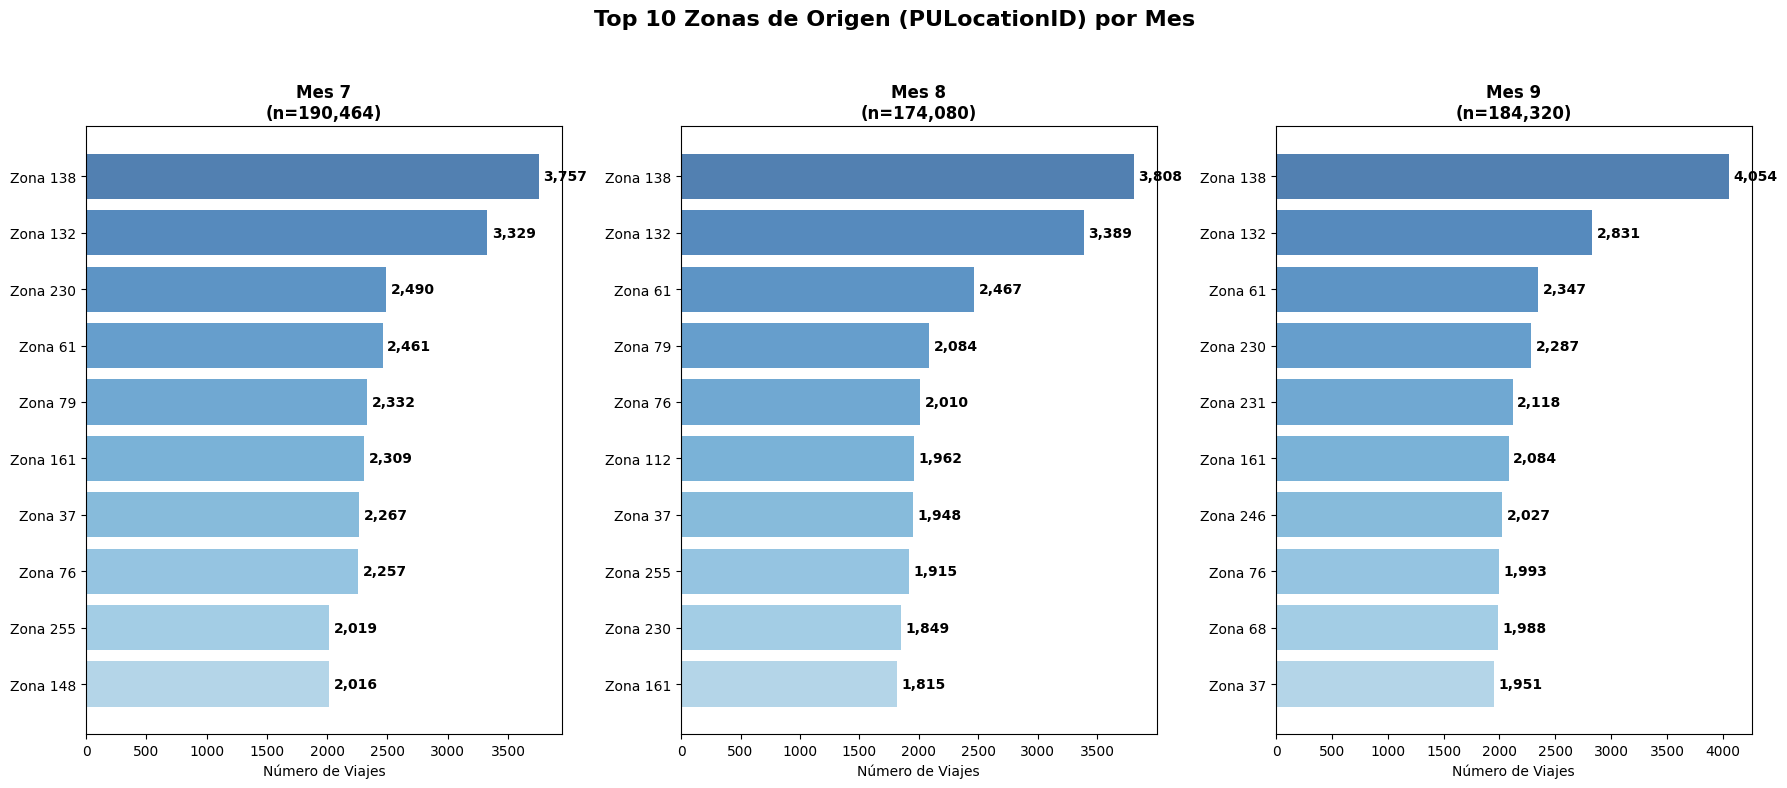


Estadísticas PULocationID:
- Total zonas únicas: 260
- Zona más frecuente: 138


In [19]:
print(f"\nGenerando top 10 PULocationID por mes...")

# Verificar y crear columna de mes
if 'month' not in df_hvfhs.columns and 'pickup_datetime' in df_hvfhs.columns:
    df_hvfhs['month'] = df_hvfhs['pickup_datetime'].dt.month
unique_months = sorted(df_hvfhs['month'].unique())


# Crear figura para PULocationID
fig, axes = plt.subplots(1, len(unique_months), figsize=(6*len(unique_months), 8))
if len(unique_months) == 1:
    axes = [axes]

fig.suptitle('Top 10 Zonas de Origen (PULocationID) por Mes', fontsize=16, fontweight='bold')

for j, month in enumerate(unique_months):
    ax = axes[j]
    month_data = df_hvfhs[df_hvfhs['month'] == month]
    
    # Top 10 PULocationID - value_counts ya ordena de mayor a menor
    value_counts = month_data['PULocationID'].value_counts().head(10)
    
    # INVERTIR el orden para que el mayor quede arriba en gráfico horizontal
    value_counts = value_counts.iloc[::-1]  # Esta línea invierte el orden
    
    # Gráfico de barras horizontal
    y_pos = range(len(value_counts))
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(value_counts)))
    
    bars = ax.barh(y_pos, value_counts.values, color=colors, alpha=0.7)
    ax.set_title(f'Mes {month}\n(n={len(month_data):,})', fontweight='bold')
    ax.set_xlabel('Número de Viajes')
    
    # Configurar etiquetas
    ax.set_yticks(y_pos)
    ax.set_yticklabels([f'Zona {idx}' for idx in value_counts.index])
    
    # Agregar valores
    for k, (idx, v) in enumerate(zip(value_counts.index, value_counts.values)):
        ax.text(v + max(value_counts.values)*0.01, k, f'{v:,}', va='center', fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Estadísticas
print(f"\nEstadísticas PULocationID:")
print(f"- Total zonas únicas: {df_hvfhs['PULocationID'].nunique()}")
print(f"- Zona más frecuente: {df_hvfhs['PULocationID'].mode().iloc[0]}")

# Top 10 Zonas de Dropoff HVFHS


Generando top 10 DOLocationID por mes...


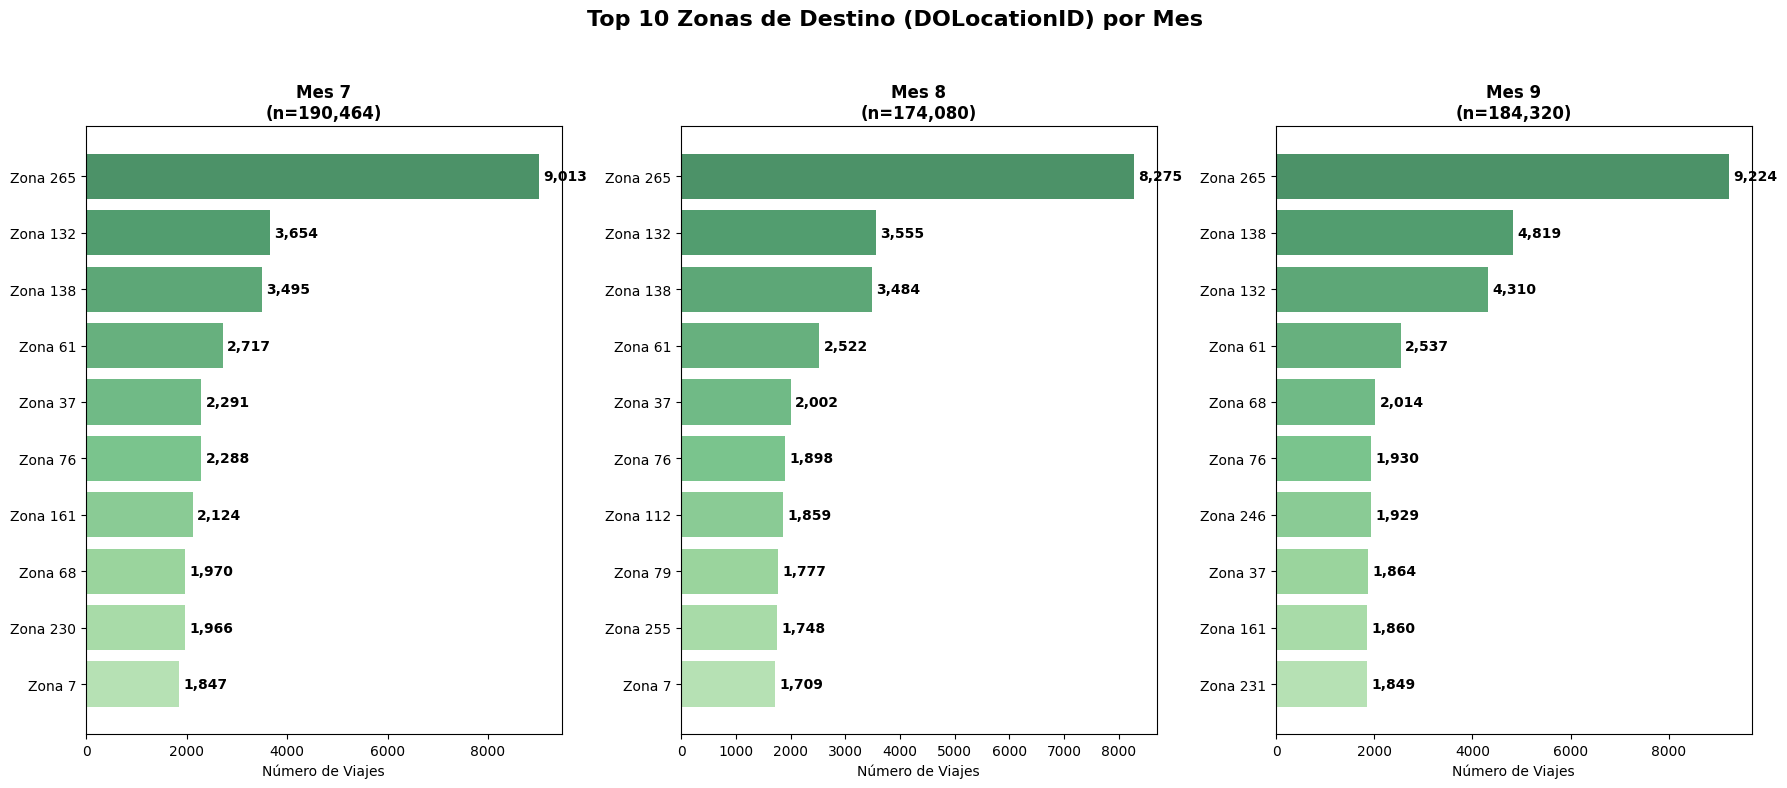


Estadísticas DOLocationID:
- Total zonas únicas: 260
- Zona más frecuente: 265


In [20]:
print(f"\nGenerando top 10 DOLocationID por mes...")

# Crear figura para DOLocationID
fig, axes = plt.subplots(1, len(unique_months), figsize=(6*len(unique_months), 8))
if len(unique_months) == 1:
    axes = [axes]

fig.suptitle('Top 10 Zonas de Destino (DOLocationID) por Mes', fontsize=16, fontweight='bold')

for j, month in enumerate(unique_months):
    ax = axes[j]
    month_data = df_hvfhs[df_hvfhs['month'] == month]
    
    # Top 10 DOLocationID - value_counts ya ordena de mayor a menor
    value_counts = month_data['DOLocationID'].value_counts().head(10)
    
    # INVERTIR el orden para que el mayor quede arriba en gráfico horizontal
    value_counts = value_counts.iloc[::-1]  # Esta línea invierte el orden
    
    # Gráfico de barras horizontal
    y_pos = range(len(value_counts))
    colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(value_counts)))
    
    bars = ax.barh(y_pos, value_counts.values, color=colors, alpha=0.7)
    ax.set_title(f'Mes {month}\n(n={len(month_data):,})', fontweight='bold')
    ax.set_xlabel('Número de Viajes')
    
    # Configurar etiquetas
    ax.set_yticks(y_pos)
    ax.set_yticklabels([f'Zona {idx}' for idx in value_counts.index])
    
    # Agregar valores
    for k, (idx, v) in enumerate(zip(value_counts.index, value_counts.values)):
        ax.text(v + max(value_counts.values)*0.01, k, f'{v:,}', va='center', fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Estadísticas
print(f"\nEstadísticas DOLocationID:")
print(f"- Total zonas únicas: {df_hvfhs['DOLocationID'].nunique()}")
print(f"- Zona más frecuente: {df_hvfhs['DOLocationID'].mode().iloc[0]}")

# Duración de Viajes HVFHS por Mes


Generando distribución de trip_time por mes...


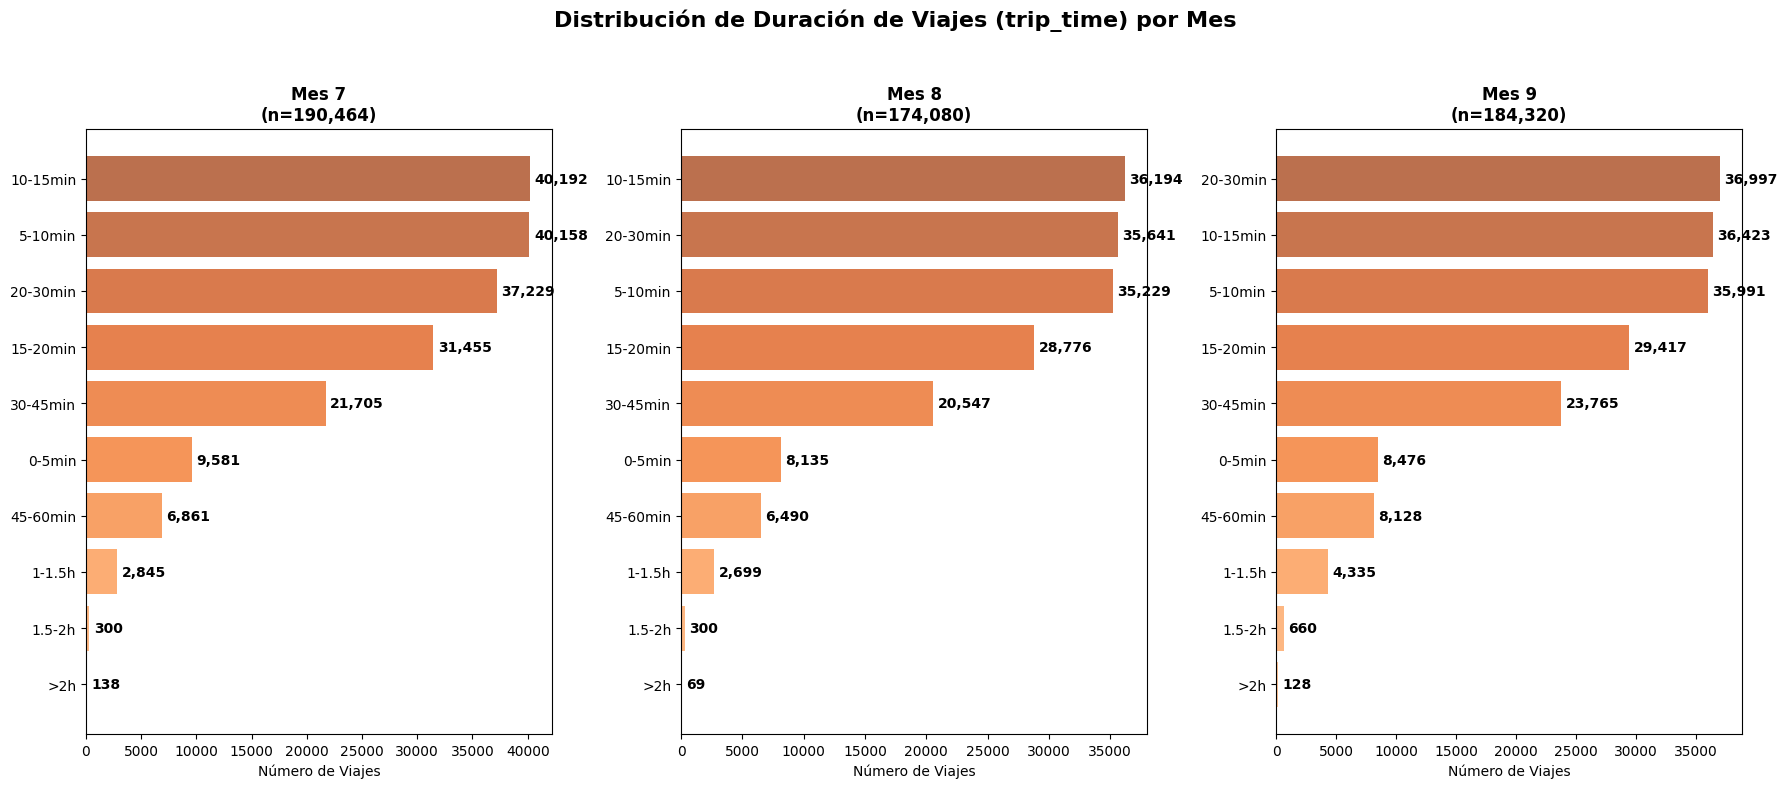


Estadísticas trip_time (en minutos):
- Media: 19.9 minutos
- Mediana: 16.2 minutos
- Mínimo: 0.0 minutos
- Máximo: 575.6 minutos


In [21]:
print(f"\nGenerando distribución de trip_time por mes...")

# Crear figura para trip_time
fig, axes = plt.subplots(1, len(unique_months), figsize=(6*len(unique_months), 8))
if len(unique_months) == 1:
    axes = [axes]

fig.suptitle('Distribución de Duración de Viajes (trip_time) por Mes', fontsize=16, fontweight='bold')

for j, month in enumerate(unique_months):
    ax = axes[j]
    month_data = df_hvfhs[df_hvfhs['month'] == month]
    
    # Crear buckets para trip_time (en minutos)
    bins = [0, 5, 10, 15, 20, 30, 45, 60, 90, 120, float('inf')]
    labels = ['0-5min', '5-10min', '10-15min', '15-20min', '20-30min', 
              '30-45min', '45-60min', '1-1.5h', '1.5-2h', '>2h']
    
    month_data['trip_time_min'] = month_data['trip_time'] / 60
    month_data['trip_time_bucket'] = pd.cut(month_data['trip_time_min'], bins=bins, labels=labels)
    value_counts = month_data['trip_time_bucket'].value_counts().head(10)
    
    # INVERTIR el orden para que la categoría más frecuente quede arriba
    value_counts = value_counts.iloc[::-1]
    
    # Gráfico de barras horizontal
    y_pos = range(len(value_counts))
    colors = plt.cm.Oranges(np.linspace(0.4, 0.9, len(value_counts)))
    
    bars = ax.barh(y_pos, value_counts.values, color=colors, alpha=0.7)
    ax.set_title(f'Mes {month}\n(n={len(month_data):,})', fontweight='bold')
    ax.set_xlabel('Número de Viajes')
    
    # Configurar etiquetas
    ax.set_yticks(y_pos)
    ax.set_yticklabels(value_counts.index)
    
    # Agregar valores
    for k, (idx, v) in enumerate(zip(value_counts.index, value_counts.values)):
        ax.text(v + max(value_counts.values)*0.01, k, f'{v:,}', va='center', fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Estadísticas
print(f"\nEstadísticas trip_time (en minutos):")
trip_minutes = df_hvfhs['trip_time'] / 60
print(f"- Media: {trip_minutes.mean():.1f} minutos")
print(f"- Mediana: {trip_minutes.median():.1f} minutos")
print(f"- Mínimo: {trip_minutes.min():.1f} minutos")
print(f"- Máximo: {trip_minutes.max():.1f} minutos")

# Distribución de Temporal de Viajes por Mes en HVFHS


Generando gráfico comparativo para: pickup_day


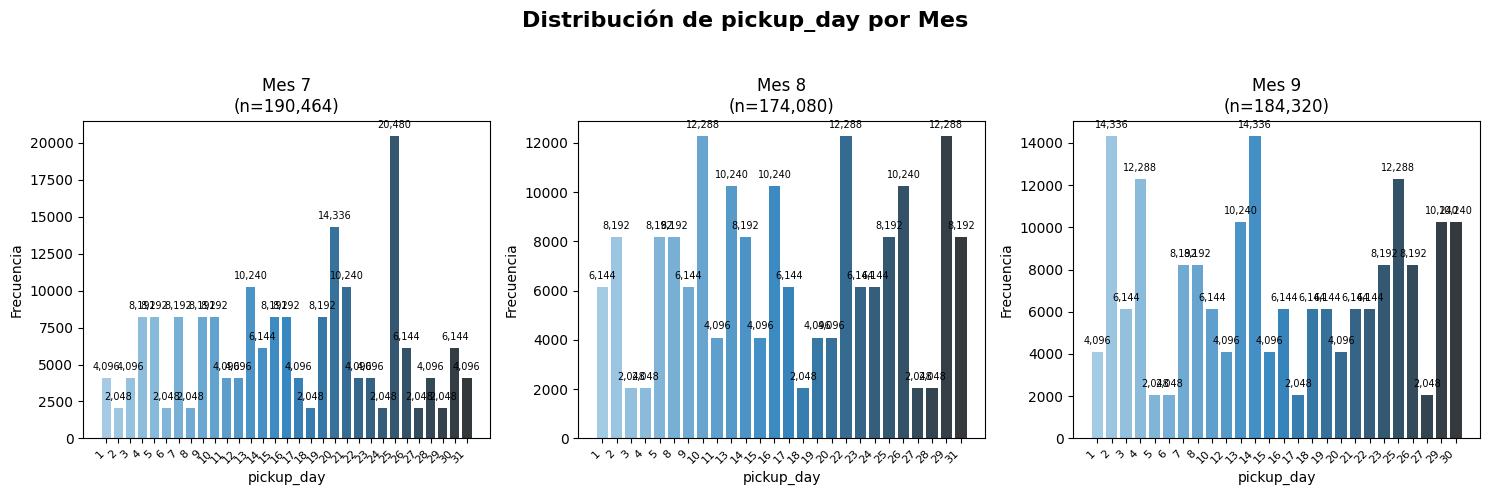


Generando gráfico comparativo para: pickup_hour


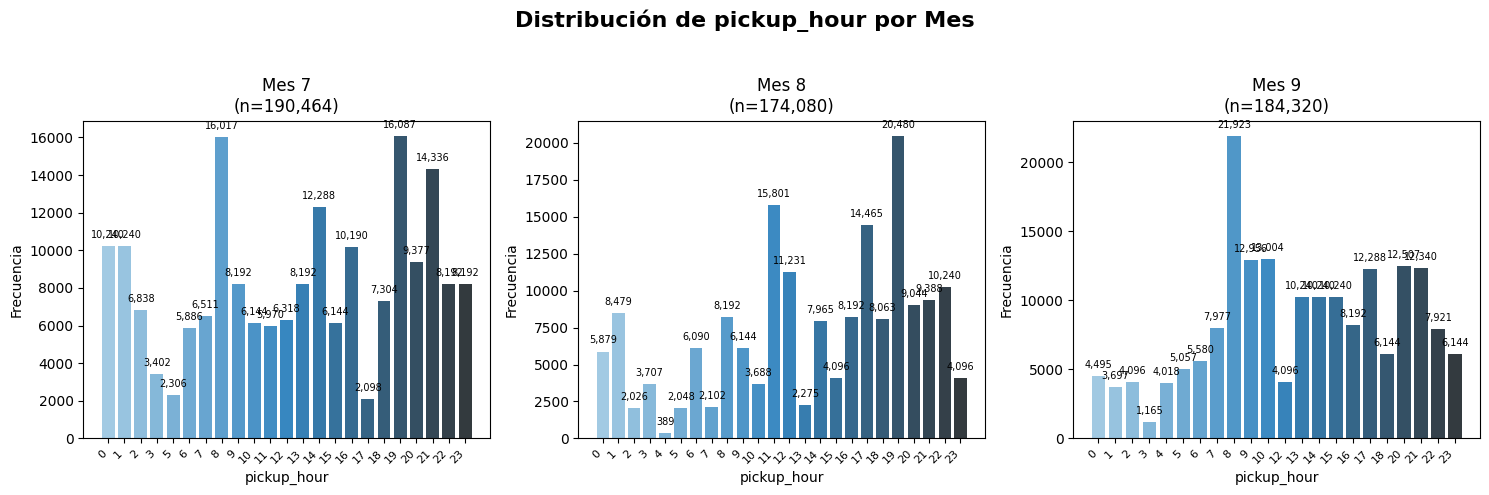


Generando gráfico comparativo para: pickup_day_of_week


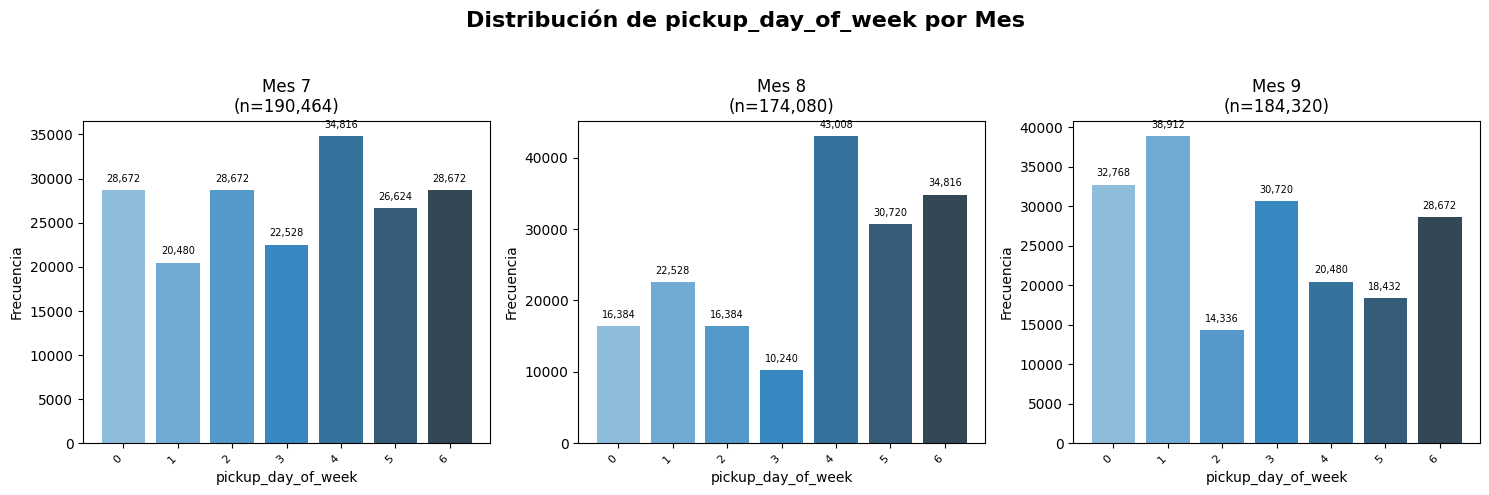


Generando gráfico comparativo para: is_weekend


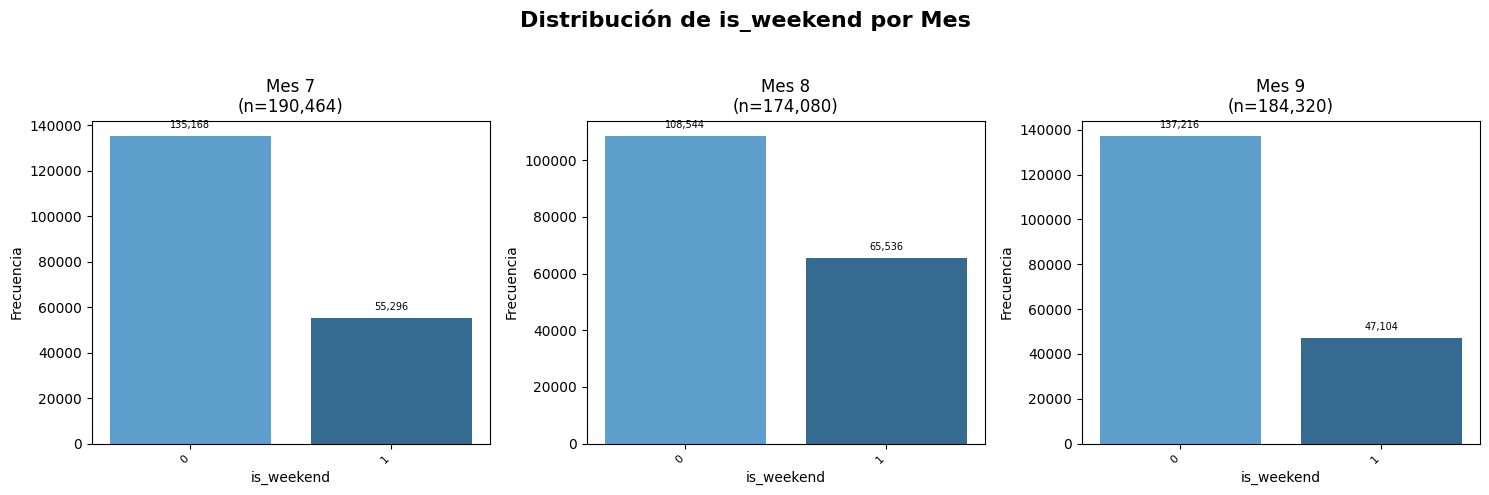


Generando gráfico comparativo para: access_a_ride_flag_bin


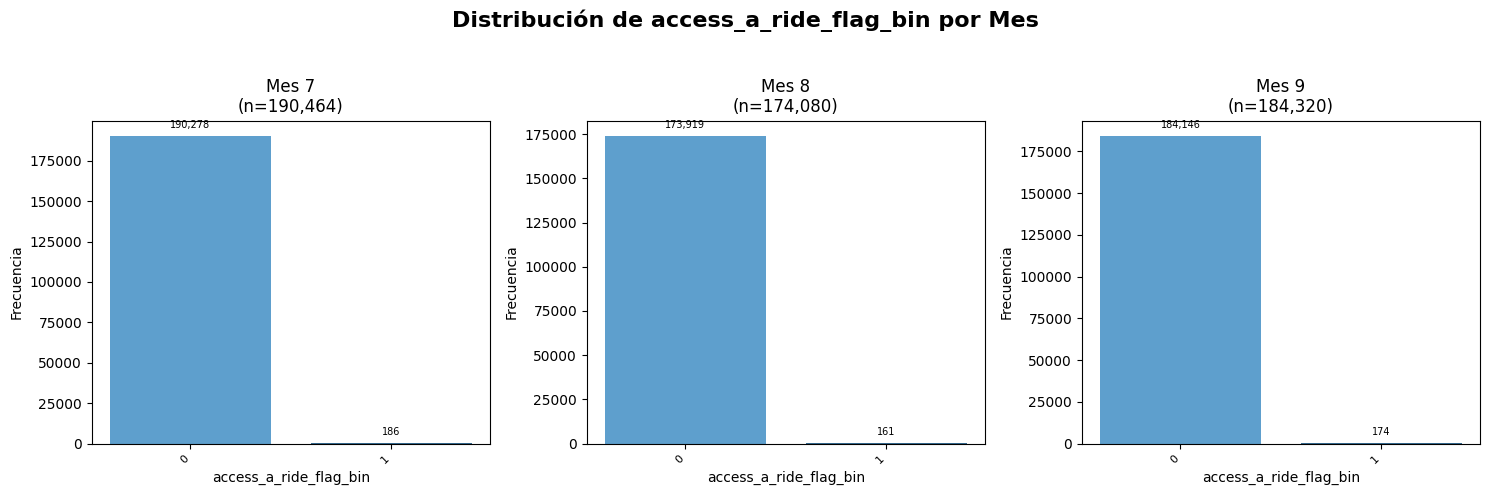


Generando gráfico comparativo para: shared_match_flag_bin


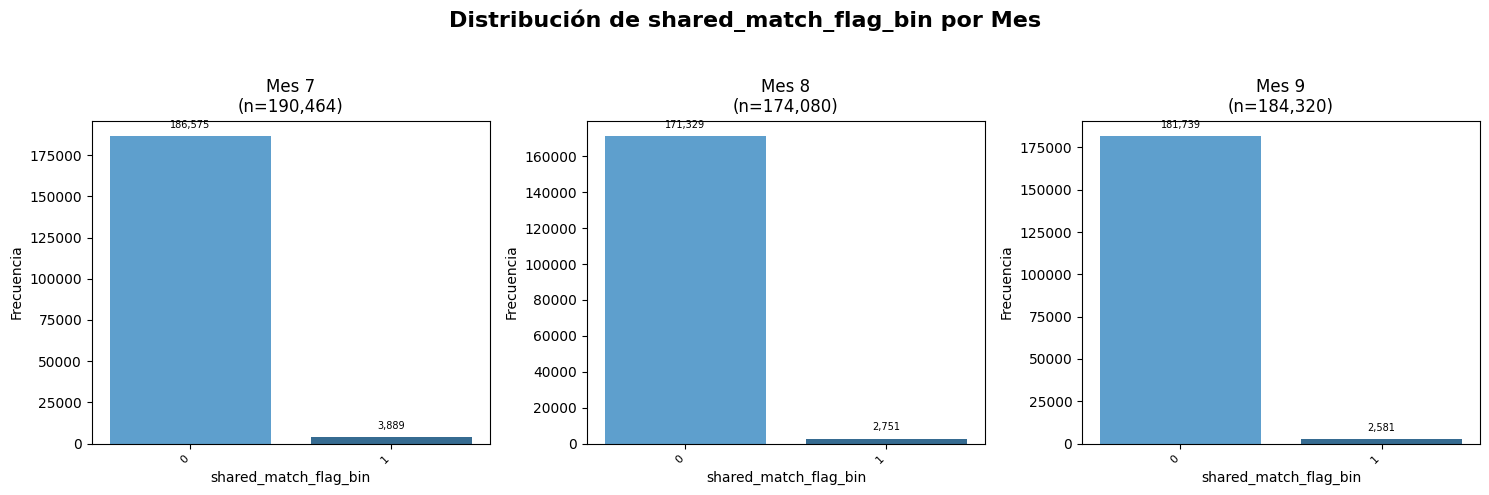


Generando gráfico comparativo para: shared_request_flag_bin


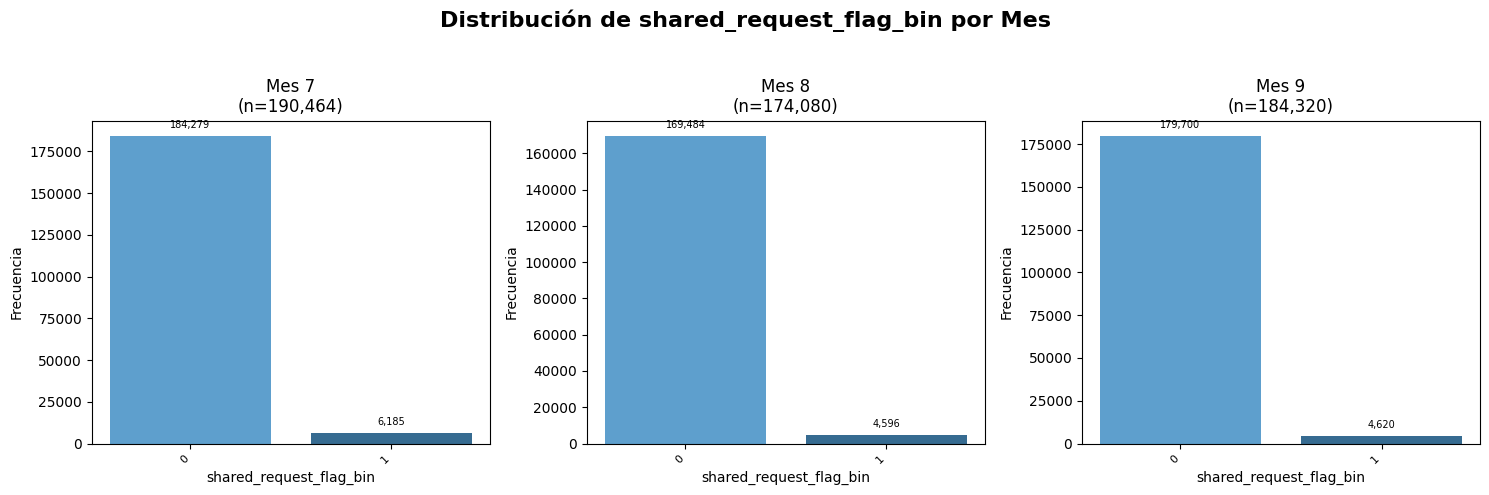


Generando gráfico comparativo para: wav_match_flag_bin


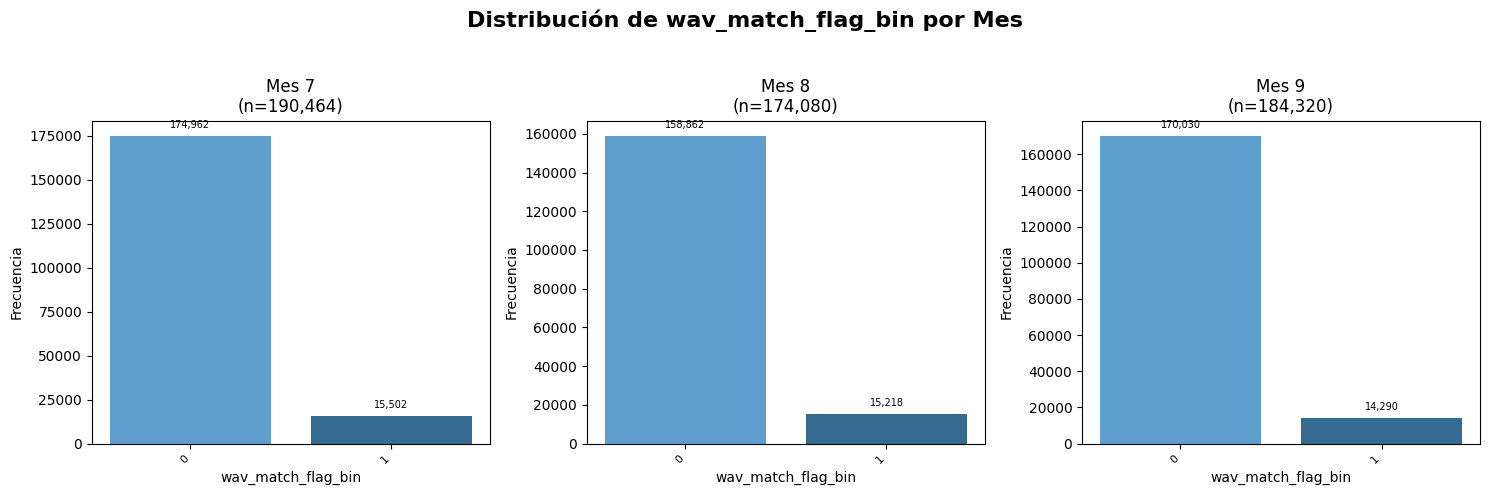


Generando gráfico comparativo para: wav_request_flag_bin


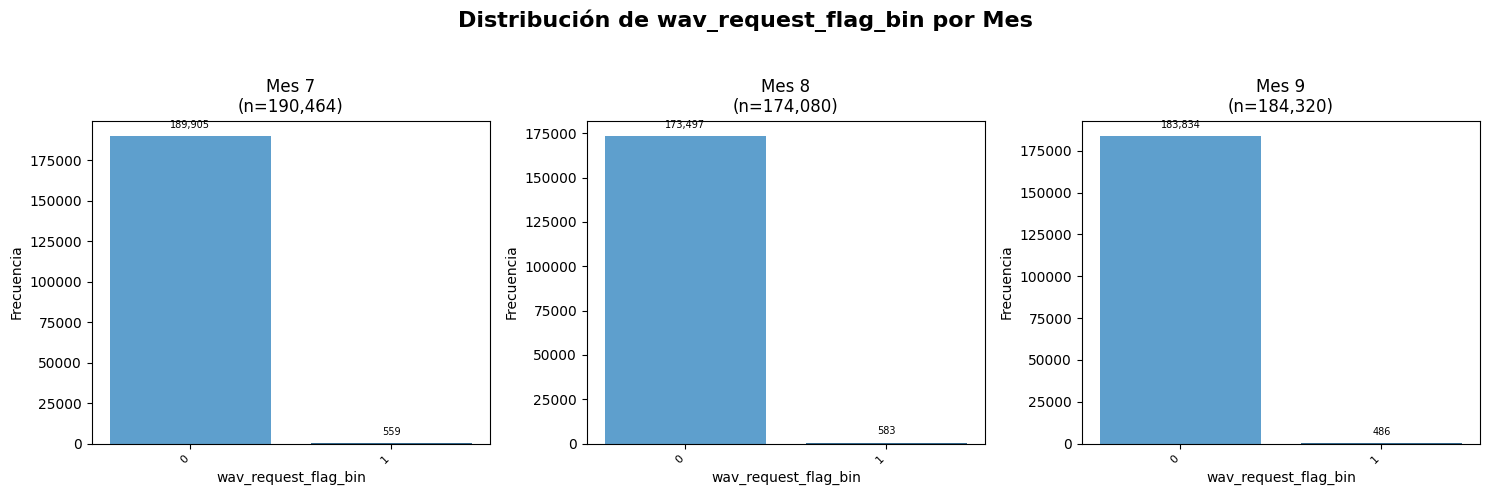

In [22]:
# Seleccionar columnas categóricas
cat_cols = df_hvfhs.select_dtypes(include=[ 'int32']).columns.tolist()
columns_to_exclude = ['pickup_year', 'pickup_month', 'PULocationID', 'DOLocationID', 'month']
cat_cols = [col for col in cat_cols if col not in columns_to_exclude]

# Obtener meses
if 'pickup_month' in df_hvfhs.columns:
    unique_months = sorted(df_hvfhs['pickup_month'].unique())
else:
    unique_months = ['Todos']

# Para cada variable categórica, crear gráfico comparativo por mes
for col in cat_cols[:15]:  # Limitar a las primeras 15 variables para no saturar
    print(f"\nGenerando gráfico comparativo para: {col}")
    
    fig, axes = plt.subplots(1, len(unique_months), figsize=(5*len(unique_months), 5))
    if len(unique_months) == 1:
        axes = [axes]
    
    fig.suptitle(f'Distribución de {col} por Mes', fontsize=16, fontweight='bold')
    
    for j, month in enumerate(unique_months):
        # Filtrar datos por mes
        if month != 'Todos':
            month_data = df_hvfhs[df_hvfhs['pickup_month'] == month]
        else:
            month_data = df_hvfhs

        # Obtener distribución
        value_counts = month_data[col].value_counts(dropna=False).sort_index()
        # Manejar etiquetas de índice para NaN
        index_labels = [str(x) if pd.notna(x) else 'Missing' for x in value_counts.index]
        
        # Crear gráfico
        x_positions = range(len(value_counts))
        axes[j].bar(x_positions, value_counts.values, color=sns.color_palette("Blues_d", len(value_counts)))
        axes[j].set_title(f'Mes {month}\n(n={len(month_data):,})')
        axes[j].set_xlabel(col)
        axes[j].set_ylabel('Frecuencia')
        axes[j].set_xticks(x_positions)
        axes[j].set_xticklabels(index_labels, rotation=45, ha='right', fontsize=8)
        
        # Agregar valores
        if len(value_counts) > 0:
            ymax = value_counts.values.max()
            for k, v in enumerate(value_counts.values):
                axes[j].text(k, v + ymax * 0.02, f'{v:,}', ha='center', va='bottom', fontsize=7)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Cantidad de Viajes según Banda Horaria en HVFHS

1. Distribución de time_band


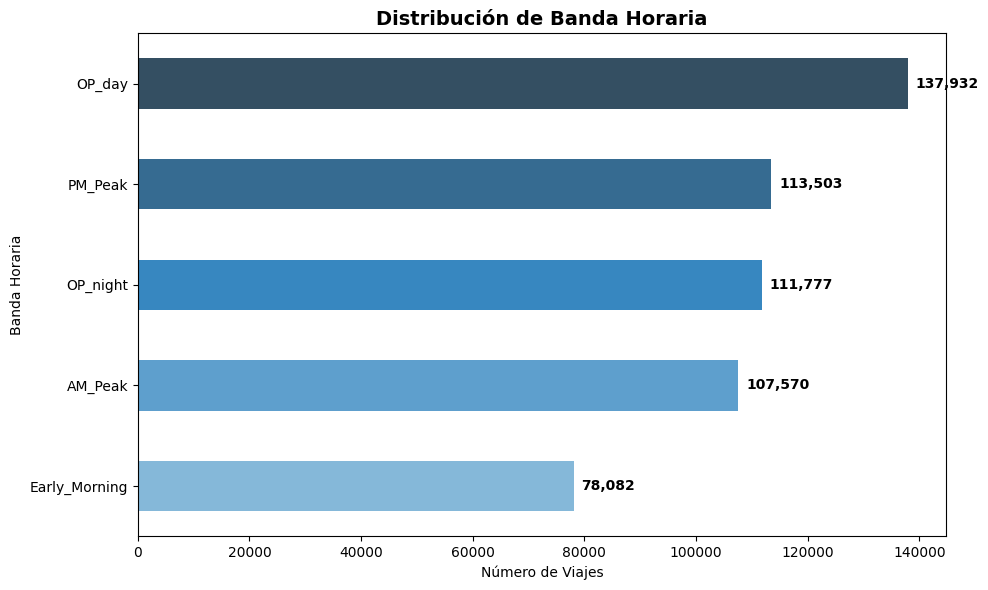

In [23]:
# 1. DISTRIBUCIÓN DE Time_Bands
print("1. Distribución de time_band")

time_band_counts = df_hvfhs['time_band'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
time_band_counts.plot(kind='barh', color=sns.color_palette("Blues_d", len(time_band_counts)))
plt.title('Distribución de Banda Horaria', fontsize=14, fontweight='bold')
plt.xlabel('Número de Viajes')
plt.ylabel('Banda Horaria')

for i, v in enumerate(time_band_counts.values):
    plt.text(v + time_band_counts.max() * 0.01, i, f'{v:,}', 
             va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Top 10 Zonas de Pickup y Dropoff durante AM Peak HVFHS

2. Top Locations - AM Peak


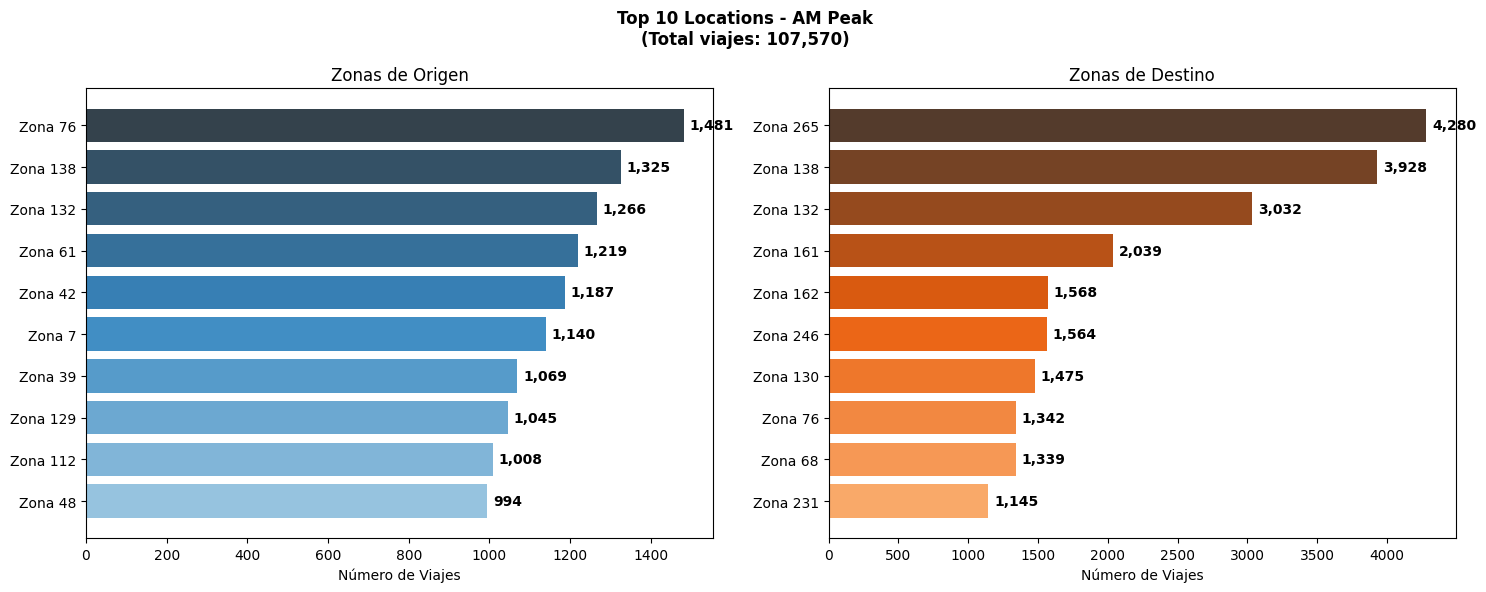

In [24]:
# 2. TOP LOCATIONS - AM PEAK
print("2. Top Locations - AM Peak")

am_peak_data = df_hvfhs[df_hvfhs['time_band'] == 'AM_Peak']
top_pu_am = am_peak_data['PULocationID'].value_counts().head(10).sort_values(ascending=True)
top_do_am = am_peak_data['DOLocationID'].value_counts().head(10).sort_values(ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'Top 10 Locations - AM Peak\n(Total viajes: {len(am_peak_data):,})', fontweight='bold')

# Origen
ax1.barh(range(len(top_pu_am)), top_pu_am.values, color=sns.color_palette("Blues_d", len(top_pu_am)))
ax1.set_title('Zonas de Origen')
ax1.set_xlabel('Número de Viajes')
ax1.set_yticks(range(len(top_pu_am)))
ax1.set_yticklabels([f'Zona {idx}' for idx in top_pu_am.index])

for i, v in enumerate(top_pu_am.values):
    ax1.text(v + top_pu_am.max() * 0.01, i, f'{v:,}', va='center', fontweight='bold')

# Destino
ax2.barh(range(len(top_do_am)), top_do_am.values, color=sns.color_palette("Oranges_d", len(top_do_am)))
ax2.set_title('Zonas de Destino')
ax2.set_xlabel('Número de Viajes')
ax2.set_yticks(range(len(top_do_am)))
ax2.set_yticklabels([f'Zona {idx}' for idx in top_do_am.index])

for i, v in enumerate(top_do_am.values):
    ax2.text(v + top_do_am.max() * 0.01, i, f'{v:,}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Top 10 Zonas de Pickup y Dropoff durante PM Peak HVFHS

3. Top Locations - PM Peak


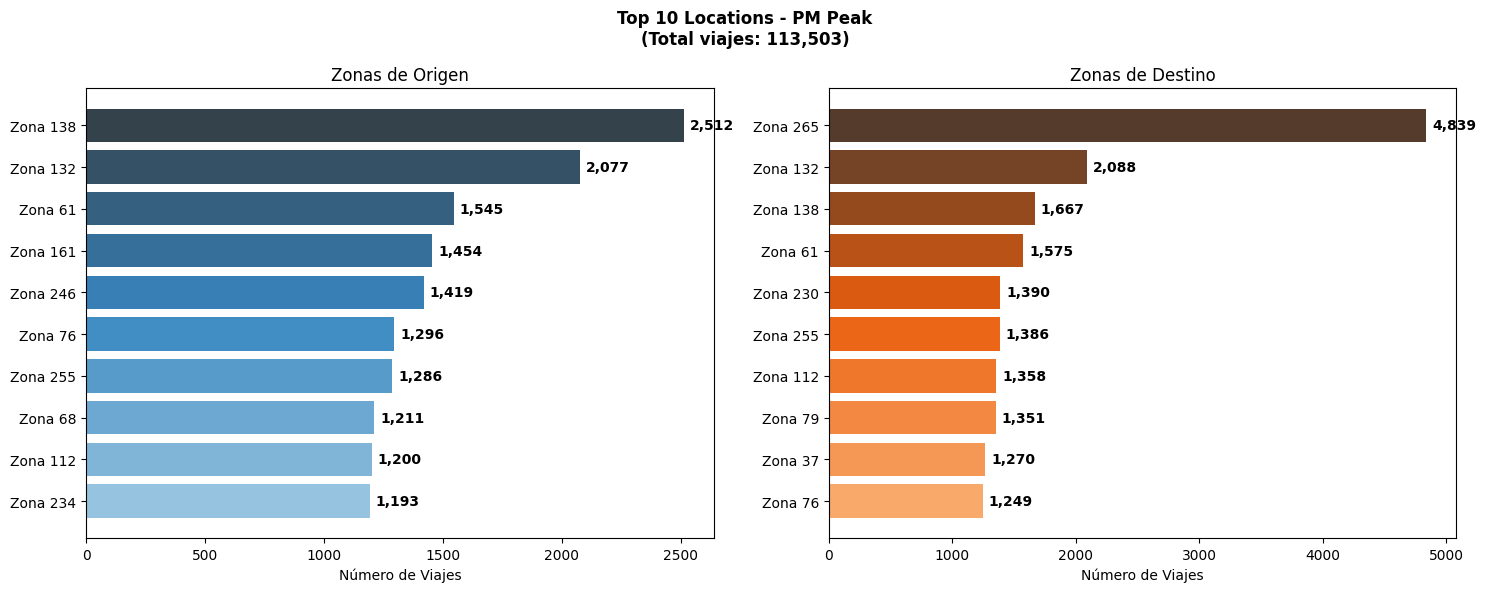

In [25]:
# 3. TOP LOCATIONS - PM PEAK
print("3. Top Locations - PM Peak")

pm_peak_data = df_hvfhs[df_hvfhs['time_band'] == 'PM_Peak']
top_pu_pm = pm_peak_data['PULocationID'].value_counts().head(10).sort_values(ascending=True)
top_do_pm = pm_peak_data['DOLocationID'].value_counts().head(10).sort_values(ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'Top 10 Locations - PM Peak\n(Total viajes: {len(pm_peak_data):,})', fontweight='bold')

# Origen
ax1.barh(range(len(top_pu_pm)), top_pu_pm.values, color=sns.color_palette("Blues_d", len(top_pu_pm)))
ax1.set_title('Zonas de Origen')
ax1.set_xlabel('Número de Viajes')
ax1.set_yticks(range(len(top_pu_pm)))
ax1.set_yticklabels([f'Zona {idx}' for idx in top_pu_pm.index])

for i, v in enumerate(top_pu_pm.values):
    ax1.text(v + top_pu_pm.max() * 0.01, i, f'{v:,}', va='center', fontweight='bold')

# Destino
ax2.barh(range(len(top_do_pm)), top_do_pm.values, color=sns.color_palette("Oranges_d", len(top_do_pm)))
ax2.set_title('Zonas de Destino')
ax2.set_xlabel('Número de Viajes')
ax2.set_yticks(range(len(top_do_pm)))
ax2.set_yticklabels([f'Zona {idx}' for idx in top_do_pm.index])

for i, v in enumerate(top_do_pm.values):
    ax2.text(v + top_do_pm.max() * 0.01, i, f'{v:,}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Evolución Mensual Peak Hours HVFHS

4. Evolución Mensual Peak Hours


<Figure size 1000x600 with 0 Axes>

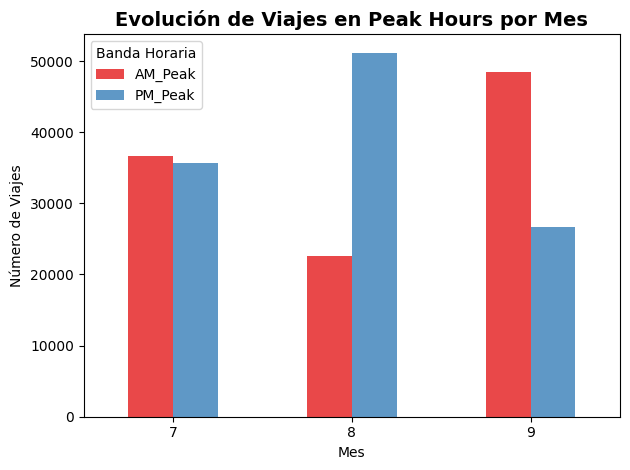

In [26]:
# 4. EVOLUCIÓN MENSUAL HORAS PICO
print("4. Evolución Mensual Peak Hours")

if 'month' in df_hvfhs.columns:
    monthly_peak = df_hvfhs[df_hvfhs['time_band'].isin(['AM_Peak', 'PM_Peak'])].groupby(['month', 'time_band']).size().unstack()
    
    plt.figure(figsize=(10, 6))
    monthly_peak.plot(kind='bar', color=sns.color_palette("Set1", 2), alpha=0.8)
    plt.title('Evolución de Viajes en Peak Hours por Mes', fontsize=14, fontweight='bold')
    plt.xlabel('Mes')
    plt.ylabel('Número de Viajes')
    plt.xticks(rotation=0)
    plt.legend(title='Banda Horaria')
    
    plt.tight_layout()
    plt.show()

# Distribución por Proveedor de Servicios HVFHS

5. Distribución por Proveedor


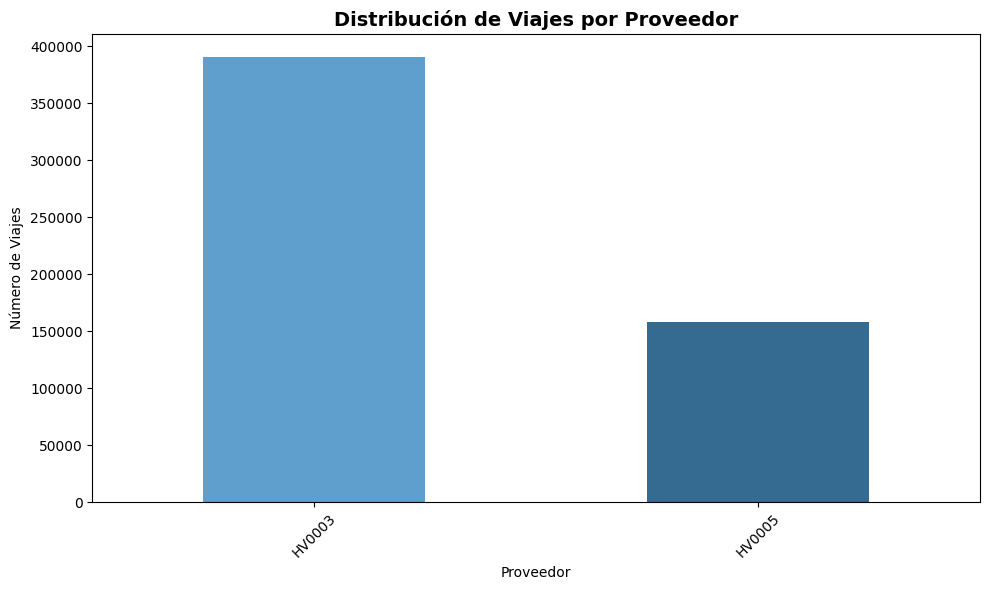


1. DISTRIBUCIÓN GENERAL POR PROVEEDOR:
Total de viajes: 548,864
  HV0003 (Uber): 390,933 viajes (71.2%)
  HV0005 (Lyft): 157,931 viajes (28.8%)


In [27]:
# 5. Distribución por Proveedor
print("5. Distribución por Proveedor")
# Distribución general por proveedor
license_distribution = df_hvfhs['hvfhs_license_num'].value_counts()
total_trips = len(df_hvfhs)

# Gráfico de distribución
plt.figure(figsize=(10, 6))
license_distribution.plot(kind='bar', color=sns.color_palette("Blues_d", len(license_distribution)))
plt.title('Distribución de Viajes por Proveedor', fontsize=14, fontweight='bold')
plt.xlabel('Proveedor')
plt.ylabel('Número de Viajes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\n1. DISTRIBUCIÓN GENERAL POR PROVEEDOR:")
print(f"Total de viajes: {total_trips:,}")
for license_num, count in license_distribution.items():
    percentage = (count / total_trips) * 100
    provider_name = {
        'HV0002': 'Juno',
        'HV0003': 'Uber', 
        'HV0004': 'Via',
        'HV0005': 'Lyft'
    }.get(license_num, license_num)
    print(f"  {license_num} ({provider_name}): {count:,} viajes ({percentage:.1f}%)")

# Distribución por Banda Horaria por Proveedor


2. DISTRIBUCIÓN POR time_band:


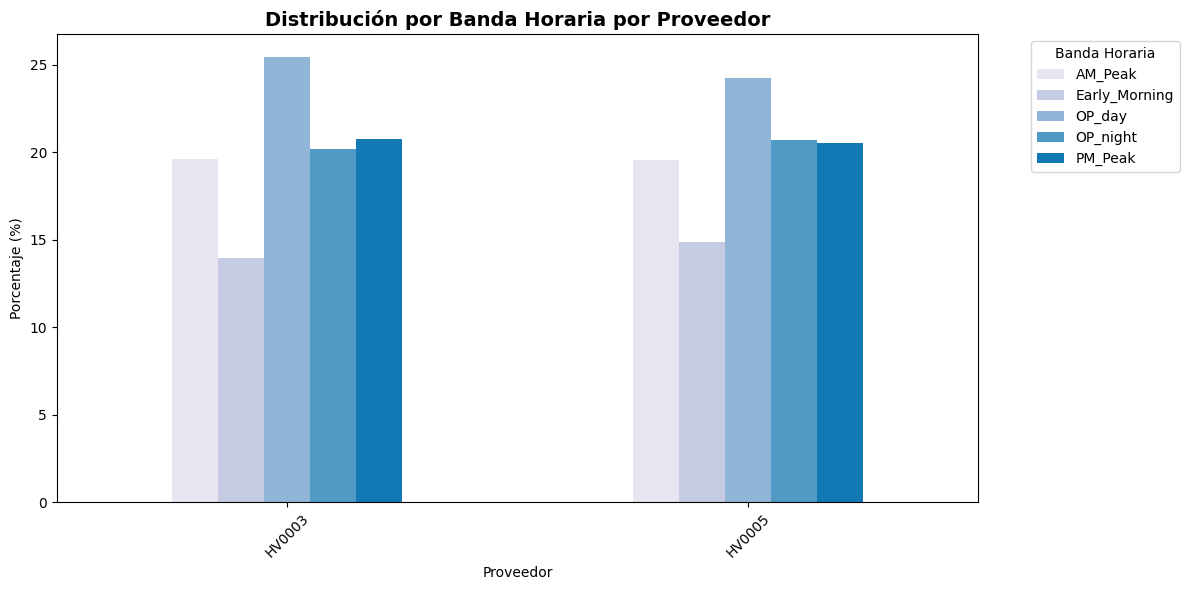


Porcentaje por time_band:

HV0003 (Uber):
  AM_Peak: 19.6%
  PM_Peak: 20.7%
  OP_day: 25.5%
  OP_night: 20.2%
  Early_Morning: 14.0%

HV0005 (Lyft):
  AM_Peak: 19.6%
  PM_Peak: 20.5%
  OP_day: 24.3%
  OP_night: 20.7%
  Early_Morning: 14.9%


In [28]:
# Distribución por bandas horarias
print("\n2. DISTRIBUCIÓN POR time_band:")

license_time_band = pd.crosstab(df_hvfhs['hvfhs_license_num'], df_hvfhs['time_band'])
license_time_percentage = license_time_band.div(license_time_band.sum(axis=1), axis=0) * 100

# Gráfico de distribución horaria
license_time_percentage.plot(kind='bar', figsize=(12, 6), color=sns.color_palette("PuBu"))
plt.title('Distribución por Banda Horaria por Proveedor', fontsize=14, fontweight='bold')
plt.xlabel('Proveedor')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=45)
plt.legend(title='Banda Horaria', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\nPorcentaje por time_band:")
for license_num in license_time_band.index:
    provider_name = {
        'HV0002': 'Juno', 'HV0003': 'Uber', 'HV0004': 'Via', 'HV0005': 'Lyft'
    }.get(license_num, license_num)
    print(f"\n{license_num} ({provider_name}):")
    for band in ['AM_Peak', 'PM_Peak', 'OP_day', 'OP_night', 'Early_Morning']:
        if band in license_time_percentage.columns:
            perc = license_time_percentage.loc[license_num, band]
            print(f"  {band}: {perc:.1f}%")

# Distribución Geográfica por Proveedor


3. DISTRIBUCIÓN GEOGRÁFICA POR PROVEEDOR:


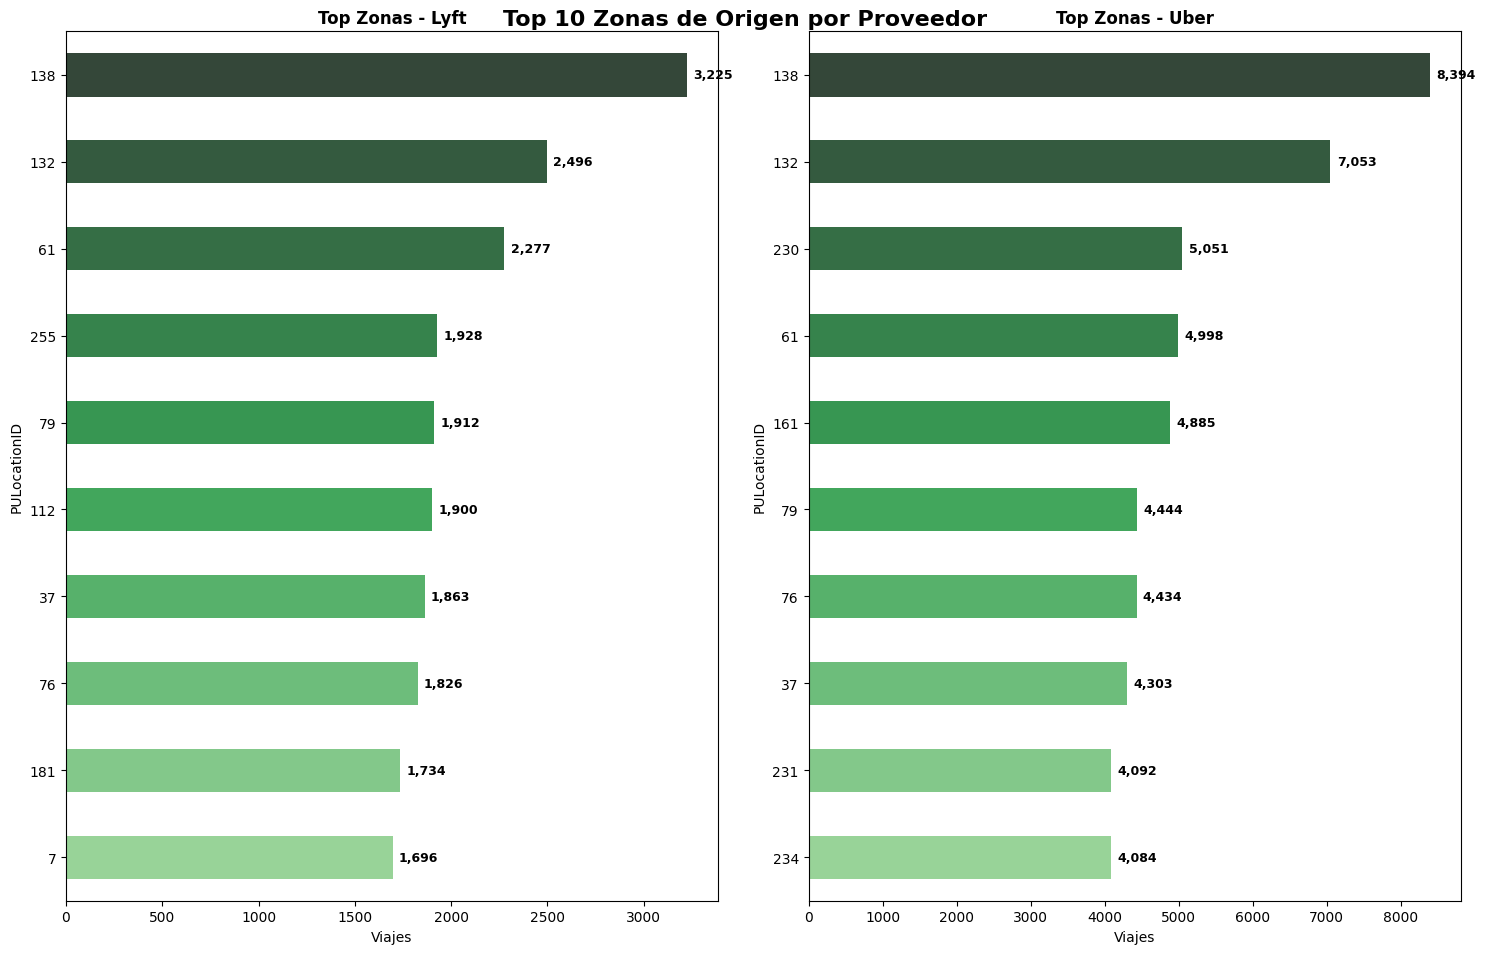

In [29]:
# Distribución geográfica por proveedor
print("\n3. DISTRIBUCIÓN GEOGRÁFICA POR PROVEEDOR:")

top_locations_by_license = {}
for license_num in df_hvfhs['hvfhs_license_num'].unique():
    license_data = df_hvfhs[df_hvfhs['hvfhs_license_num'] == license_num]
    top_locations = license_data['PULocationID'].value_counts().head(10)
    top_locations_by_license[license_num] = top_locations

# Gráfico de top zonas por proveedor
fig, axes = plt.subplots(1, 2, figsize=(15, 10))
axes = axes.flatten()

provider_names = {'HV0002': 'Juno', 'HV0003': 'Uber', 'HV0004': 'Via', 'HV0005': 'Lyft'}

for i, (license_num, top_locations) in enumerate(top_locations_by_license.items()):
    if i < len(axes):
        top_locations.sort_values(ascending=True).plot(kind='barh', ax=axes[i],
                                                     color=sns.color_palette("Greens_d", len(top_locations)))
        provider_name = provider_names.get(license_num, license_num)
        axes[i].set_title(f'Top Zonas - {provider_name}', fontweight='bold')
        axes[i].set_xlabel('Viajes')
        
        for j, v in enumerate(top_locations.sort_values(ascending=True).values):
            axes[i].text(v + top_locations.max() * 0.01, j, f'{v:,}', 
                        va='center', fontweight='bold', fontsize=9)

plt.suptitle('Top 10 Zonas de Origen por Proveedor', fontsize=16, fontweight='bold', y=0.95)
plt.tight_layout()
plt.show()

# Histogramas de Características


Generando histogramas...


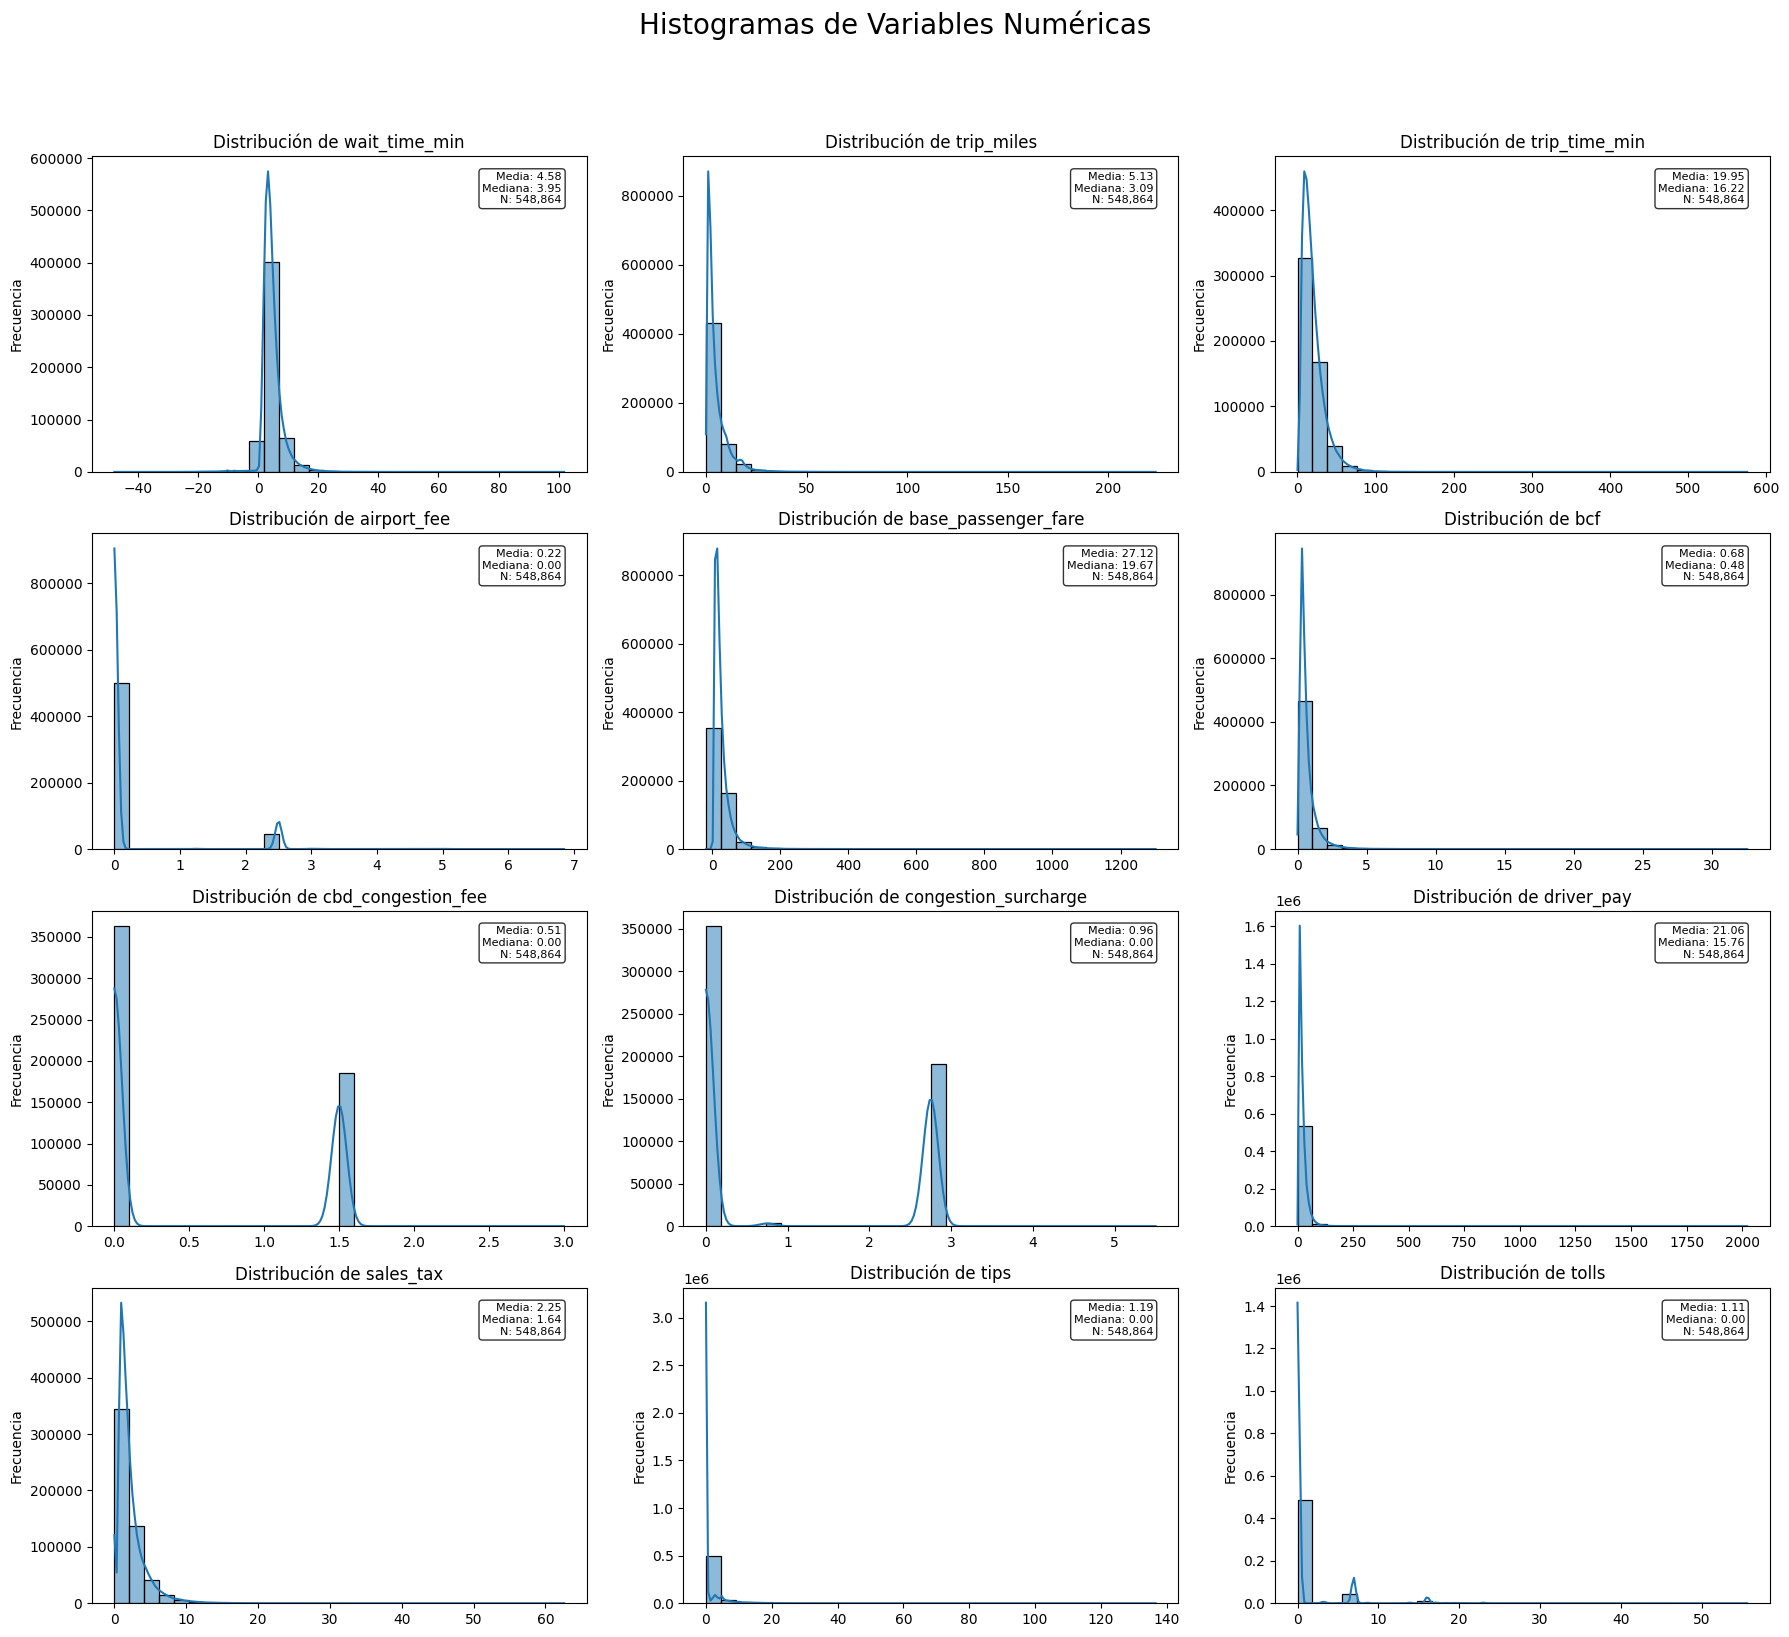

In [30]:
print("\nGenerando histogramas...")
if not df_hvfhs.select_dtypes(include=['float64']).columns.any():
    print("No se encontraron columnas numéricas para graficar.")
else:
    # Filtrar columnas que pueden ser graficadas (sin problemas de tipos nullable)
    plottable_cols = []
    for col in df_hvfhs.select_dtypes(include=['float64']).columns:
        try:
            # Convertir a float para evitar problemas con Int32 nullable
            test_data = pd.to_numeric(df_hvfhs[col], errors='coerce').dropna()
            if len(test_data) > 0:  # Solo incluir si hay datos válidos
                plottable_cols.append(col)
        except:
            continue
    
    if not plottable_cols:
        print("No se encontraron columnas numéricas válidas para graficar.")
    else:
        num_plots = len(plottable_cols)
        num_cols = 3  # Cantidad de gráficos por fila
        num_rows = (num_plots + num_cols - 1) // num_cols  # Calcular filas necesarias

        fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, num_rows * 4))
        axes = axes.flatten() # Aplanar el array de ejes para una iteración más fácil

        for i, col in enumerate(plottable_cols):
            ax = axes[i]
            # Asegurar que los datos son tipo float64 estándar para evitar errores con ufunc
            data_to_plot = pd.to_numeric(df_hvfhs[col], errors='coerce').dropna().astype('float64')  # CORREGIDO
            sns.histplot(data_to_plot, bins=30, kde=True, ax=ax)
            ax.set_title(f'Distribución de {col}')
            ax.set_xlabel('')  # Opcional: limpiar para no ser redundante con el título
            ax.set_ylabel('Frecuencia')
            
            # Agregar estadísticas básicas al gráfico
            if len(data_to_plot) > 0:
                stats_text = f'Media: {data_to_plot.mean():.2f}\nMediana: {data_to_plot.median():.2f}\nN: {len(data_to_plot):,}'
                ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
                       verticalalignment='top', horizontalalignment='right',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                       fontsize=8)
        
        # Ocultar los ejes sobrantes si el número de gráficos no es un múltiplo perfecto de num_cols
        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)
            
        plt.suptitle('Histogramas de Variables Numéricas', fontsize=20, y=1.02)
        plt.tight_layout(rect=[0, 0, 1, 0.98]) # Ajustar para el supertítulo
        plt.show()

# Histogramas and Bloxplots


Generando 26 pares de gráficos (Histograma y Boxplot)...


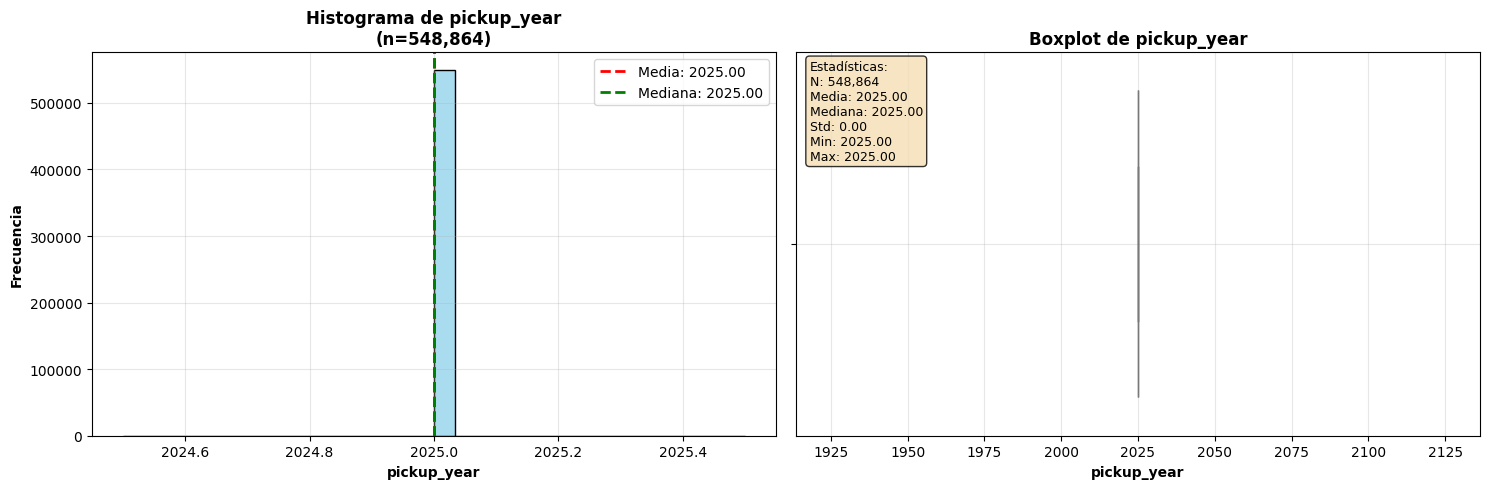

✓ pickup_year: 548,864 valores | Media: 2025.00 | Rango: [2025.00, 2025.00]


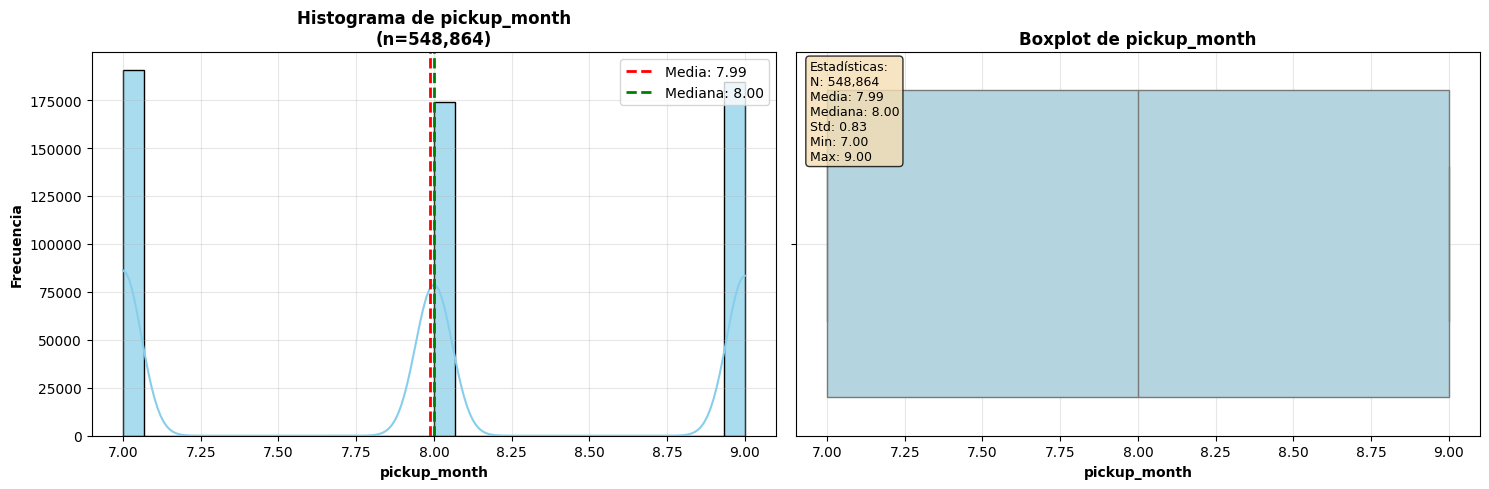

✓ pickup_month: 548,864 valores | Media: 7.99 | Rango: [7.00, 9.00]


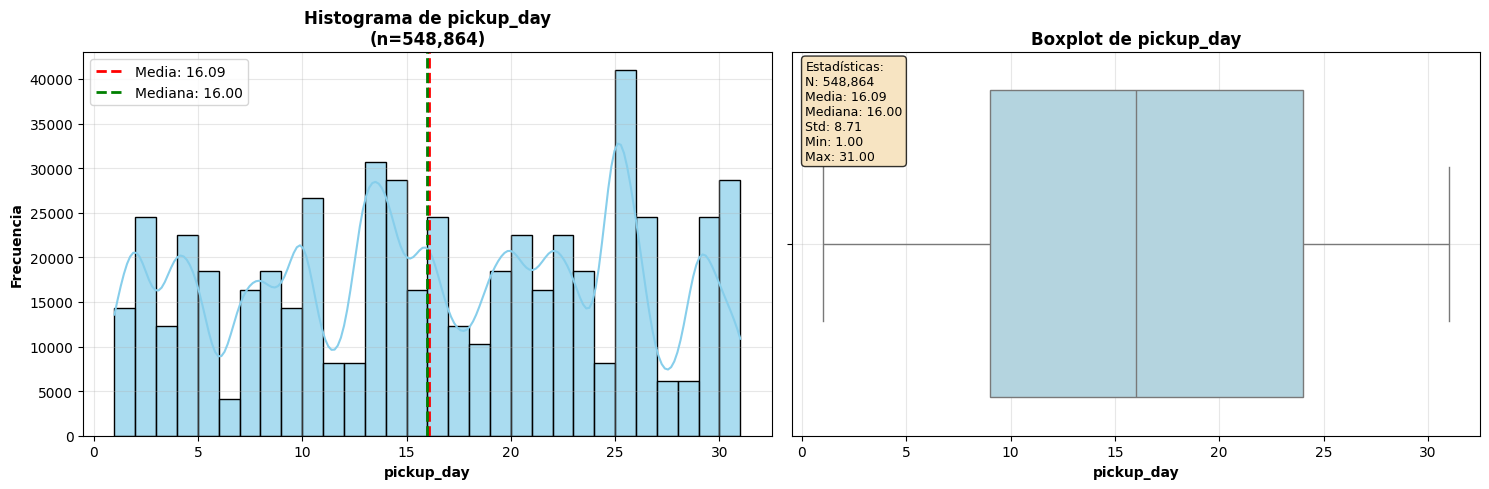

✓ pickup_day: 548,864 valores | Media: 16.09 | Rango: [1.00, 31.00]


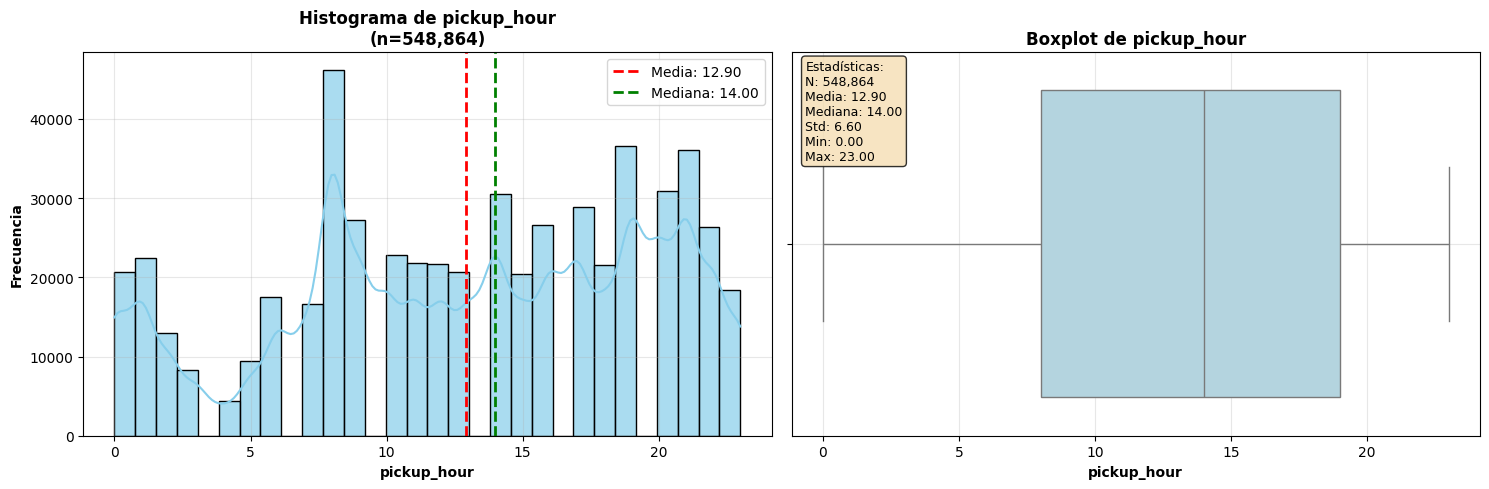

✓ pickup_hour: 548,864 valores | Media: 12.90 | Rango: [0.00, 23.00]


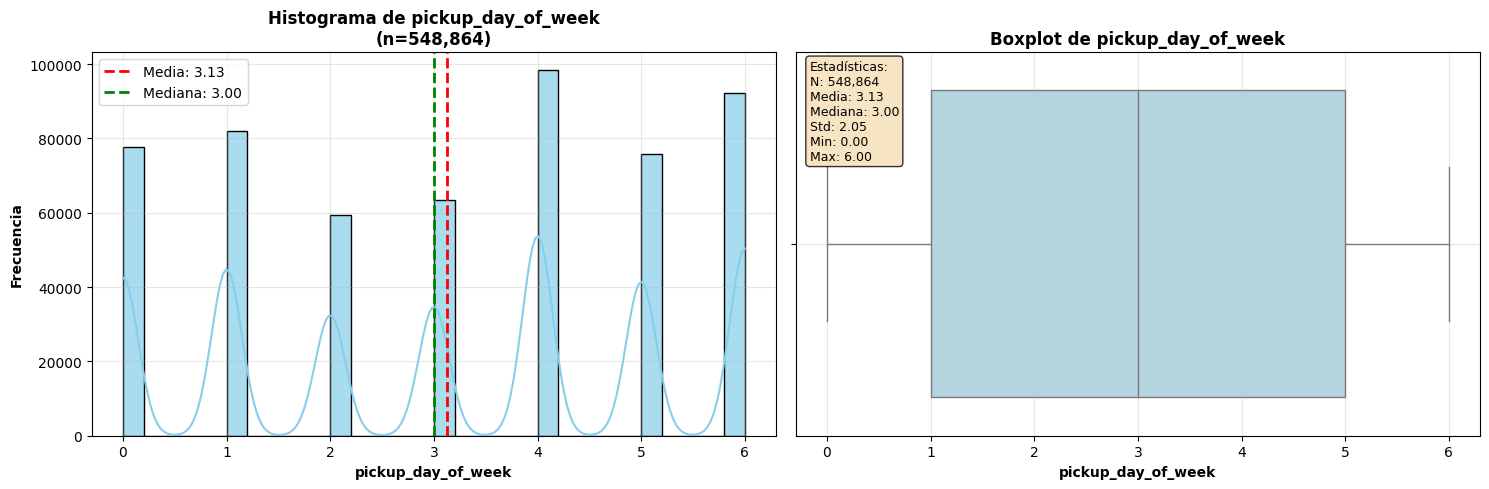

✓ pickup_day_of_week: 548,864 valores | Media: 3.13 | Rango: [0.00, 6.00]


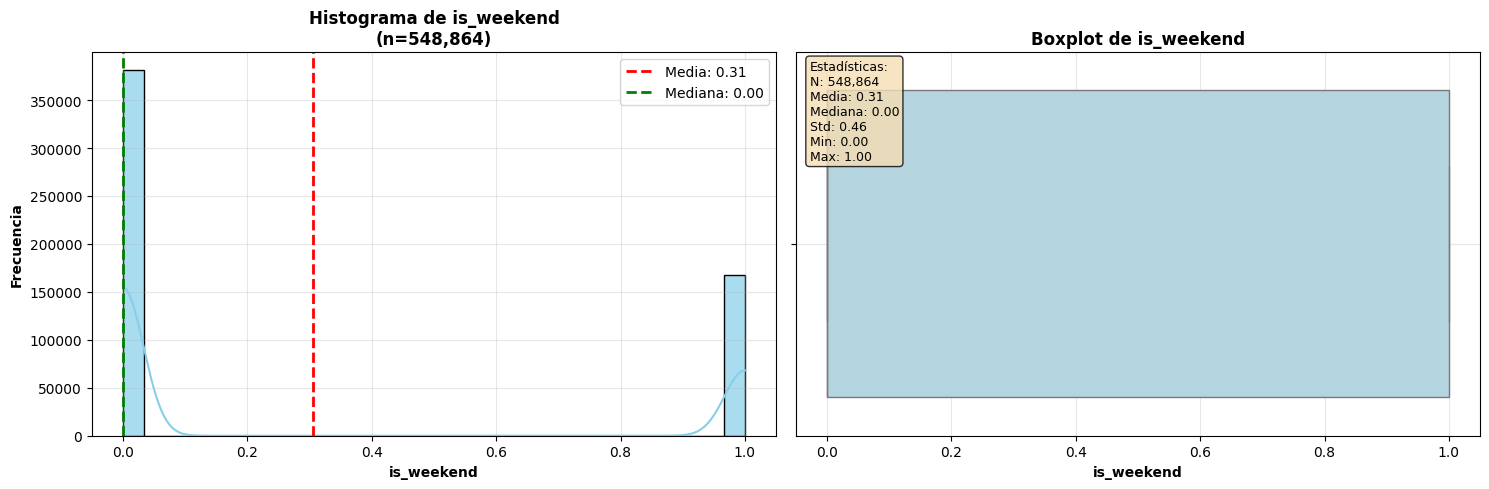

✓ is_weekend: 548,864 valores | Media: 0.31 | Rango: [0.00, 1.00]


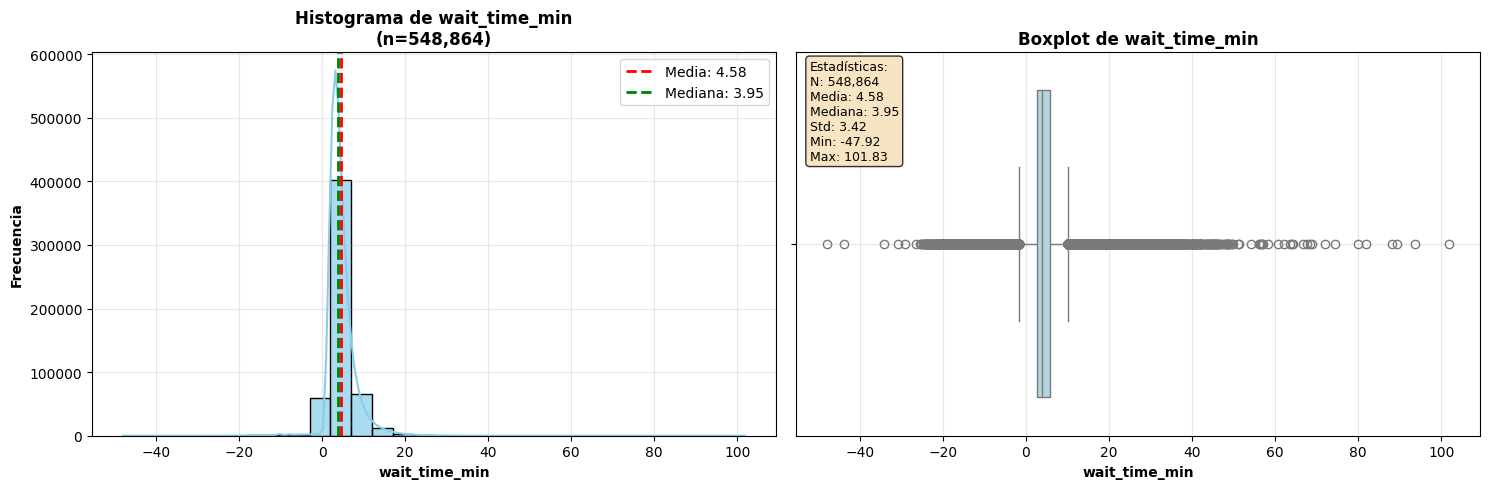

✓ wait_time_min: 548,864 valores | Media: 4.58 | Rango: [-47.92, 101.83]


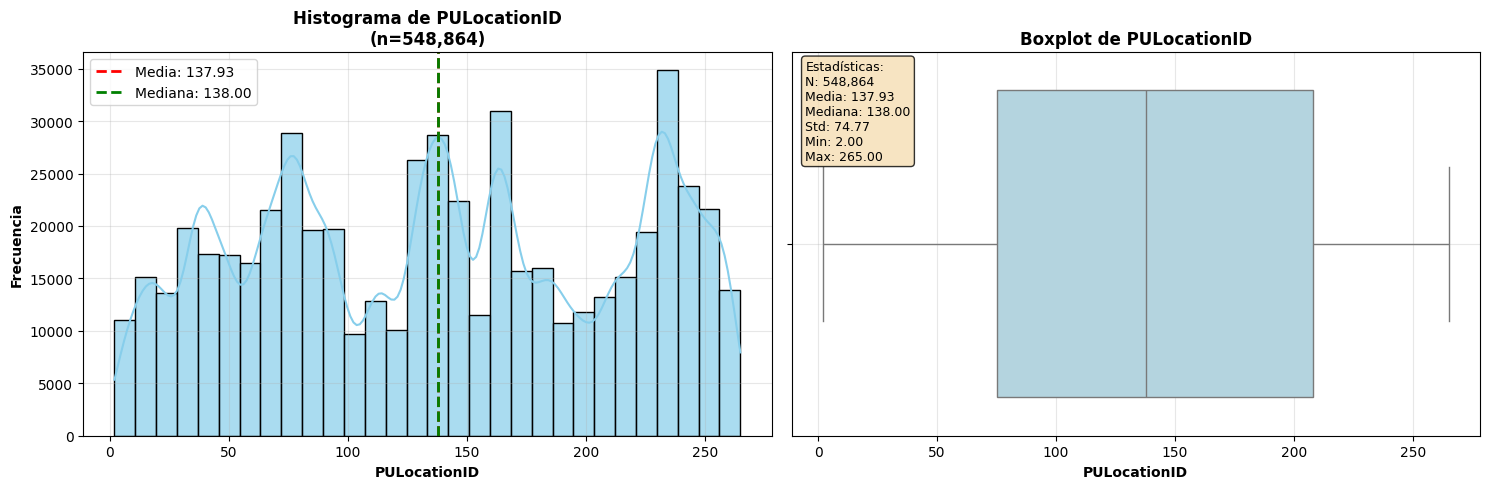

✓ PULocationID: 548,864 valores | Media: 137.93 | Rango: [2.00, 265.00]


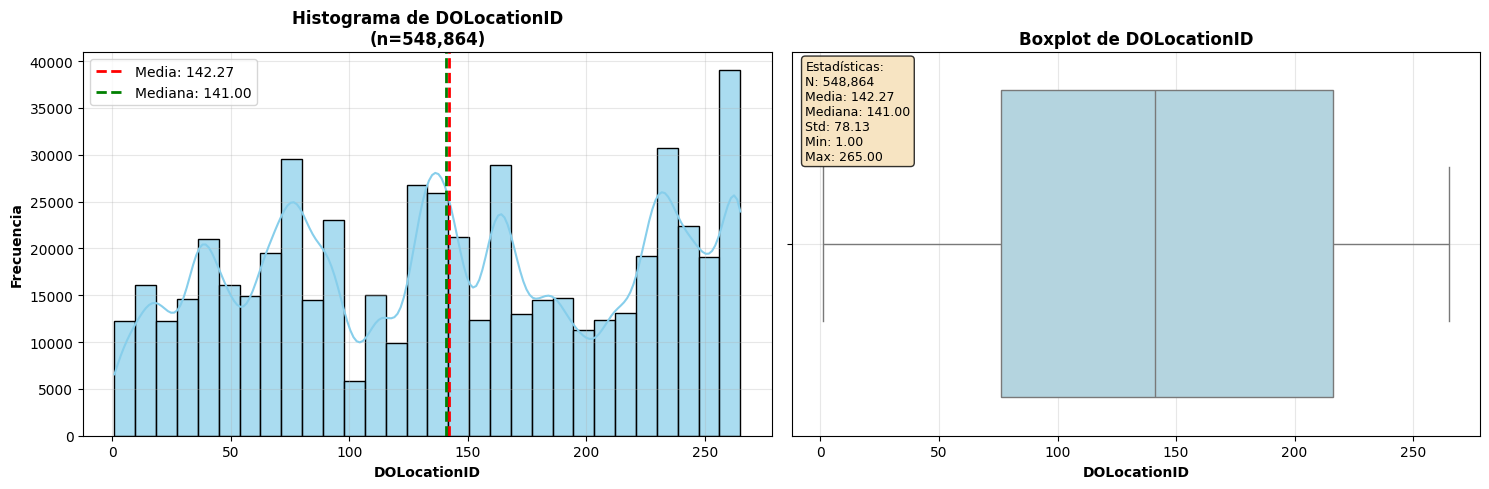

✓ DOLocationID: 548,864 valores | Media: 142.27 | Rango: [1.00, 265.00]


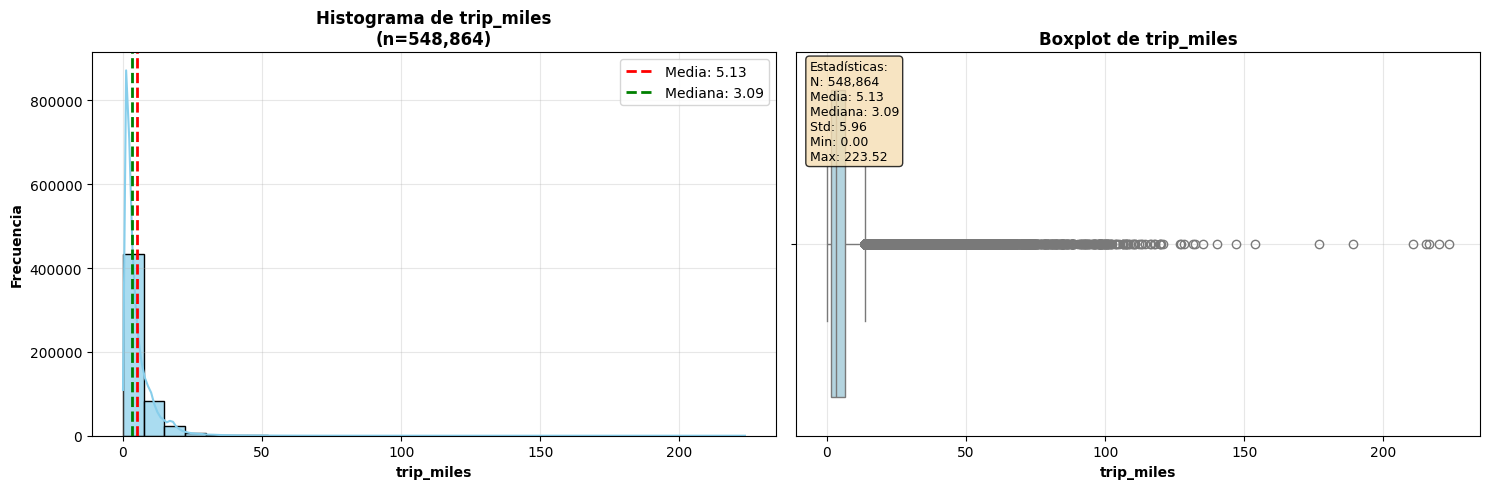

✓ trip_miles: 548,864 valores | Media: 5.13 | Rango: [0.00, 223.52]


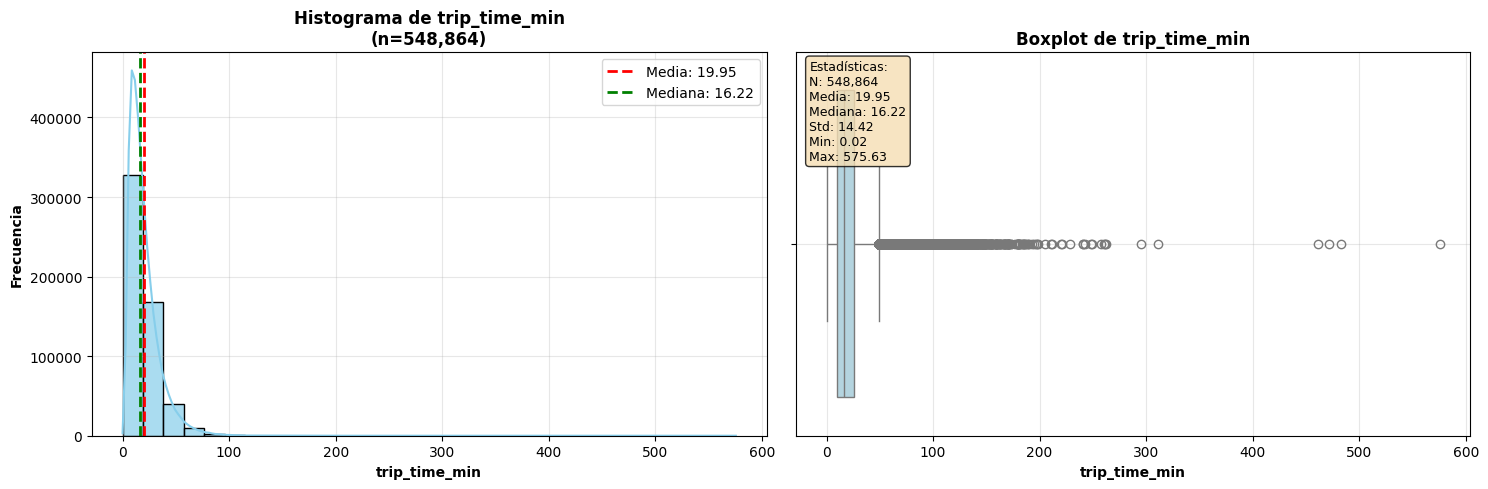

✓ trip_time_min: 548,864 valores | Media: 19.95 | Rango: [0.02, 575.63]


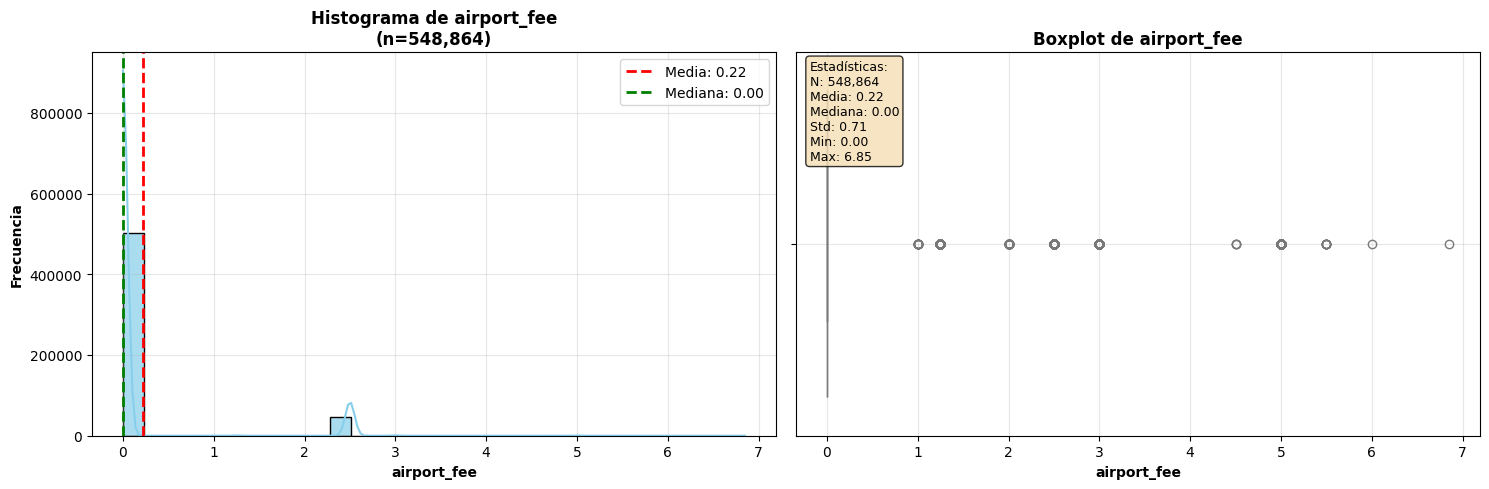

✓ airport_fee: 548,864 valores | Media: 0.22 | Rango: [0.00, 6.85]


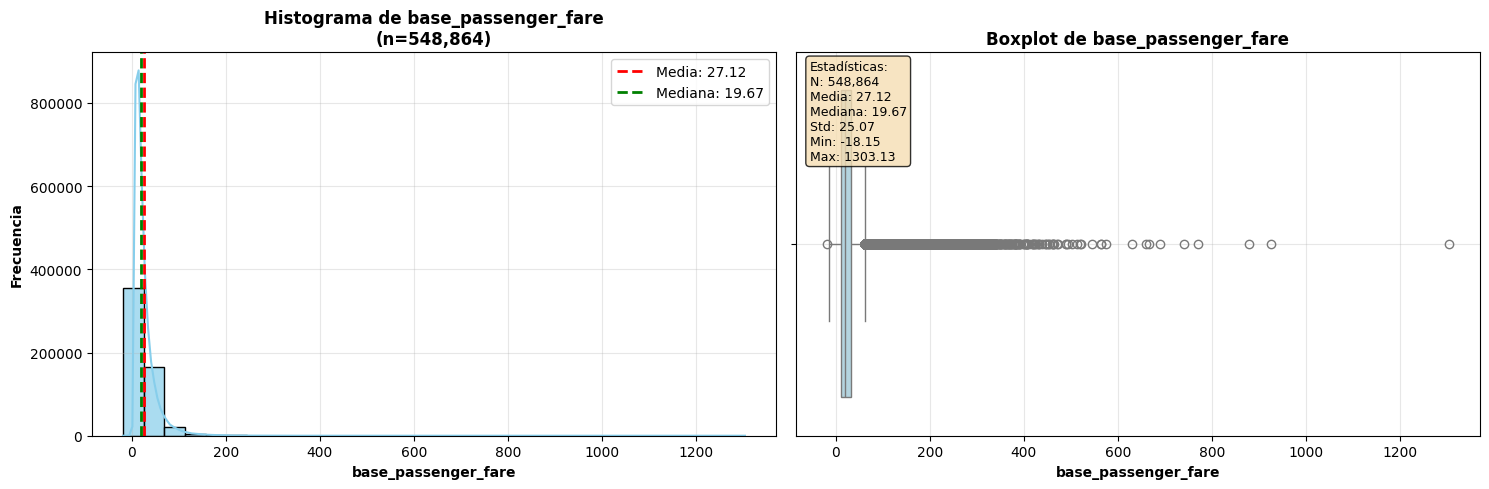

✓ base_passenger_fare: 548,864 valores | Media: 27.12 | Rango: [-18.15, 1303.13]


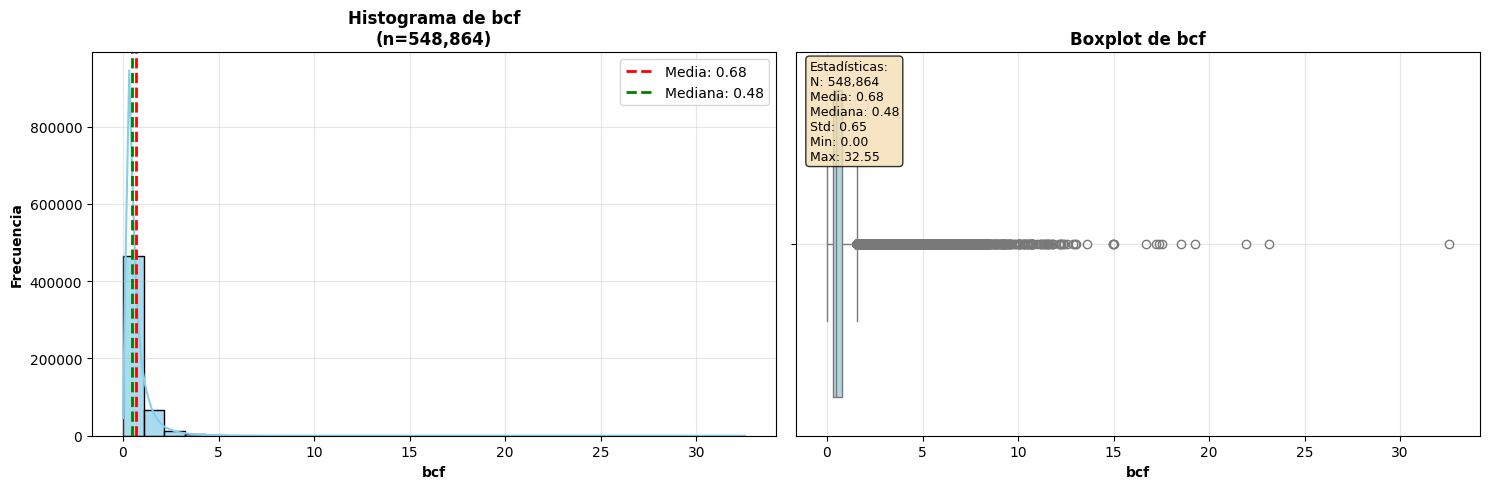

✓ bcf: 548,864 valores | Media: 0.68 | Rango: [0.00, 32.55]


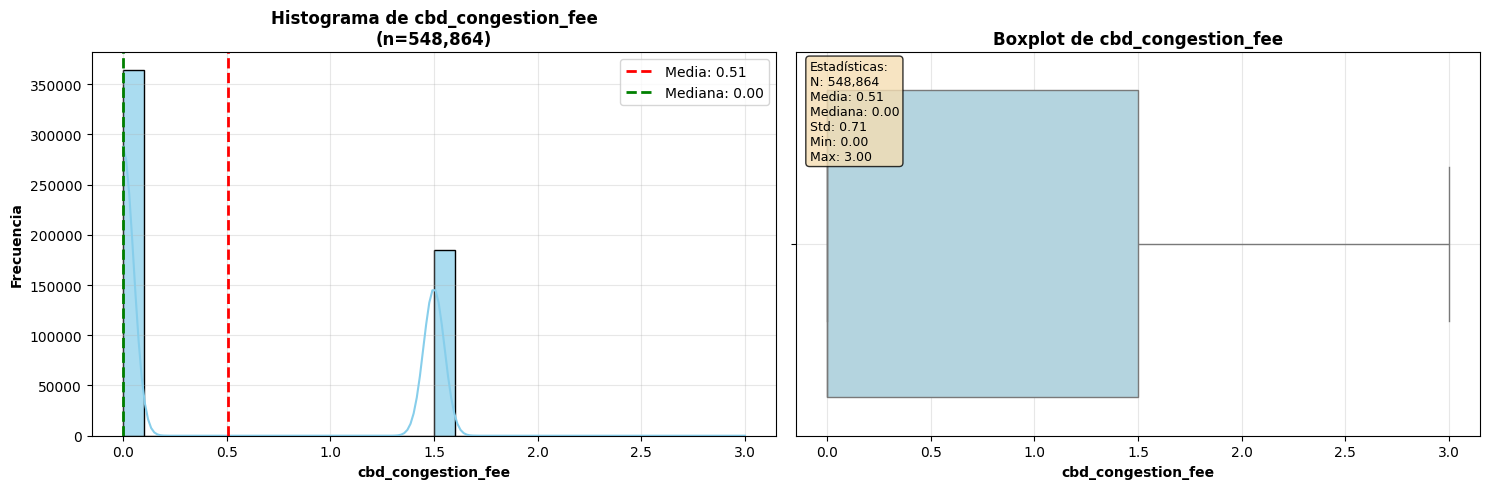

✓ cbd_congestion_fee: 548,864 valores | Media: 0.51 | Rango: [0.00, 3.00]


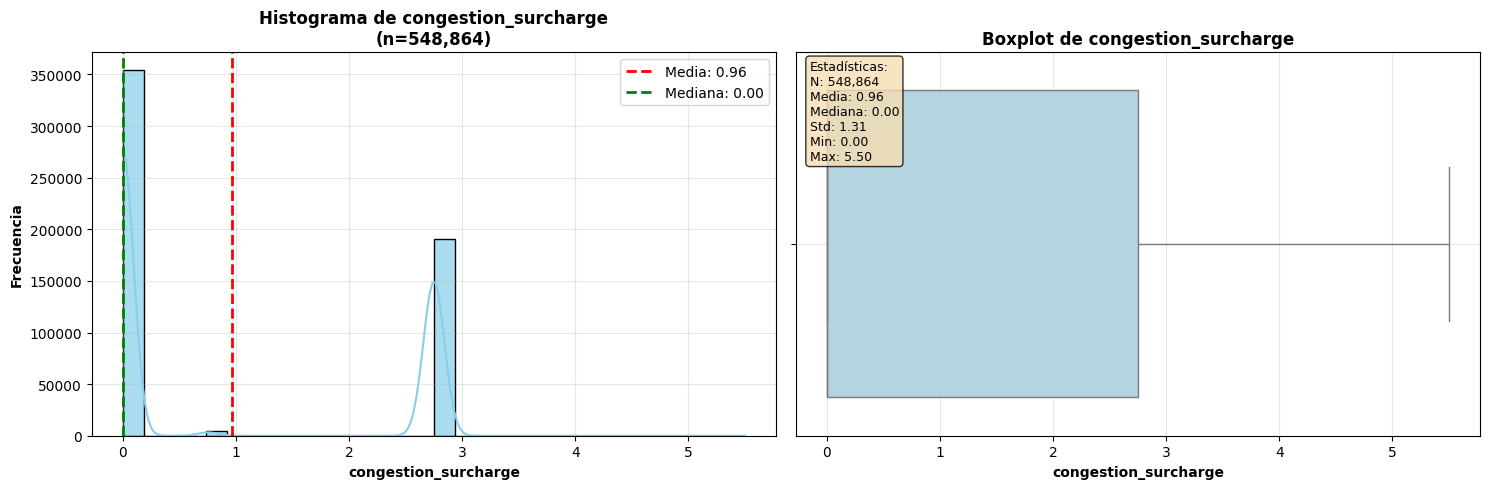

✓ congestion_surcharge: 548,864 valores | Media: 0.96 | Rango: [0.00, 5.50]


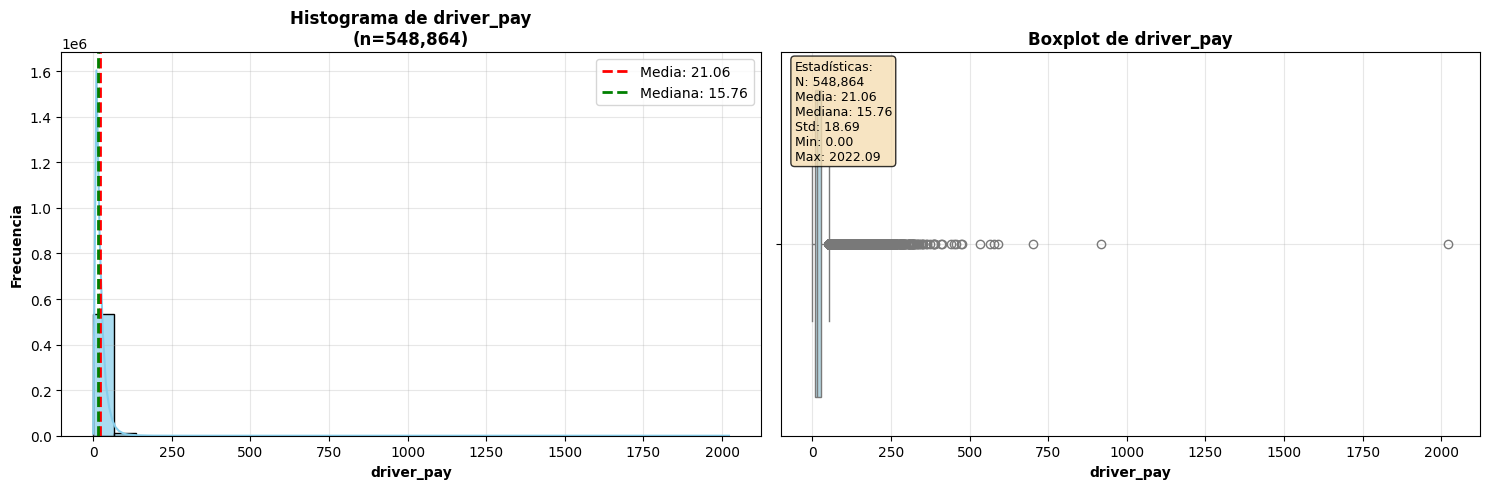

✓ driver_pay: 548,864 valores | Media: 21.06 | Rango: [0.00, 2022.09]


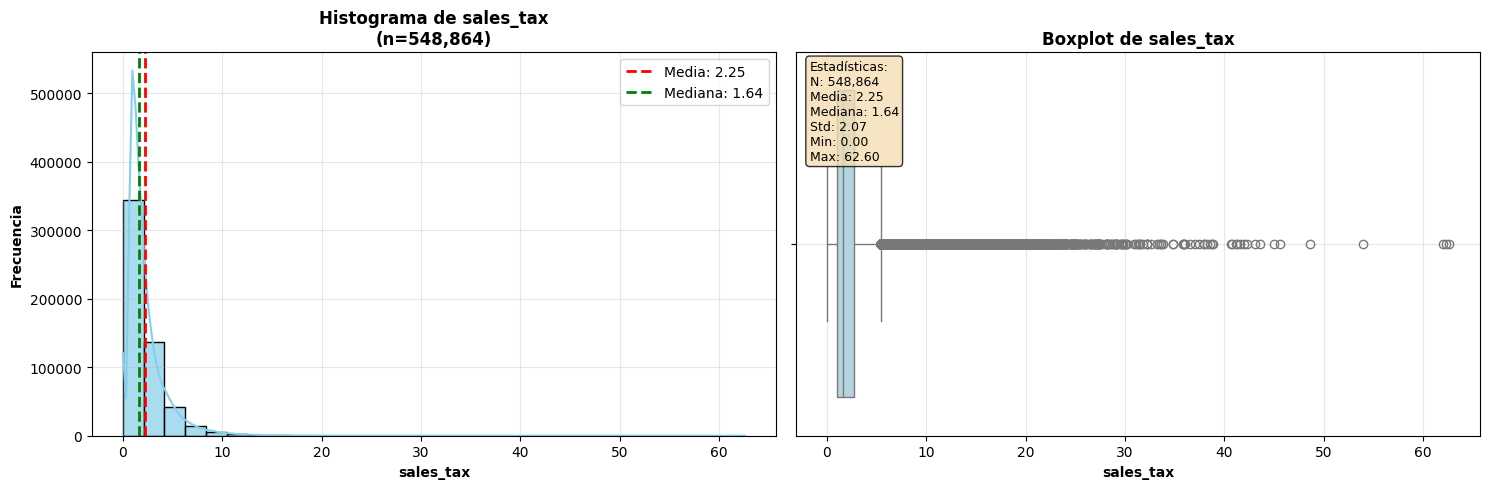

✓ sales_tax: 548,864 valores | Media: 2.25 | Rango: [0.00, 62.60]


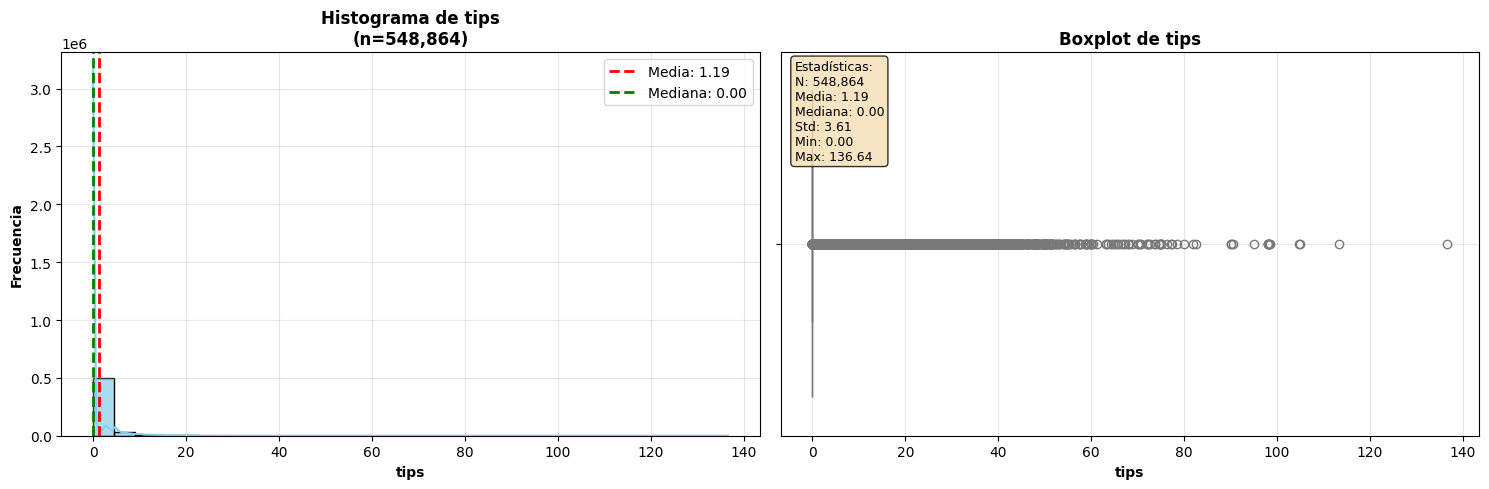

✓ tips: 548,864 valores | Media: 1.19 | Rango: [0.00, 136.64]


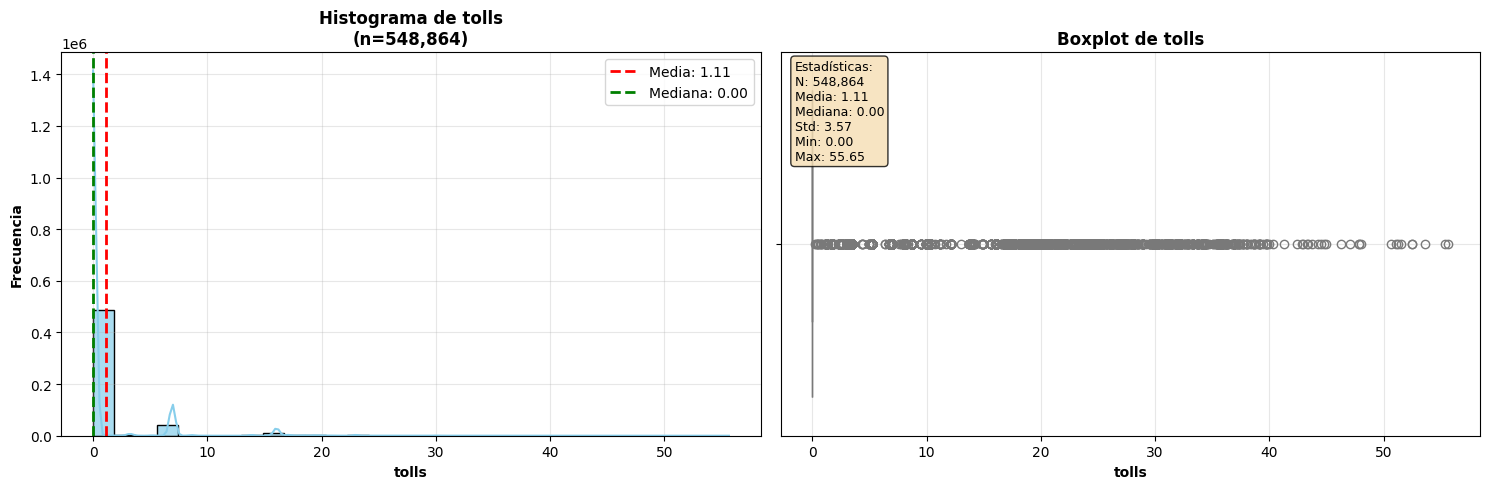

✓ tolls: 548,864 valores | Media: 1.11 | Rango: [0.00, 55.65]


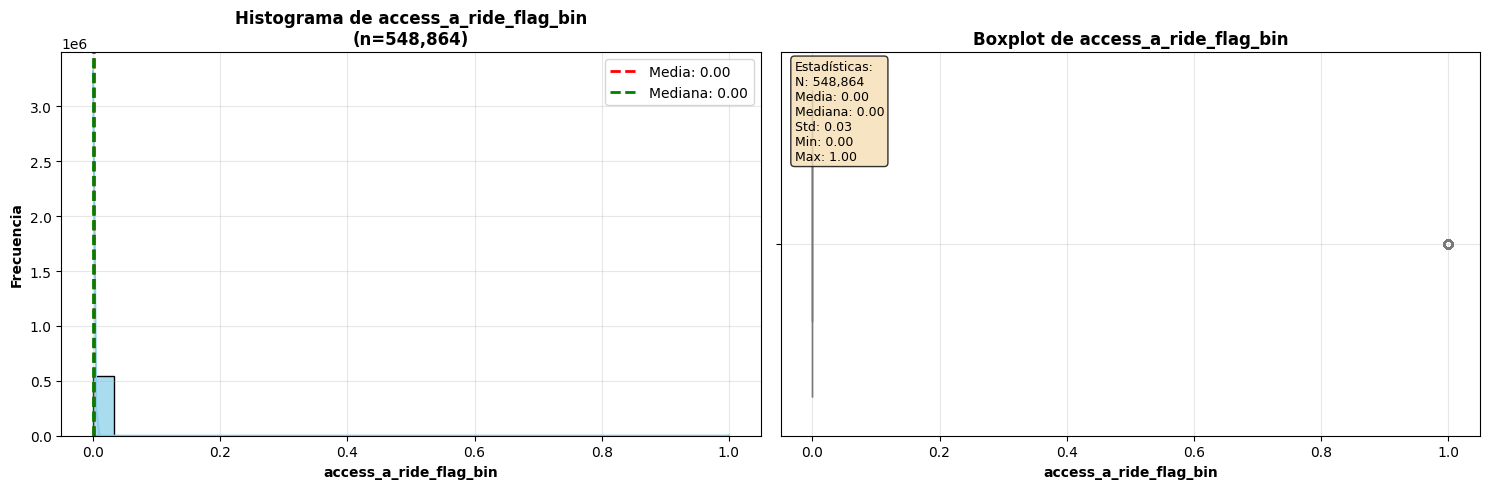

✓ access_a_ride_flag_bin: 548,864 valores | Media: 0.00 | Rango: [0.00, 1.00]


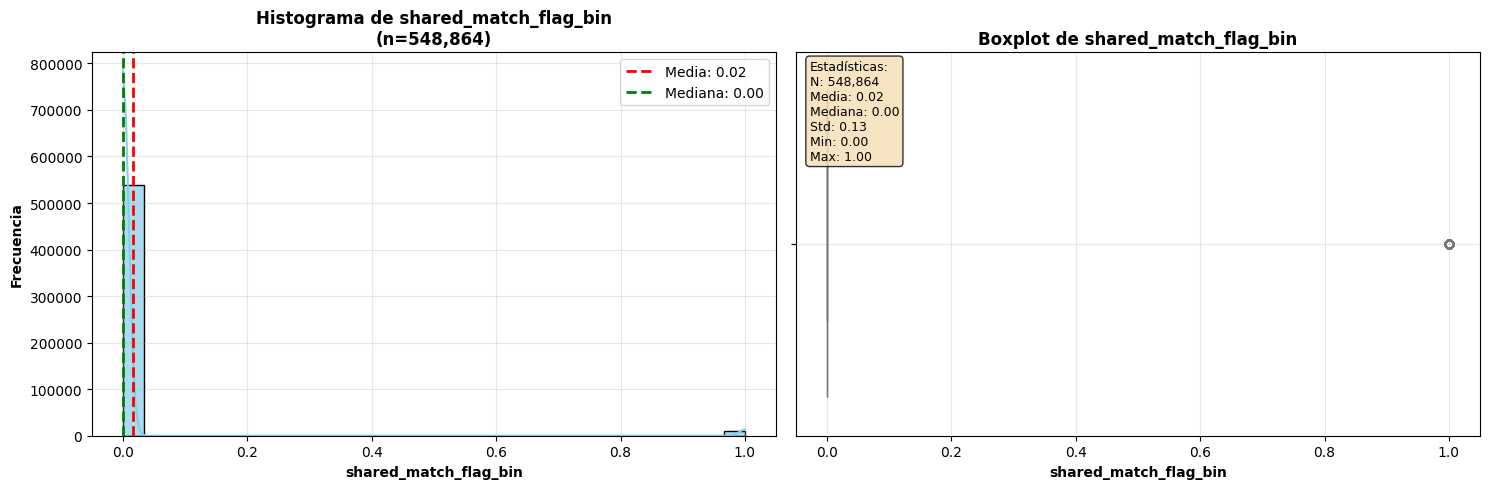

✓ shared_match_flag_bin: 548,864 valores | Media: 0.02 | Rango: [0.00, 1.00]


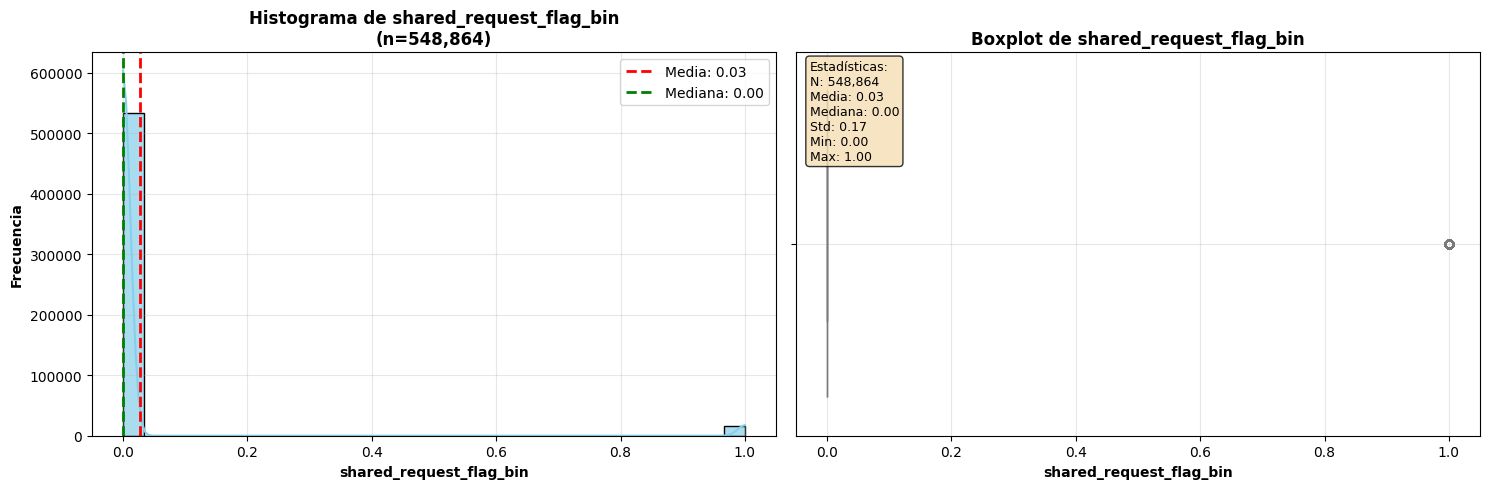

✓ shared_request_flag_bin: 548,864 valores | Media: 0.03 | Rango: [0.00, 1.00]


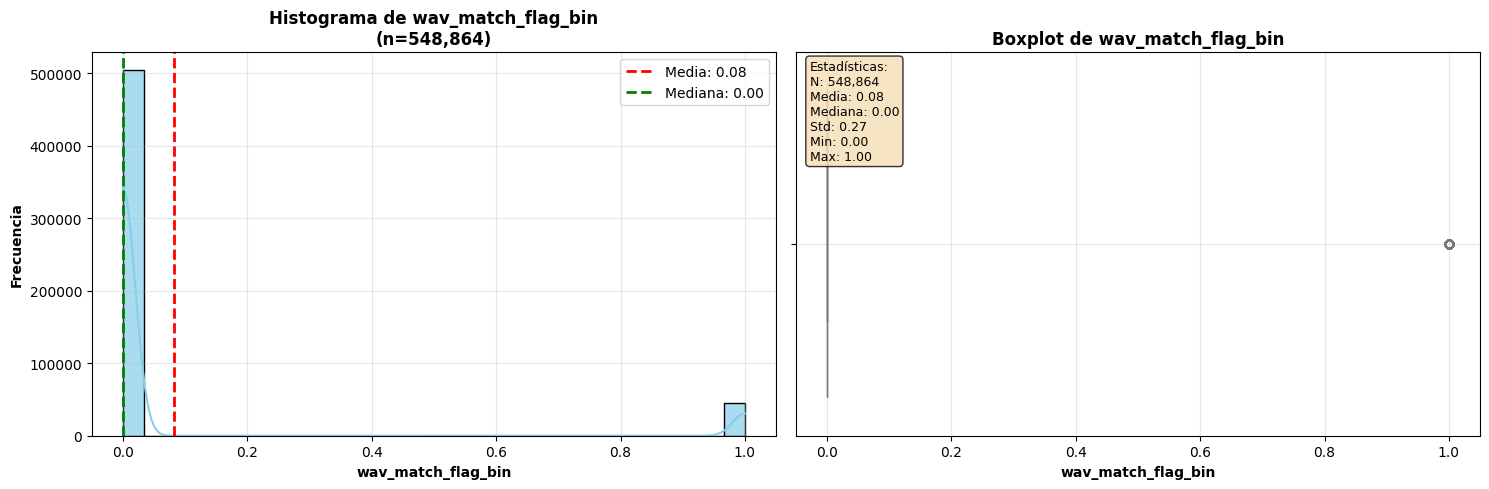

✓ wav_match_flag_bin: 548,864 valores | Media: 0.08 | Rango: [0.00, 1.00]


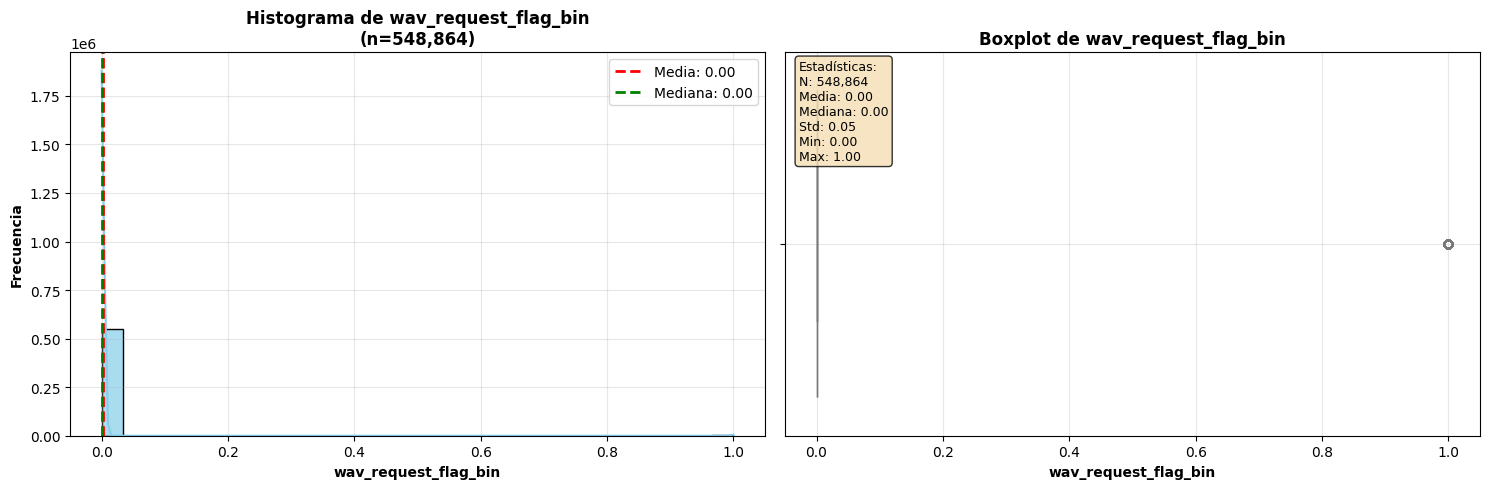

✓ wav_request_flag_bin: 548,864 valores | Media: 0.00 | Rango: [0.00, 1.00]


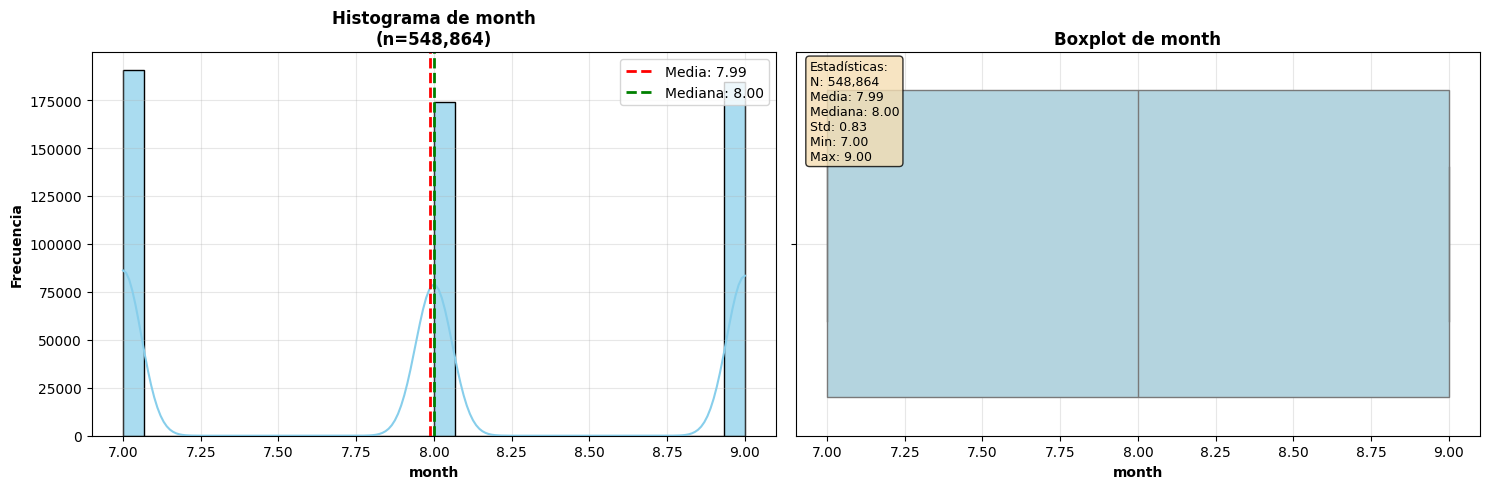

✓ month: 548,864 valores | Media: 7.99 | Rango: [7.00, 9.00]

Completado: 12 columnas procesadas exitosamente


In [31]:
print(f"\nGenerando {len(df_hvfhs.select_dtypes(include=['float64', 'int32']).columns)} pares de gráficos (Histograma y Boxplot)...")


for col in df_hvfhs.select_dtypes(include=['float64', 'int32']).columns:
    try:
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        col_data = df_hvfhs[col].dropna()

        if col_data.empty:
            # Manejar caso sin datos
            for ax in axes:
                ax.set_axis_off()
                ax.text(0.5, 0.5, f"Sin datos disponibles\npara {col}", 
                       ha="center", va="center", transform=ax.transAxes,
                       fontsize=12, style='italic')
        else:
            # Calcular estadísticas
            stats = {
                'count': len(col_data),
                'mean': col_data.mean(),
                'median': col_data.median(),
                'std': col_data.std(),
                'min': col_data.min(),
                'max': col_data.max()
            }
            
            # HISTOGRAMA
            sns.histplot(col_data, bins=30, kde=True, ax=axes[0], color='skyblue', alpha=0.7)
            axes[0].set_title(f"Histograma de {col}\n(n={stats['count']:,})", fontweight='bold', fontsize=12)
            axes[0].set_xlabel(col, fontweight='bold')
            axes[0].set_ylabel('Frecuencia', fontweight='bold')
            axes[0].grid(True, alpha=0.3)
            
            # Agregar líneas de media y mediana al histograma
            axes[0].axvline(stats['mean'], color='red', linestyle='--', linewidth=2, label=f"Media: {stats['mean']:.2f}")
            axes[0].axvline(stats['median'], color='green', linestyle='--', linewidth=2, label=f"Mediana: {stats['median']:.2f}")
            axes[0].legend()
            
            # BOXPLOT - CAMBIO DE COLOR A AZUL
            sns.boxplot(x=col_data, ax=axes[1], color='lightblue')  # Cambiado a azul
            axes[1].set_title(f"Boxplot de {col}", fontweight='bold', fontsize=12)
            axes[1].set_xlabel(col, fontweight='bold')
            axes[1].grid(True, alpha=0.3)
            
            # Agregar texto con estadísticas al boxplot
            stats_text = f"""Estadísticas:
N: {stats['count']:,}
Media: {stats['mean']:.2f}
Mediana: {stats['median']:.2f}
Std: {stats['std']:.2f}
Min: {stats['min']:.2f}
Max: {stats['max']:.2f}"""
            
            axes[1].text(0.02, 0.98, stats_text, transform=axes[1].transAxes,
                       verticalalignment='top', fontsize=9,
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

        plt.tight_layout()
        plt.show()
        
        # Mostrar resumen en consola
        if not col_data.empty:
            print(f"✓ {col}: {stats['count']:,} valores | Media: {stats['mean']:.2f} | Rango: [{stats['min']:.2f}, {stats['max']:.2f}]")
        else:
            print(f"✗ {col}: Sin datos disponibles")
            
    except Exception as e:
        print(f"Error al procesar {col}: {e}")

print(f"\nCompletado: {len([col for col in df_hvfhs.select_dtypes(include=['float64']).columns if not df_hvfhs[col].dropna().empty])} columnas procesadas exitosamente")

# Taxis (Yellows and Yellows)
### Objetivo:

Agrupar zonas de la ciudad según  
- volumen de viajes 
- hora pico
- tipo de servicio.

Identificar áreas con alta demanda o saturadas.
Optimizar la asignación de flotas y planificación de estaciones de vehículos.


### Dataset Taxis NY Yellow and Green 

In [32]:
df_taxis = taxis_sample_ordered

In [33]:
df_taxis.sample(5) 

,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,VendorID,passenger_count,trip_distance,RatecodeID,payment_type,store_and_fwd_flag,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,congestion_surcharge,cbd_congestion_fee,taxi_color,taxi_color_ini,is_color
86473,2025-07-17 15:20:22,2025-07-17 15:29:43,162,162,2,1.0,0.68,1.0,1.0,N,...,0.0,0.5,2.81,0.00,1.0,2.5,0.75,yellow,Y,1
14745,2025-07-17 12:37:46,2025-07-17 13:05:32,236,138,2,1.0,8.30,1.0,1.0,N,...,5.0,0.5,12.34,6.94,1.0,0.0,0.00,green,G,0
4496,2025-07-10 11:46:48,2025-07-10 12:01:35,229,141,2,1.0,1.54,1.0,2.0,N,...,0.0,0.5,0.00,0.00,1.0,2.5,0.75,yellow,Y,1
86747,2025-07-14 13:37:29,2025-07-14 13:47:34,75,236,6,NaN,1.36,NaN,NaN,None,...,0.0,0.5,0.00,0.00,0.3,NaN,0.00,green,G,0
86762,2025-07-08 16:16:17,2025-07-08 16:34:19,236,166,2,1.0,2.59,1.0,1.0,N,...,2.5,0.5,6.05,0.00,1.0,2.5,0.00,yellow,Y,1


### Engineering Temporal

In [34]:
# 
# A. Desglose de las fechas Pickup
df_taxis['pickup_year'] = df_taxis['pickup_datetime'].dt.year
df_taxis['pickup_month'] = df_taxis['pickup_datetime'].dt.month
df_taxis['pickup_day'] = df_taxis['pickup_datetime'].dt.day

# B. Duración del Viaje (Minutos, 2 decimales)
df_taxis['trip_duration_min'] = ((df_taxis['dropoff_datetime'] - df_taxis['pickup_datetime']).dt.total_seconds() / 60).round(2)

# C. Creación de Features de Patrón (Basadas en 'pickup_datetime')
df_taxis['pickup_hour'] = df_taxis['pickup_datetime'].dt.hour
df_taxis['pickup_day_of_week'] = df_taxis['pickup_datetime'].dt.dayofweek # 0=Lunes, 6=Domingo
df_taxis['is_weekend'] = (df_taxis['pickup_day_of_week'] >= 5).astype(int)

# D. Bandas Horarias (Time Bands) - (Usando tus nombres)
def get_time_band(hour):
    if 6 <= hour < 10: return 'AM_Peak'
    elif 10 <= hour < 16: return 'OP_day'
    elif 16 <= hour < 20: return 'PM_Peak'
    elif 20 <= hour < 24: return 'OP_night'
    else: return 'Early_Morning'

df_taxis['time_band'] = df_taxis['pickup_hour'].apply(get_time_band)

print("¡Feature Engineering Temporal completado!")

¡Feature Engineering Temporal completado!


### Reubicación de Caracteristicas Temporales

In [35]:
# Mover features de 'pickup_datetime'
loc_pickup = df_taxis.columns.get_loc('pickup_datetime')

df_taxis.insert(loc_pickup + 1, 'pickup_year', df_taxis.pop('pickup_year'))
df_taxis.insert(loc_pickup + 2, 'pickup_month', df_taxis.pop('pickup_month'))
df_taxis.insert(loc_pickup + 3, 'pickup_day', df_taxis.pop('pickup_day'))
df_taxis.insert(loc_pickup + 4, 'pickup_hour', df_taxis.pop('pickup_hour'))
df_taxis.insert(loc_pickup + 5, 'pickup_day_of_week', df_taxis.pop('pickup_day_of_week'))
df_taxis.insert(loc_pickup + 6, 'is_weekend', df_taxis.pop('is_weekend'))
df_taxis.insert(loc_pickup + 7, 'time_band', df_taxis.pop('time_band'))

# Mover feature de 'dropoff_datetime'
loc_dropoff = df_taxis.columns.get_loc('dropoff_datetime')
df_taxis.insert(loc_dropoff + 1, 'trip_duration_min', df_taxis.pop('trip_duration_min'))

print("¡Columnas re-ubicadas exitosamente!")

¡Columnas re-ubicadas exitosamente!


### Datos duplicados del dataset

In [36]:
df_taxis.describe(include='all').T.duplicated()

pickup_datetime          False
pickup_year              False
pickup_month             False
pickup_day               False
pickup_hour              False
pickup_day_of_week       False
is_weekend               False
time_band                False
dropoff_datetime         False
trip_duration_min        False
PULocationID             False
DOLocationID             False
VendorID                 False
passenger_count          False
trip_distance            False
RatecodeID               False
payment_type             False
store_and_fwd_flag       False
trip_type                False
fare_amount              False
total_amount             False
extra                    False
mta_tax                  False
tip_amount               False
tolls_amount             False
improvement_surcharge    False
congestion_surcharge     False
cbd_congestion_fee       False
taxi_color               False
taxi_color_ini           False
is_color                 False
dtype: bool

### Porcentaje de valores nulos por columna 

In [37]:
# Porcentaje de valores nulos por columna 
missing_values = df_taxis.isnull().sum()/len(df_taxis)
missing_values = ((missing_values[missing_values > 0].round(3).sort_values(ascending=False)*100).round(2))
missing_values

trip_type               55.4
passenger_count         18.7
RatecodeID              18.7
store_and_fwd_flag      18.7
congestion_surcharge    18.7
payment_type             5.4
dtype: float64

# Heatmap de valores nulos

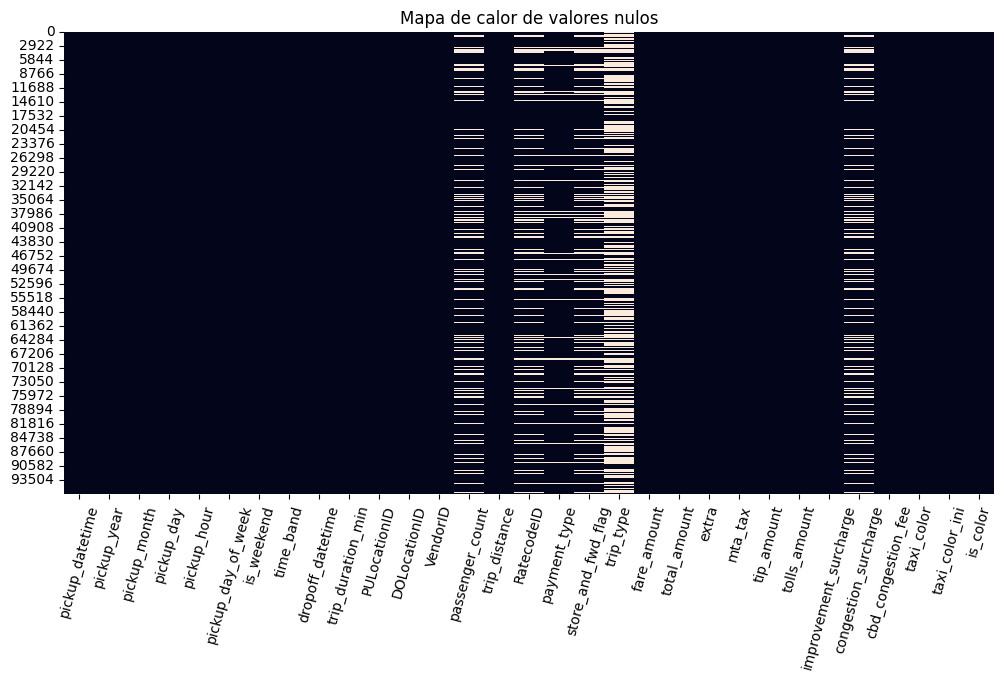

In [38]:
# Mapa de calor de valores nulos
plt.figure(figsize=(12, 6))
sns.heatmap(df_taxis.isnull(), cbar=False)
plt.title("Mapa de calor de valores nulos")
ax = plt.gca()
ax.tick_params(axis='x', rotation=75)

# Distribución de Taxis Yellow and Green

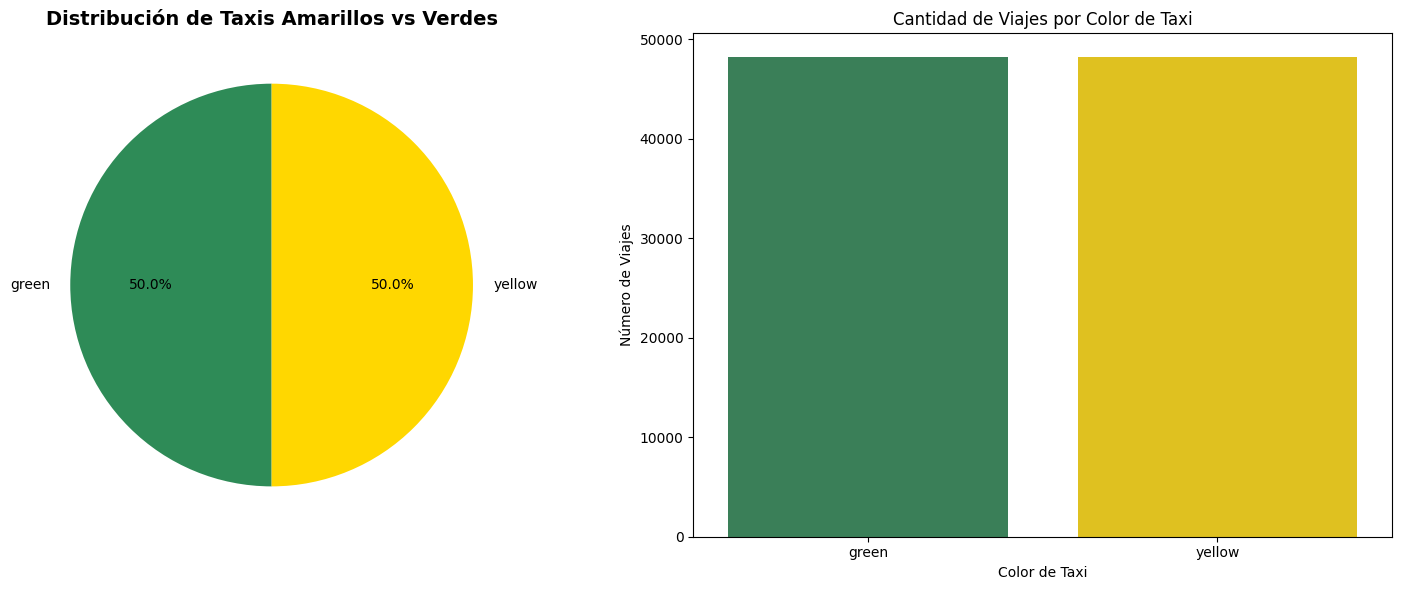

taxi_color
green     48205
yellow    48205
Name: count, dtype: int64


In [39]:
# 1. ANÁLISIS PRELIMINAR - DISTRIBUCIÓN DE TAXIS
distribucion_taxis = df_taxis['taxi_color'].value_counts()
# Gráfico de distribución general
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# Pie chart - Distribución general
colors_pie = [ '#2E8B57', '#FFD700']  # Verde y amarillo
ax1.pie(distribucion_taxis.values, labels=distribucion_taxis.index, autopct='%1.1f%%', colors=colors_pie, startangle=90)
ax1.set_title('Distribución de Taxis Amarillos vs Verdes', fontsize=14, fontweight='bold')

# Barplot - Conteo por color
sns.barplot(x=distribucion_taxis.index, y=distribucion_taxis.values, ax=ax2, palette=colors_pie)
ax2.set_title('Cantidad de Viajes por Color de Taxi')
ax2.set_ylabel('Número de Viajes')
ax2.set_xlabel('Color de Taxi')

plt.tight_layout()
plt.show()

print(distribucion_taxis)

# Top 10 zonas con más viajes Pickup and Dropoff

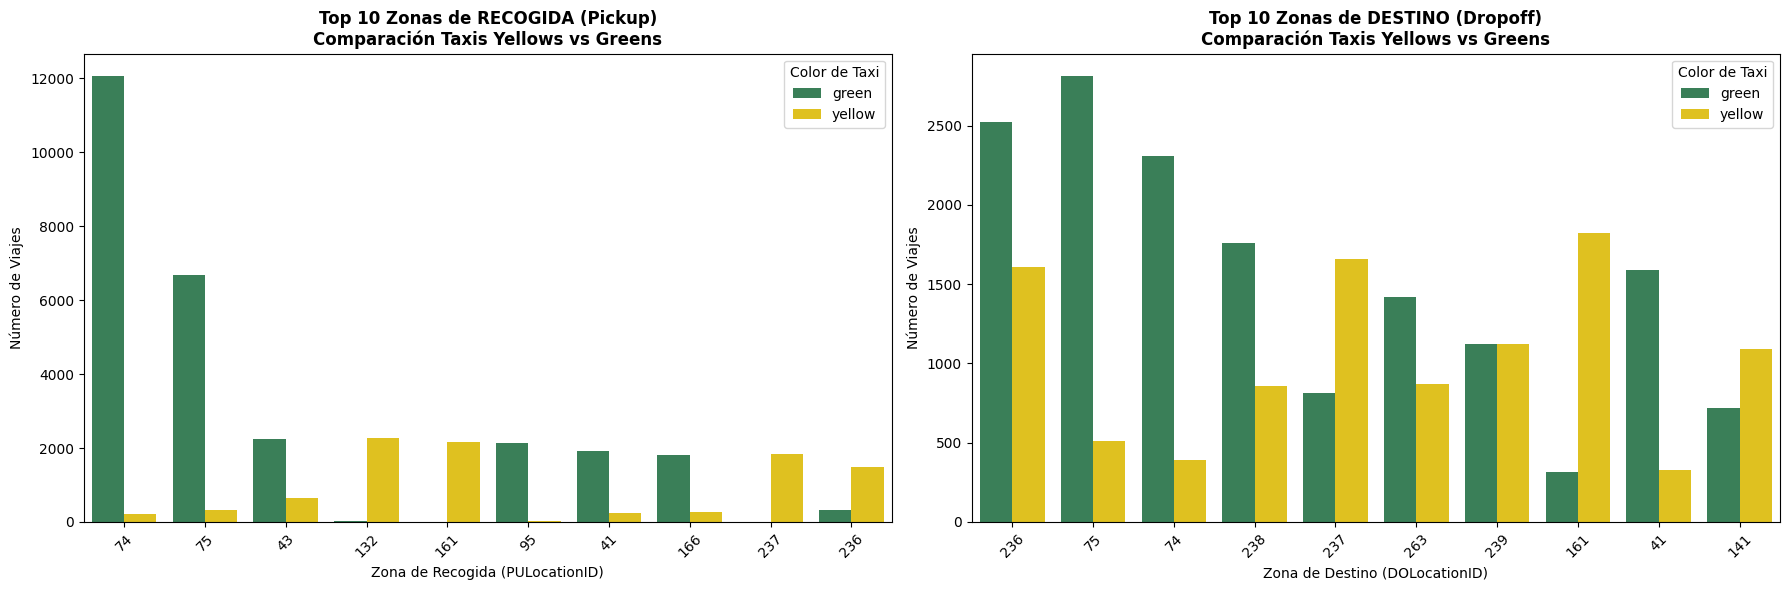

In [40]:
# Top 10 zonas con más viajes tanto para pickup como dropoff
top_pu_zones = df_taxis['PULocationID'].value_counts().head(10).index
top_do_zones = df_taxis['DOLocationID'].value_counts().head(10).index

# Combinar ambos tops para tener un conjunto único de zonas importantes
all_top_zones = set(top_pu_zones).union(set(top_do_zones))

# Filtrar datos para las zonas top
df_top_pu = df_taxis[df_taxis['PULocationID'].isin(all_top_zones)]
df_top_do = df_taxis[df_taxis['DOLocationID'].isin(all_top_zones)]

# Crear subplots para comparación lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico de zonas de recogida (Pickup)
sns.countplot(data=df_top_pu, x='PULocationID', hue='taxi_color', 
              ax=ax1, palette=colors_pie, order=top_pu_zones)
ax1.set_title('Top 10 Zonas de RECOGIDA (Pickup)\nComparación Taxis Yellows vs Greens', 
              fontweight='bold', fontsize=12)
ax1.set_xlabel('Zona de Recogida (PULocationID)')
ax1.set_ylabel('Número de Viajes')
ax1.legend(title='Color de Taxi')
ax1.tick_params(axis='x', rotation=45)

# Gráfico de zonas de destino (Dropoff)
sns.countplot(data=df_top_do, x='DOLocationID', hue='taxi_color', 
              ax=ax2, palette=colors_pie, order=top_do_zones)
ax2.set_title('Top 10 Zonas de DESTINO (Dropoff)\nComparación Taxis Yellows vs Greens', 
              fontweight='bold', fontsize=12)
ax2.set_xlabel('Zona de Destino (DOLocationID)')
ax2.set_ylabel('Número de Viajes')
ax2.legend(title='Color de Taxi')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Distribución de viajes por hora del día Pickup and Dropoff

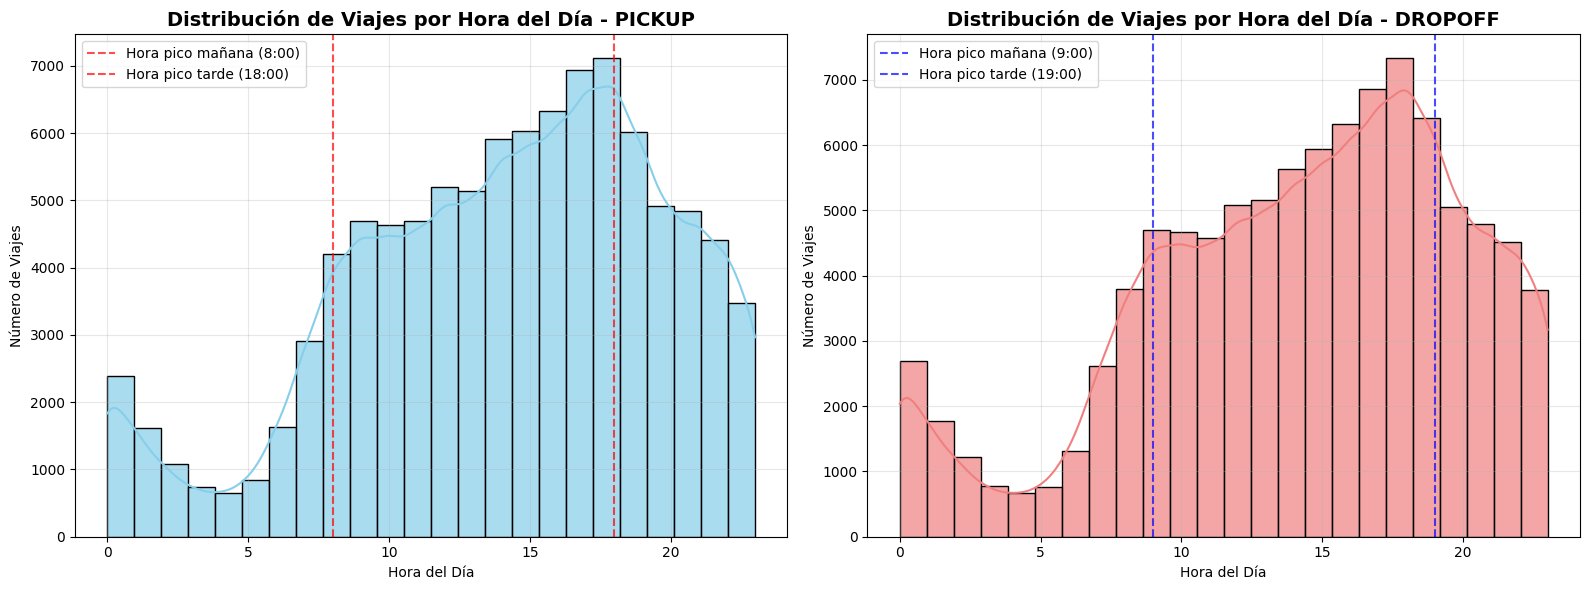

In [41]:
# Distribución de viajes por hora pico - Pickup vs Dropoff
plt.figure(figsize=(16, 6))

# 1. Distribución de viajes por hora del día - PICKUP
plt.subplot(1, 2, 1)
sns.histplot(data=df_taxis, x='pickup_hour', bins=24, kde=True, color='skyblue', alpha=0.7)
plt.title('Distribución de Viajes por Hora del Día - PICKUP', fontsize=14, fontweight='bold')
plt.xlabel('Hora del Día')
plt.ylabel('Número de Viajes')
plt.axvline(x=8, color='red', linestyle='--', alpha=0.7, label='Hora pico mañana (8:00)')
plt.axvline(x=18, color='red', linestyle='--', alpha=0.7, label='Hora pico tarde (18:00)')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Distribución de viajes por hora del día - DROPOFF
plt.subplot(1, 2, 2)
df_taxis['dropoff_hour'] = df_taxis['dropoff_datetime'].dt.hour
sns.histplot(data=df_taxis, x='dropoff_hour', bins=24, kde=True, color='lightcoral', alpha=0.7)
plt.title('Distribución de Viajes por Hora del Día - DROPOFF', fontsize=14, fontweight='bold')
plt.xlabel('Hora del Día')
plt.ylabel('Número de Viajes')
plt.axvline(x=9, color='blue', linestyle='--', alpha=0.7, label='Hora pico mañana (9:00)')
plt.axvline(x=19, color='blue', linestyle='--', alpha=0.7, label='Hora pico tarde (19:00)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Top zonas por Pickup y Dropoff en bandas pico

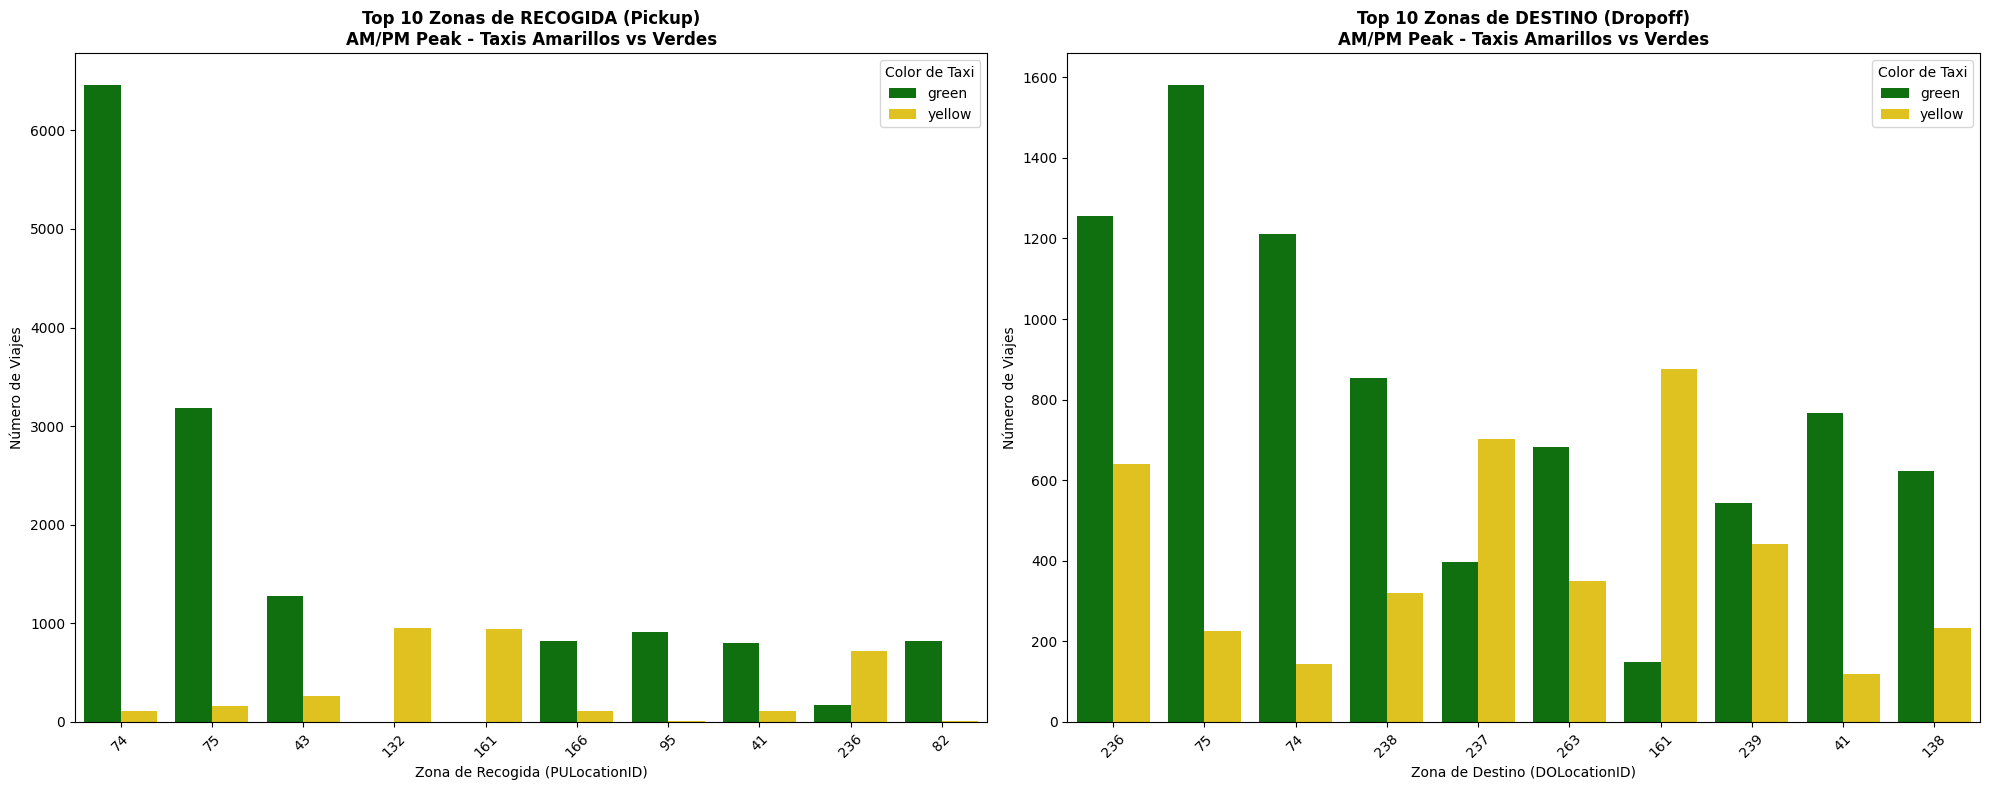

In [42]:
# Aplicar bandas horarias
df_taxis['pickup_band'] = df_taxis['pickup_hour'].apply(get_time_band)
df_taxis['dropoff_band'] = df_taxis['dropoff_hour'].apply(get_time_band)

# Filtrar solo AM_Peak y PM_Peak
df_peak = df_taxis[
    (df_taxis['pickup_band'].isin(['AM_Peak', 'PM_Peak'])) |
    (df_taxis['dropoff_band'].isin(['AM_Peak', 'PM_Peak']))
]

# Top zonas por pickup y dropoff en bandas pico
top_pu_zones = df_peak['PULocationID'].value_counts().head(10).index
top_do_zones = df_peak['DOLocationID'].value_counts().head(10).index
all_top_zones = set(top_pu_zones).union(set(top_do_zones))

# Filtrar datos
df_top_pu = df_peak[df_peak['PULocationID'].isin(all_top_zones)]
df_top_do = df_peak[df_peak['DOLocationID'].isin(all_top_zones)]

# Crear figura con dos subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Definir paleta de colores
colors_pie = {'yellow': 'gold', 'green': 'green'}

# Pickup
sns.countplot(data=df_top_pu, x='PULocationID', hue='taxi_color',
              ax=ax1, palette=colors_pie, order=top_pu_zones)
ax1.set_title('Top 10 Zonas de RECOGIDA (Pickup)\nAM/PM Peak - Taxis Amarillos vs Verdes',
              fontweight='bold', fontsize=12)
ax1.set_xlabel('Zona de Recogida (PULocationID)')
ax1.set_ylabel('Número de Viajes')
ax1.legend(title='Color de Taxi')
ax1.tick_params(axis='x', rotation=45)

# Dropoff
sns.countplot(data=df_top_do, x='DOLocationID', hue='taxi_color',
              ax=ax2, palette=colors_pie, order=top_do_zones)
ax2.set_title('Top 10 Zonas de DESTINO (Dropoff)\nAM/PM Peak - Taxis Amarillos vs Verdes',
              fontweight='bold', fontsize=12)
ax2.set_xlabel('Zona de Destino (DOLocationID)')
ax2.set_ylabel('Número de Viajes')
ax2.legend(title='Color de Taxi')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Patrón Horario demanda


Patrón Horario demanda


Text(0, 0.5, 'Viajes por Hora')

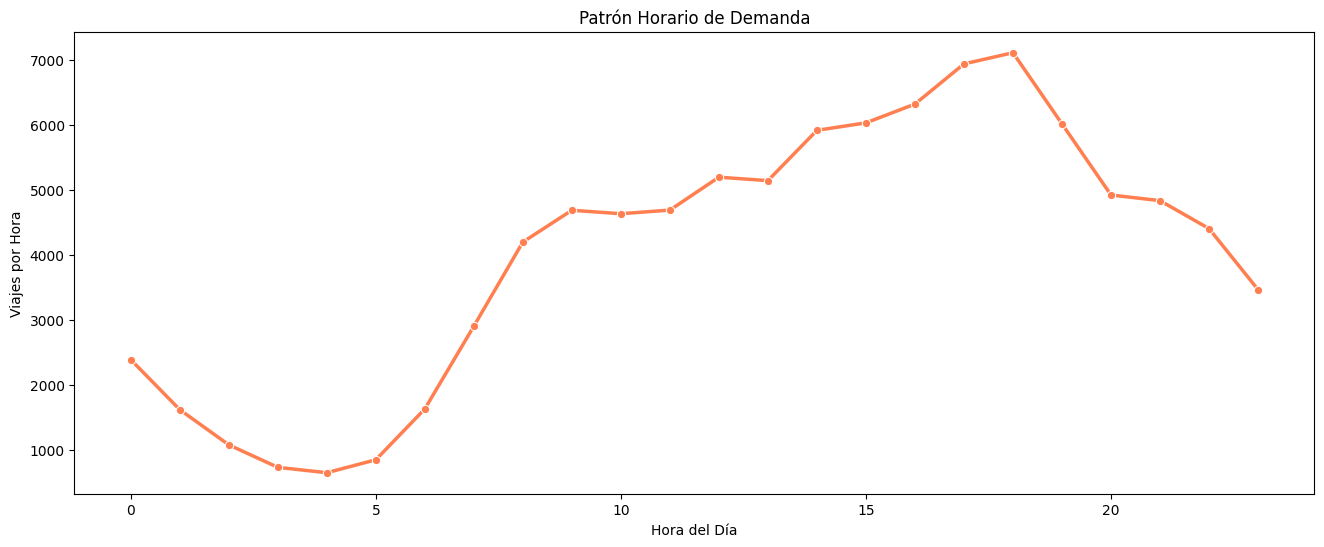

In [43]:
# Patrón Horario demanda
print("\nPatrón Horario demanda")
# Crear figura con subplots
plt.figure(figsize=(16, 6)) 

# Agrupar por bandas horarias
hourly_pattern = df_taxis.groupby('pickup_hour').size().reset_index(name='count')
sns.lineplot(data=hourly_pattern, x='pickup_hour', y='count', 
             marker='o', color='coral', linewidth=2.5)
plt.title('Patrón Horario de Demanda')
plt.xlabel('Hora del Día')
plt.ylabel('Viajes por Hora')

# Tendencia de viajes por hora del día


# Tendencia de viajes por hora del día


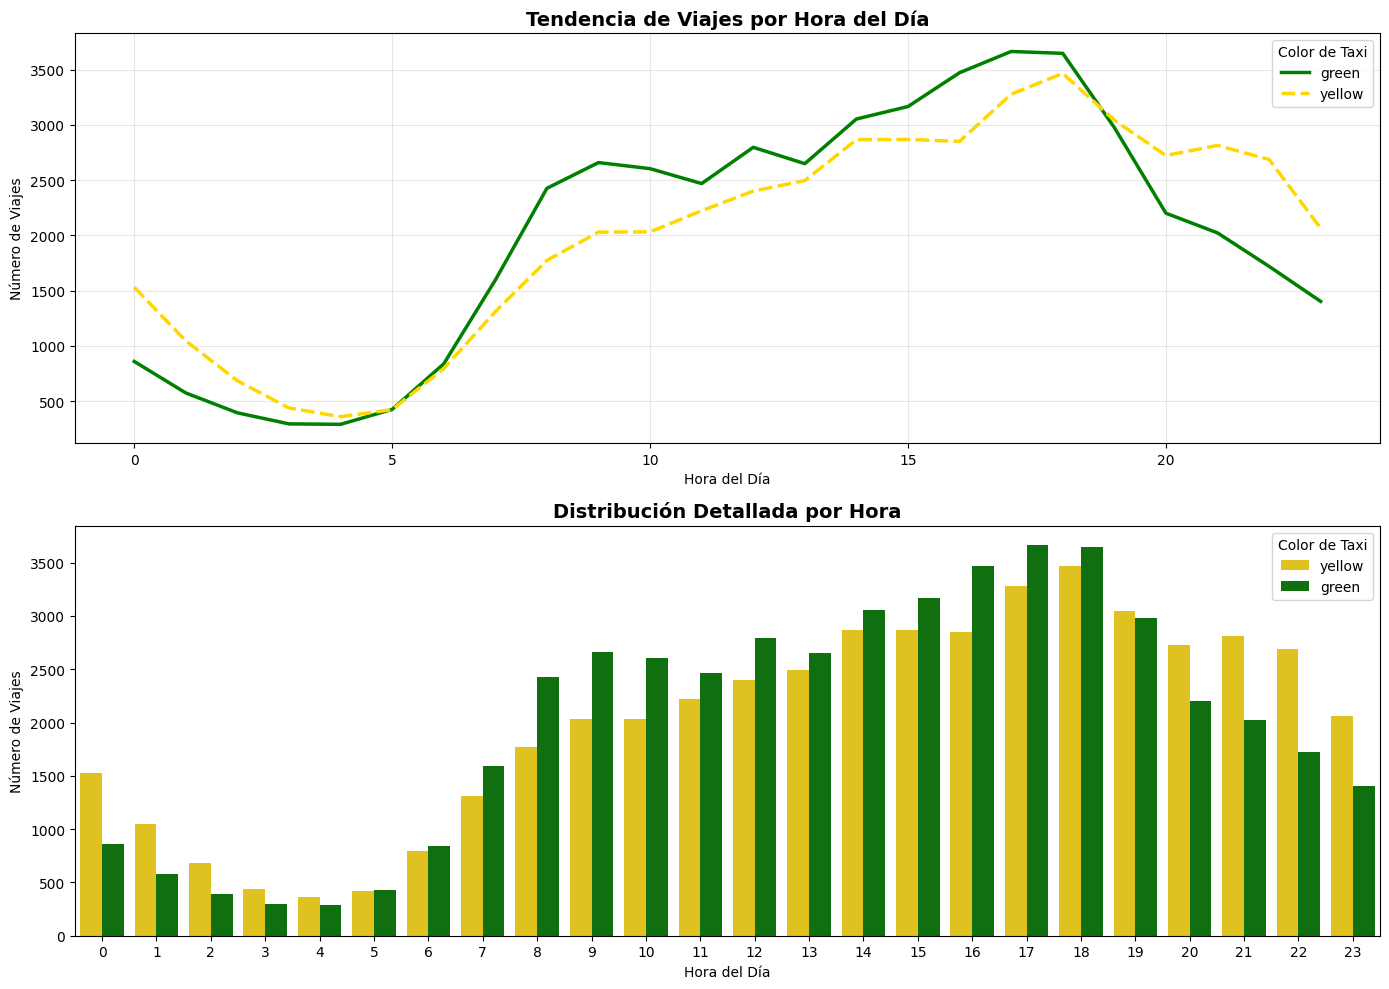

In [44]:
# Tendencia de viajes por hora del día
print("\n# Tendencia de viajes por hora del día")
# Crear figura con dos subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Gráfico de líneas para tendencia
hourly_counts = df_taxis.groupby(['pickup_hour', 'taxi_color']).size().unstack(fill_value=0)
sns.lineplot(data=hourly_counts, ax=ax1, palette=colors_pie, linewidth=2.5)
ax1.set_title('Tendencia de Viajes por Hora del Día', fontweight='bold', fontsize=14)
ax1.set_xlabel('Hora del Día')
ax1.set_ylabel('Número de Viajes')
ax1.legend(title='Color de Taxi')
ax1.grid(True, alpha=0.3)

# Gráfico de barras para distribución detallada
sns.countplot(data=df_taxis, x='pickup_hour', hue='taxi_color', palette=colors_pie, ax=ax2)
ax2.set_title('Distribución Detallada por Hora', fontweight='bold', fontsize=14)
ax2.set_xlabel('Hora del Día')
ax2.set_ylabel('Número de Viajes')
ax2.legend(title='Color de Taxi')

plt.tight_layout()
plt.show()

# Top 10 zonas con mayor volumen de viajes

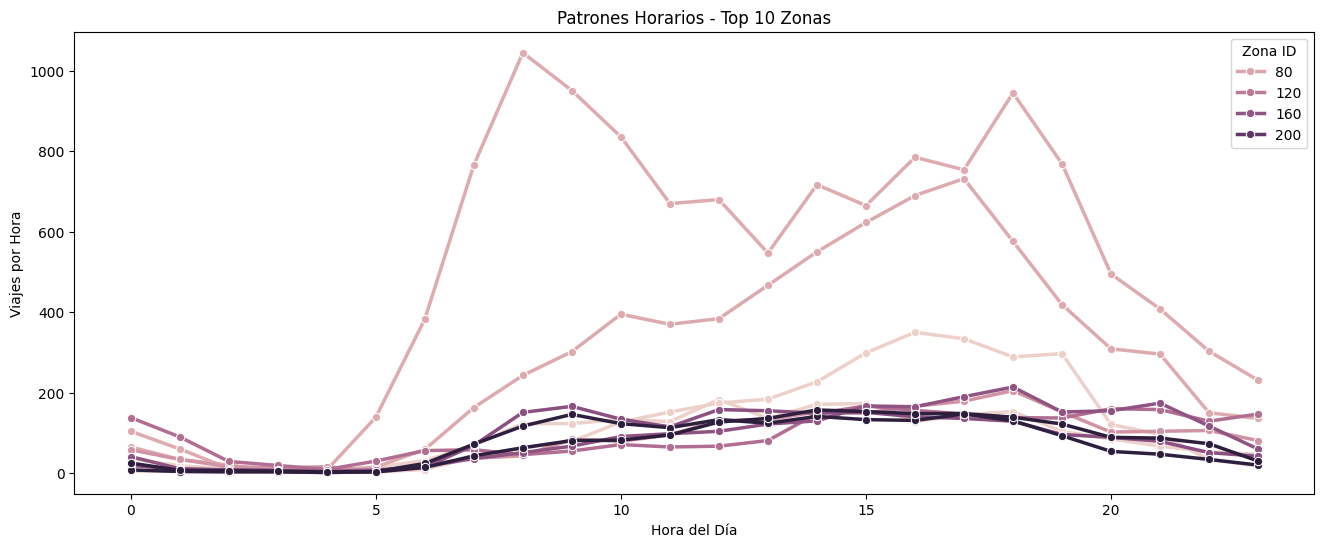

In [45]:
# Top 10 zonas con mayor volumen de viajes
plt.figure(figsize=(16,6))
# Definir top_zones 
top_zones = df_taxis['PULocationID'].value_counts().head(10)
# Análisis de saturación por hora en zonas top
top_10_zones = top_zones.head(10).index
top_zones_data = df_taxis[df_taxis['PULocationID'].isin(top_10_zones)]
hourly_top_zones = top_zones_data.groupby(['PULocationID', 'pickup_hour']).size().reset_index(name='count')

sns.lineplot(data=hourly_top_zones, x='pickup_hour', y='count', hue='PULocationID', marker='o', linewidth=2.5)
plt.title('Patrones Horarios - Top 10 Zonas')
plt.xlabel('Hora del Día')
plt.ylabel('Viajes por Hora')
plt.legend(title='Zona ID')

# Proporción por tipo de servicio (RatecodeID)

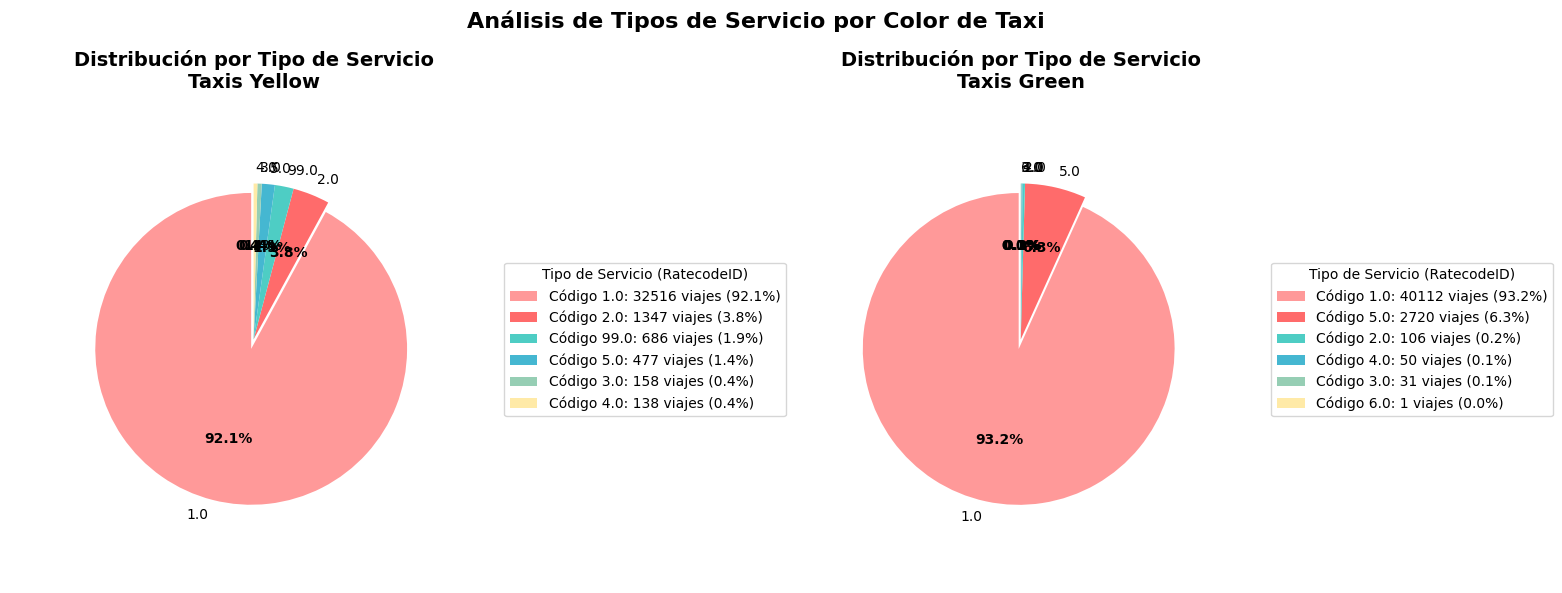

In [46]:
# Proporción por tipo de servicio (RatecodeID)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Definir colores personalizados para RatecodeID
ratecode_colors = ["#FF9999", '#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

# Taxis amarillos
yellow_data = df_taxis[df_taxis['taxi_color'] == 'yellow']['RatecodeID'].value_counts()
wedges1, texts1, autotexts1 = ax1.pie(
    yellow_data.values, 
    labels=yellow_data.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    radius=0.8,
    colors=ratecode_colors[:len(yellow_data)],
    explode=[0.05 if i == 0 else 0 for i in range(len(yellow_data))]  # Resaltar el más grande
)
ax1.set_title('Distribución por Tipo de Servicio\nTaxis Yellow', fontweight='bold', fontsize=14) 

# Leyenda mejorada para taxis amarillos
legend_labels_yellow = [f'Código {idx}: {val} viajes ({val/yellow_data.sum()*100:.1f}%)' 
                       for idx, val in yellow_data.items()]
ax1.legend(wedges1, legend_labels_yellow, title="Tipo de Servicio (RatecodeID)", 
          loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=10)

# Taxis verdes
green_data = df_taxis[df_taxis['taxi_color'] == 'green']['RatecodeID'].value_counts()
wedges2, texts2, autotexts2 = ax2.pie(
    green_data.values, 
    labels=green_data.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    radius=0.8,
    colors=ratecode_colors[:len(green_data)],
    explode=[0.05 if i == 0 else 0 for i in range(len(green_data))]  # Resaltar el más grande
)
ax2.set_title('Distribución por Tipo de Servicio\nTaxis Green', fontweight='bold', fontsize=14)
# Leyenda mejorada para taxis verdes
legend_labels_green = [f'Código {idx}: {val} viajes ({val/green_data.sum()*100:.1f}%)' 
                      for idx, val in green_data.items()]
ax2.legend(wedges2, legend_labels_green, title="Tipo de Servicio (RatecodeID)", 
          loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=10)

# Mejorar el estilo de texto
for autotext in autotexts1 + autotexts2:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

plt.suptitle('Análisis de Tipos de Servicio por Color de Taxi', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Análisis de Métodos de Pago por Color de Taxi

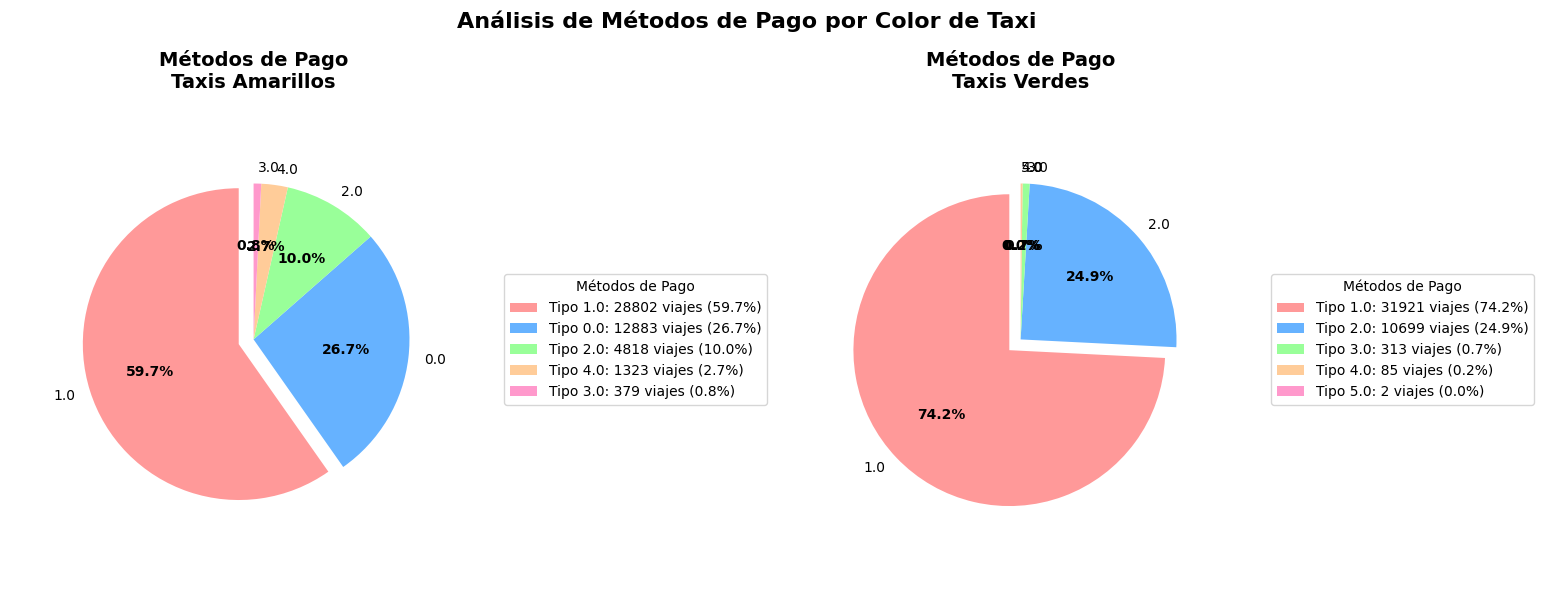


Estadística de métodos de pago

Taxis Amarillos - Total viajes: 48,205
Distribución por método de pago:
  Payment Type 1.0: 28,802 viajes (59.7%)
  Payment Type 0.0: 12,883 viajes (26.7%)
  Payment Type 2.0: 4,818 viajes (10.0%)
  Payment Type 4.0: 1,323 viajes (2.7%)
  Payment Type 3.0: 379 viajes (0.8%)

Taxis Verdes - Total viajes: 43,020
Distribución por método de pago:
  Payment Type 1.0: 31,921 viajes (74.2%)
  Payment Type 2.0: 10,699 viajes (24.9%)
  Payment Type 3.0: 313 viajes (0.7%)
  Payment Type 4.0: 85 viajes (0.2%)
  Payment Type 5.0: 2 viajes (0.0%)


In [47]:
# Proporción por método de pago
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Definir colores personalizados para payment_type
payment_colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC', '#99CCFF', '#FFB366']

# Taxis amarillos - Métodos de pago
yellow_payment = df_taxis[df_taxis['taxi_color'] == 'yellow']['payment_type'].value_counts()
wedges3, texts3, autotexts3 = ax1.pie(
    yellow_payment.values, 
    labels=yellow_payment.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    radius=0.8,
    colors=payment_colors[:len(yellow_payment)],
    explode=[0.08 if i == 0 else 0 for i in range(len(yellow_payment))]  # Resaltar el más grande
)
ax1.set_title('Métodos de Pago\nTaxis Amarillos', fontweight='bold', fontsize=14)

# Leyenda detallada para métodos de pago - amarillos
payment_labels_yellow = [f'Tipo {idx}: {val} viajes ({val/yellow_payment.sum()*100:.1f}%)' 
                        for idx, val in yellow_payment.items()]
ax1.legend(wedges3, payment_labels_yellow, title="Métodos de Pago", 
          loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=10)

# Taxis verdes - Métodos de pago
green_payment = df_taxis[df_taxis['taxi_color'] == 'green']['payment_type'].value_counts()
wedges4, texts4, autotexts4 = ax2.pie(
    green_payment.values, 
    labels=green_payment.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    radius=0.8,
    colors=payment_colors[:len(green_payment)],
    explode=[0.08 if i == 0 else 0 for i in range(len(green_payment))]  # Resaltar el más grande
)
ax2.set_title('Métodos de Pago\nTaxis Verdes', fontweight='bold', fontsize=14)

# Leyenda detallada para métodos de pago - verdes
payment_labels_green = [f'Tipo {idx}: {val} viajes ({val/green_payment.sum()*100:.1f}%)' 
                       for idx, val in green_payment.items()]
ax2.legend(wedges4, payment_labels_green, title="Métodos de Pago", 
          loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=10)

# Mejorar el estilo de texto
for autotext in autotexts3 + autotexts4:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

plt.suptitle('Análisis de Métodos de Pago por Color de Taxi', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Mostrar estadísticas de métodos de pago
print("\nEstadística de métodos de pago\n")
print(f"Taxis Amarillos - Total viajes: {yellow_payment.sum():,}")
print("Distribución por método de pago:")
for payment, count in yellow_payment.items():
    print(f"  Payment Type {payment}: {count:,} viajes ({count/yellow_payment.sum()*100:.1f}%)")

print(f"\nTaxis Verdes - Total viajes: {green_payment.sum():,}")
print("Distribución por método de pago:")
for payment, count in green_payment.items():
    print(f"  Payment Type {payment}: {count:,} viajes ({count/green_payment.sum()*100:.1f}%)")



# Comparación RatecodeID and Payment: Taxis Yellow vs Green

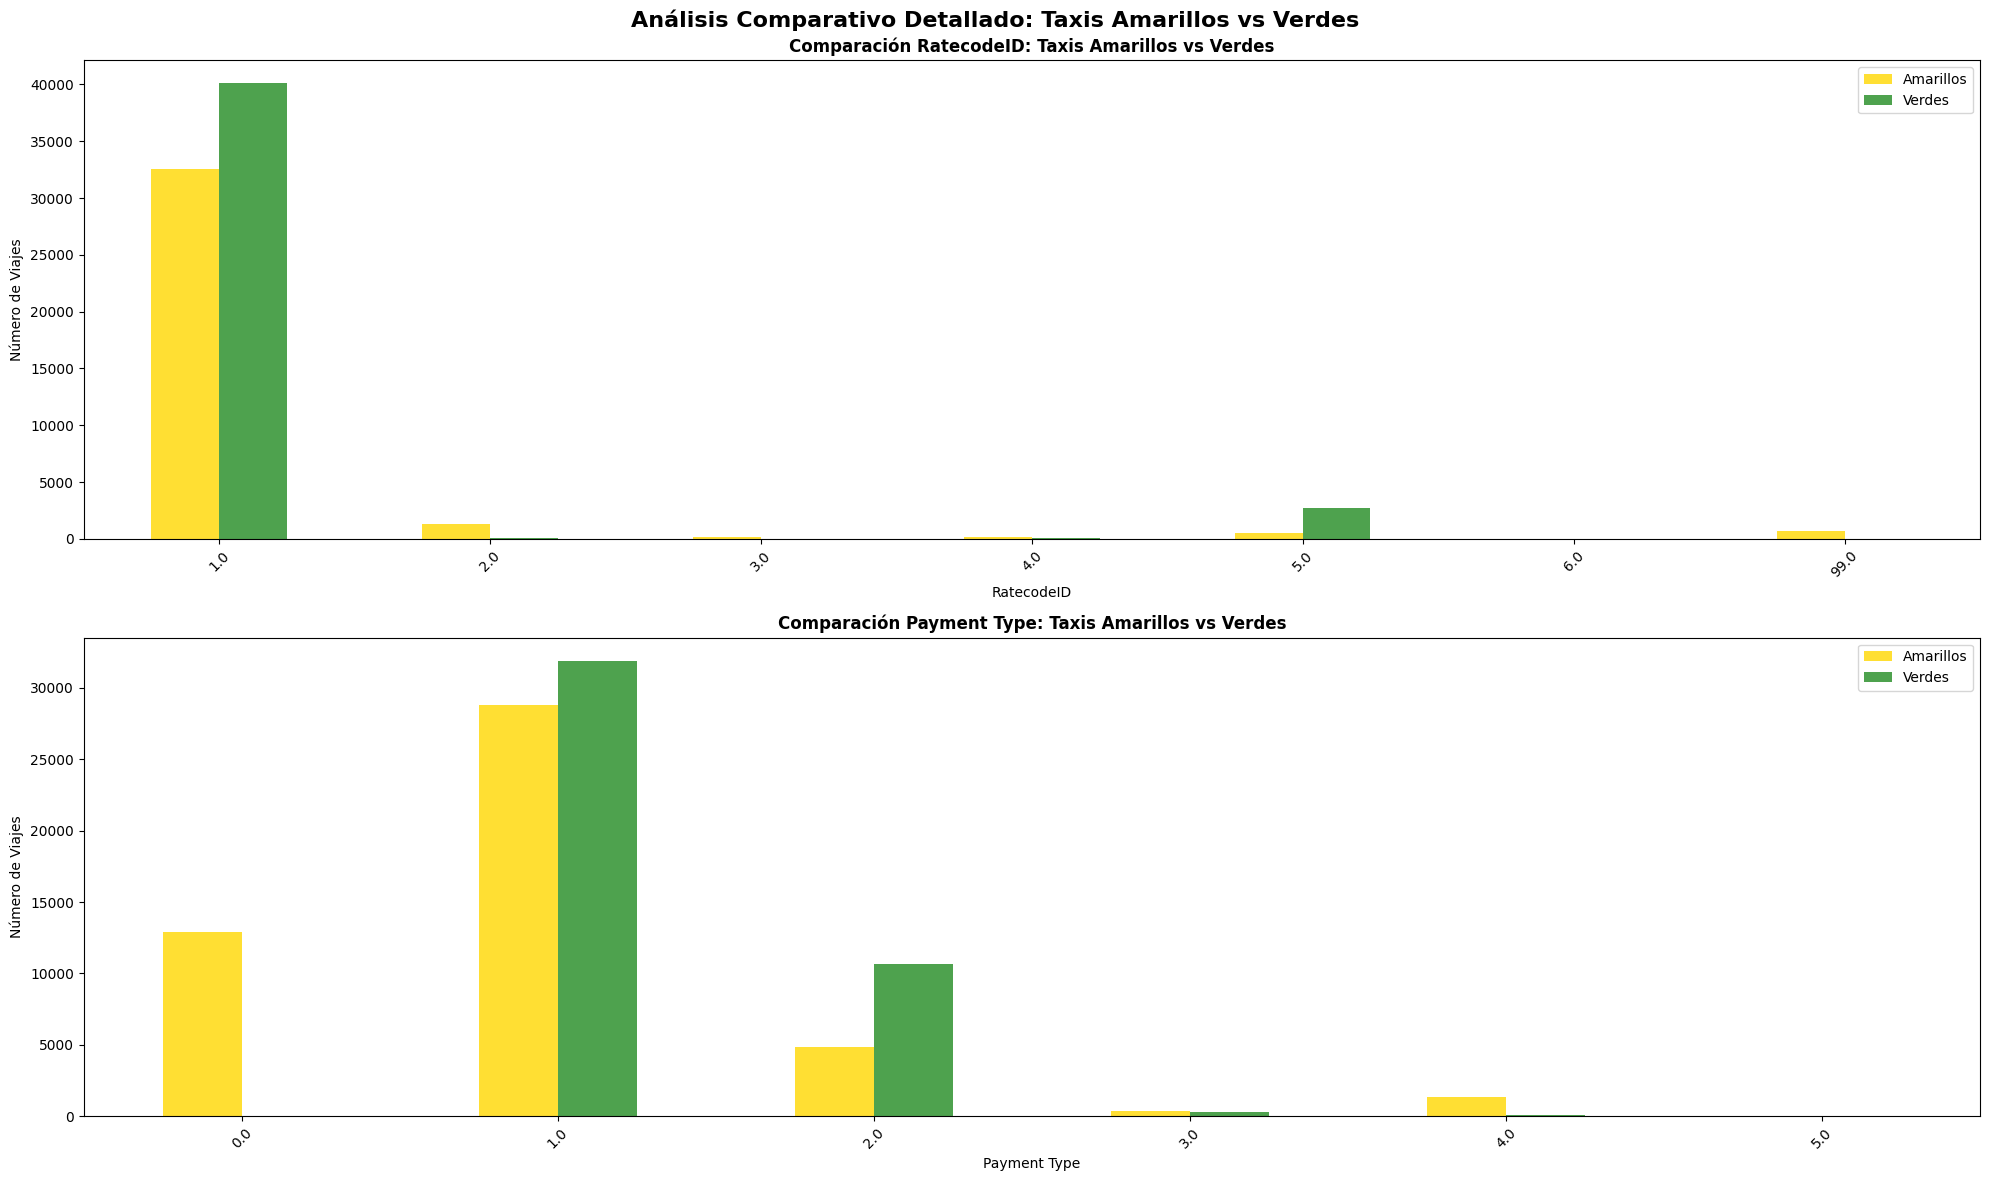

In [48]:
# Comparación directa entre taxis amarillos y verdes
fig, ((ax1, ax2)) = plt.subplots(2  , 1, figsize=(20, 12))

# Gráfico de barras comparativo - RatecodeID
ratecode_comparison = pd.DataFrame({
    'Yellow': yellow_data,
    'Green': green_data
}).fillna(0)

ratecode_comparison.plot(kind='bar', ax=ax1, color=['gold', 'forestgreen'], alpha=0.8)
ax1.set_title('Comparación RatecodeID: Taxis Amarillos vs Verdes', fontweight='bold', fontsize=12)
ax1.set_xlabel('RatecodeID')
ax1.set_ylabel('Número de Viajes')
ax1.legend(['Amarillos', 'Verdes'])
ax1.tick_params(axis='x', rotation=45)

# Gráfico de barras comparativo - Payment Type
payment_comparison = pd.DataFrame({
    'Yellow': yellow_payment,
    'Green': green_payment
}).fillna(0)

payment_comparison.plot(kind='bar', ax=ax2, color=['gold', 'forestgreen'], alpha=0.8)
ax2.set_title('Comparación Payment Type: Taxis Amarillos vs Verdes', fontweight='bold', fontsize=12)
ax2.set_xlabel('Payment Type')
ax2.set_ylabel('Número de Viajes')
ax2.legend(['Amarillos', 'Verdes'])
ax2.tick_params(axis='x', rotation=45)


plt.suptitle('Análisis Comparativo Detallado: Taxis Amarillos vs Verdes', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Ingresos promedio por hora y tipo de taxi

Text(0, 0.5, 'Ingreso Promedio ($)')

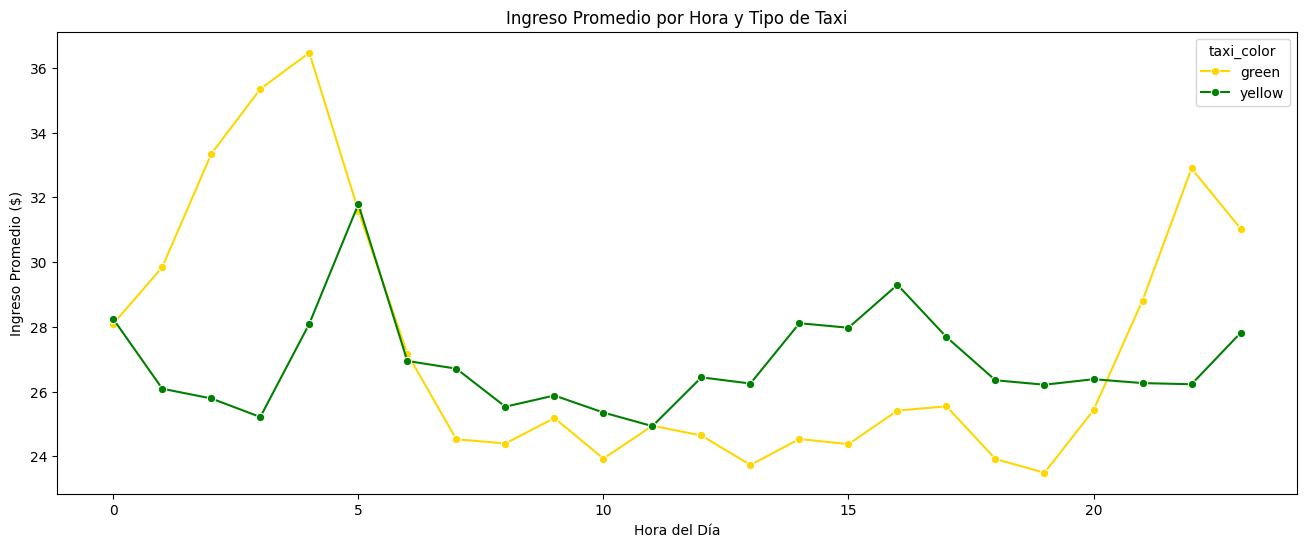

In [49]:
# Ingresos promedio por hora y tipo de taxi
plt.figure(figsize=(16, 6))
# Ingresos promedio por hora
hourly_revenue = df_taxis.groupby(['pickup_hour', 'taxi_color'])['total_amount'].mean().reset_index()
sns.lineplot(data=hourly_revenue, x='pickup_hour', y='total_amount', 
             hue='taxi_color', marker='o', palette=['gold', 'green'])
plt.title('Ingreso Promedio por Hora y Tipo de Taxi')
plt.xlabel('Hora del Día')
plt.ylabel('Ingreso Promedio ($)')

# Comparación días laborables vs fines de semana

Text(0, 0.5, 'Hora de Recogida')

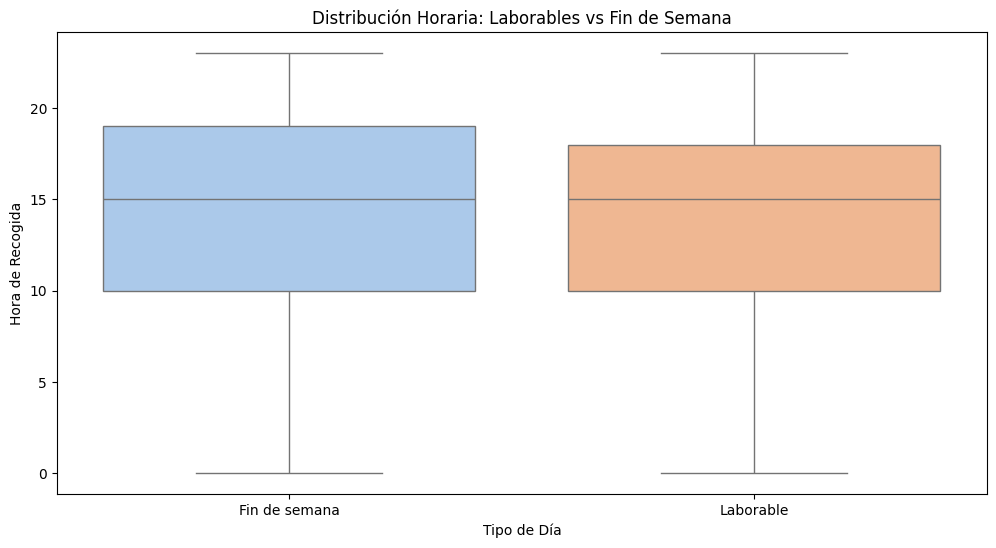

In [50]:
# Crear figura con subplots
plt.figure(figsize=(12, 6))

# Comparación días laborables vs fines de semana
df_taxis['day_type'] = df_taxis['is_weekend'].map({0: 'Laborable', 1: 'Fin de semana'})
sns.boxplot(data=df_taxis, x='day_type', y='pickup_hour', palette='pastel')
plt.title('Distribución Horaria: Laborables vs Fin de Semana')
plt.xlabel('Tipo de Día')
plt.ylabel('Hora de Recogida')

# Heatmap de densidad por hora y día de la semana 

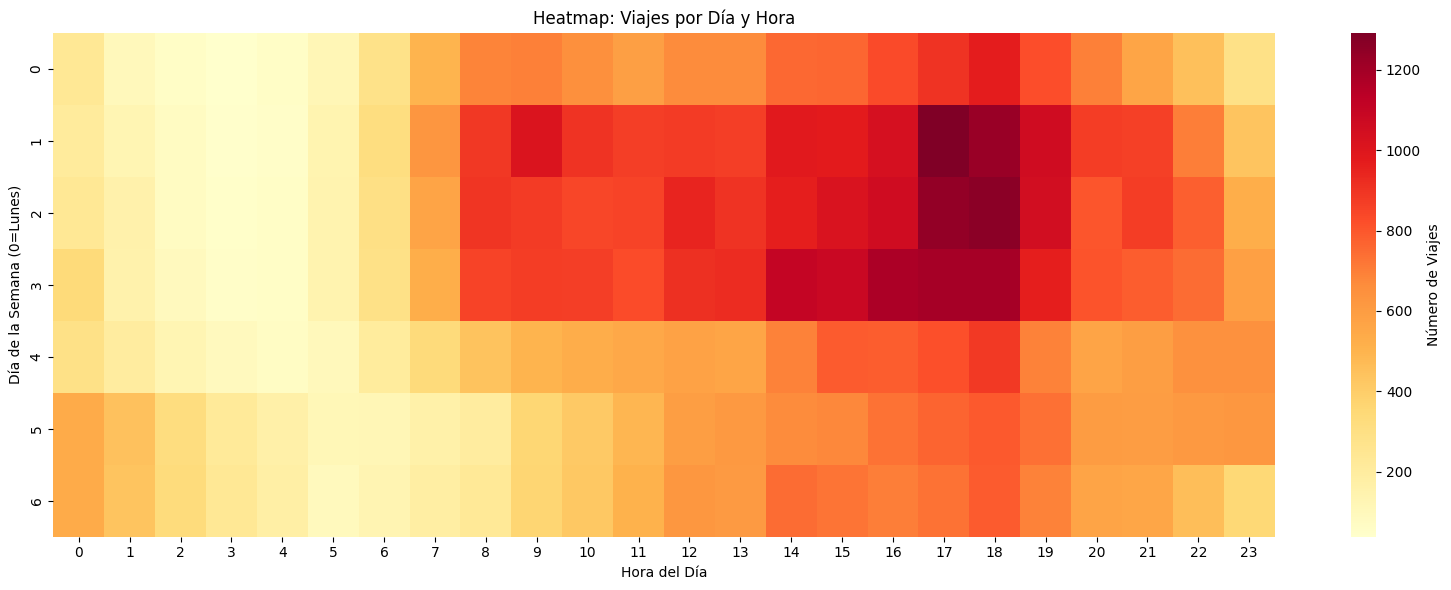

In [51]:
# Crear figura con subplots
plt.figure(figsize=(16, 6))
# Heatmap de densidad por hora y día de la semana
pivot_hour_day = df_taxis.pivot_table(
    index='pickup_day_of_week', 
    columns='pickup_hour', 
    values='PULocationID', 
    aggfunc='count',
    fill_value=0
)
sns.heatmap(pivot_hour_day, cmap='YlOrRd', cbar_kws={'label': 'Número de Viajes'})
plt.title('Heatmap: Viajes por Día y Hora')
plt.xlabel('Hora del Día')
plt.ylabel('Día de la Semana (0=Lunes)')

plt.tight_layout()
plt.show()

# Densidad de duración de viajes

(0.0, 60.0)

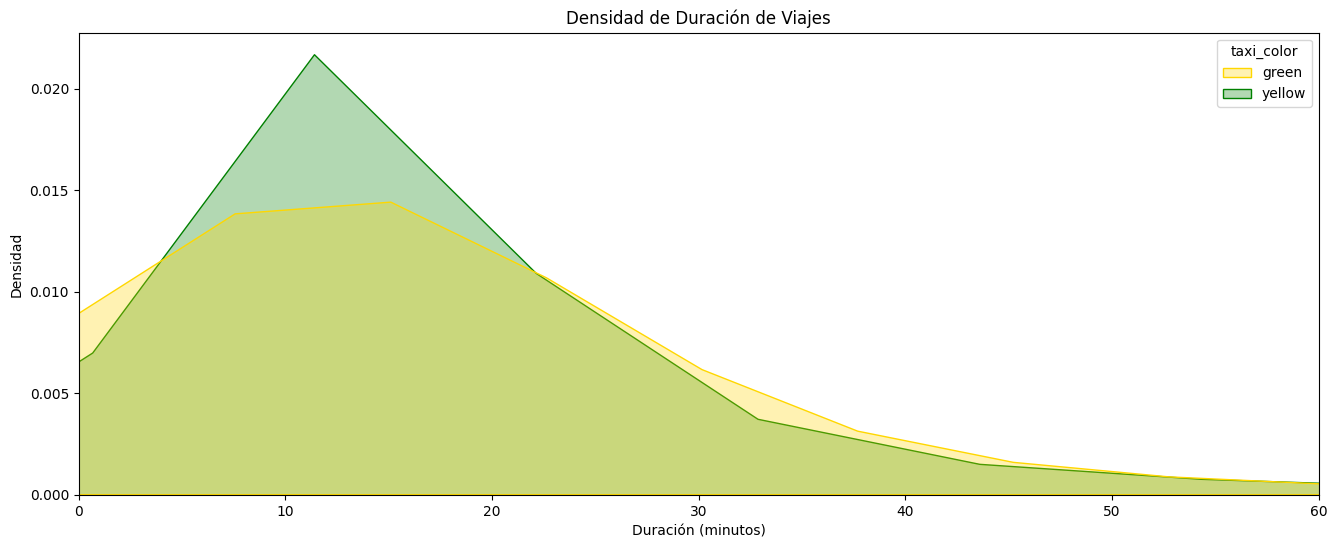

In [52]:
# Análisis de duración de viajes
plt.figure(figsize=(16, 6))
# Densidad de duración de viajes
sns.kdeplot(data=df_taxis, x='trip_duration_min', hue='taxi_color', 
            palette=['gold', 'green'], fill=True, alpha=0.3)
plt.title('Densidad de Duración de Viajes')
plt.xlabel('Duración (minutos)')
plt.ylabel('Densidad')
plt.xlim(0, 60)  # Excluir outliers extremos

# Heatmap de patrones temporales por zona

Text(170.72222222222223, 0.5, 'Zona ID')

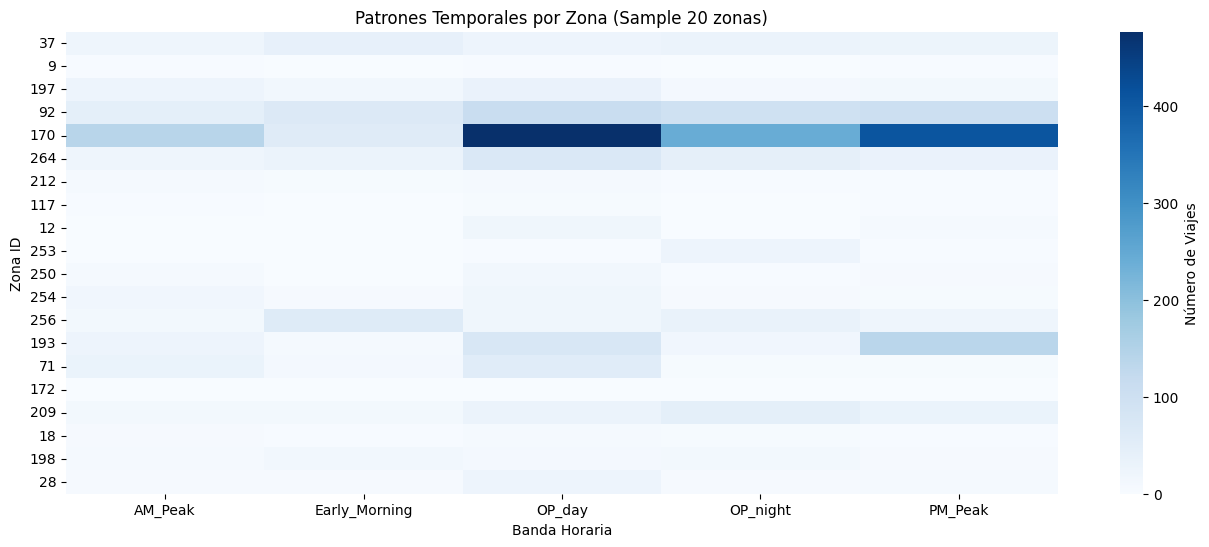

In [53]:
# Análisis multivariado para clustering
plt.figure(figsize=(16, 6))

# Preparar datos para análisis de segmentación
segment_data = df_taxis.groupby(['PULocationID', 'time_band']).agg({
    'pickup_datetime': 'count',
    'trip_duration_min': 'mean',
    'total_amount': 'mean',
    'passenger_count': 'mean'
}).reset_index()

segment_data_pivot = segment_data.pivot_table(
    index='PULocationID',
    columns='time_band',
    values='pickup_datetime',
    fill_value=0
)

# Heatmap de patrones temporales por zona (sample de zonas)
sample_zones = segment_data_pivot.sample(20, random_state=42)
sns.heatmap(sample_zones, cmap='Blues', cbar_kws={'label': 'Número de Viajes'})
plt.title('Patrones Temporales por Zona (Sample 20 zonas)')
plt.xlabel('Banda Horaria')
plt.ylabel('Zona ID')

In [54]:
# Ruta para guardar el archivo Parquet
dataunderstanding = './data/DataUnderstanding_fhvhv_sample.parquet'

# Guarda el DataFrame taxis_sample en formato Parquet
try:        
    fhvhv_sample.to_parquet(dataunderstanding, index=False) 
    print(f"DataFrame guardado exitosamente como '{dataunderstanding}'")
except Exception as e:
    print(f"Error al guardar como Parquet: {e}")

DataFrame guardado exitosamente como './data/DataUnderstanding_fhvhv_sample.parquet'


In [55]:
# Ruta para guardar el archivo Parquet
dataunderstanding = './data/DataUnderstanding_taxis_sample.parquet'

# Guarda el DataFrame taxis_sample en formato Parquet
try:        
    taxis_sample_ordered.to_parquet(dataunderstanding, index=False) 
    print(f"DataFrame guardado exitosamente como '{dataunderstanding}'")
except Exception as e:
    print(f"Error al guardar como Parquet: {e}")

DataFrame guardado exitosamente como './data/DataUnderstanding_taxis_sample.parquet'
